# 6. Black-Litterman with Learned Confidence

In this project we will 

- clean the ETF data and understand the market instruments. 
- build a strategic benchmark and the covariance estimates needed for portfolio risk.
- introduce the Black-Litterman prior and define views.
- build the view matrix, learn confidence from realized historical payoffs, and finally convert the posterior expected returns into portfolio weights.
- repeat the same idea on sector ETFs through the library implementation.

## 1) mathematic background: Bayes Rule

Black-Litterman is easier to understand if we start with this topic. Imagine we have an initial belief about something uncertain. Then we observe new evidence. We should not throw away the initial belief completely, and we should not ignore the evidence either. We should update the belief.

That is the whole Bayesian idea. The **prior** is what we believed before the new information. The **likelihood** is how compatible the new information is with possible states of the world. The **posterior** is what we believe after combining both.

$$
P(A\mid B)=\frac{P(B\mid A)P(A)}{P(B)}
$$

where $P(A)$ is the **prior** (what we believed before seeing $B$), $P(B \mid A)$ is the **likelihood** (how compatible the evidence $B$ is with belief $A$), and $P(A \mid B)$ is the **posterior** (our updated belief after seeing $B$). Written proportionally:

$$
\underbrace{P(A \mid B)}_{\text{posterior}} \;\propto\; \underbrace{P(B \mid A)}_{\text{likelihood}} \times \underbrace{P(A)}_{\text{prior}}
$$

Or we can write it like this:
$$
\mathrm{posterior\ belief}\propto\mathrm{prior\ belief}\times\mathrm{new\ evidence}
$$

Here, the uncertain object is not a class label or a coin probability. It is the vector of **expected returns**. Expected returns are hard to estimate, so we don't want to trust historical averages too much. We can first define a **benchmark** that gives us a starting point or the prior. Then we use some **views** about the financial markets and economic situations that will have effect on expected returns. views give us new information. Then there is **confidence** for each view which decides how much the views should move us away from the benchmark.

So the process is:
- start with a reasonable neutral belief 
- observe the new evidence 
- update the belief considering the confidence.

Since this notebook is a portfolio optimization related topic, i highly recommend reading notebook [2. Portfolio optimization with Mean-Variance models] first for better understanding of project.


[2. Portfolio optimization with Mean-Variance models]: https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/02_portfolio_optimization_MV_models.html

### Imports and pltting style

In [5]:
from pathlib import Path
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

from cycler import cycler
from IPython.display import display

from quantfinlab.portfolio import (
    prices_to_returns, make_rebalance_dates,
    estimate_covariance, make_psd, selection)

from quantfinlab.portfolio.walkforward import run_walkforward_grid
from quantfinlab.risk import corr_matrix, rolling_volatility
from quantfinlab.reports.risk_report import risk_report

from quantfinlab.plotting import (
    plot_corr_heatmap, plot_strategy_nav,
    plot_strategy_drawdowns)

from quantfinlab.backtest.portfolio import run_many_weights_backtests

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
          "#DC143C", "#9614fa", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
if cycler is not None:
    plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({
    "figure.figsize": (7, 3.5),
    "figure.dpi": 140,
    "savefig.dpi": 250,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8})


## 2) Data

For this project, we could've used the same nasdaq data from notebook 2, but that wouldn't be the best choice for Black-Litterman and the economic interpretation and building views wouldn't be as good. So we use a dataset of famous ETFs (investement funds that are tradable like exchanges) which is collected from yahoo-finance API. A script for reproducing the dataset is available in data folder ([from here]). The dataset contains history of these ETFs from the start of 2010, but we use the data from the start of 2013 cause we don't want to deal with missing prices of one of the ETFs.
[from here]: https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/core_cross_asset_etfs

In [6]:
data_path = Path("../data/core_cross_asset_etfs.csv")
raw = pd.read_csv(data_path)
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw = raw.dropna(subset=["date"]).sort_values("date")
raw = raw.drop_duplicates(subset=["date"], keep="last")
raw = raw.set_index("date")

close_cols = [col for col in raw.columns if str(col).endswith("__close")]
volume_cols = [col for col in raw.columns if str(col).endswith("__volume")]
dividend_cols = [col for col in raw.columns if str(col).endswith("__dividends")]
split_cols = [col for col in raw.columns if str(col).endswith("__stock_splits")]

close_all = raw[close_cols].copy()
close_all.columns = [col.rsplit("__", 1)[0] for col in close_cols]
close_all = close_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
close_all = close_all.dropna(axis=1, how="all").reindex(columns=sorted(close_all.columns))

volume_all = raw[volume_cols].copy()
volume_all.columns = [col.rsplit("__", 1)[0] for col in volume_cols]
volume_all = volume_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
volume_all = volume_all.dropna(axis=1, how="all").reindex(columns=sorted(volume_all.columns))

dividends_all = raw[dividend_cols].copy()
dividends_all.columns = [col.rsplit("__", 1)[0] for col in dividend_cols]
dividends_all = dividends_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
dividends_all = dividends_all.reindex(columns=sorted(dividends_all.columns))

splits_all = raw[split_cols].copy()
splits_all.columns = [col.rsplit("__", 1)[0] for col in split_cols]
splits_all = splits_all.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
splits_all = splits_all.reindex(columns=sorted(splits_all.columns))

action_parts = []
if not dividends_all.empty:
    dividends_part = dividends_all.copy()
    dividends_part.columns = pd.MultiIndex.from_product([dividends_part.columns, ["dividends"]])
    action_parts.append(dividends_part)
if not splits_all.empty:
    splits_part = splits_all.copy()
    splits_part.columns = pd.MultiIndex.from_product([splits_part.columns, ["stock_splits"]])
    action_parts.append(splits_part)
actions_all = pd.concat(action_parts, axis=1).sort_index(axis=1) if action_parts else pd.DataFrame(index=raw.index)



The loaded data has $4107$ trading days and $63$ adjusted close columns before we select the project's ETFs. We are not going to use all $63$ ETFs and most of them are for later projects and secondary data for this project like sector ETFs.

### 2.1 Choosing the ETFs

We now choose the ETFs we are going to analyze for this notebook. The tradable assets are:

| Ticker | Role | What it represents |
|---|---|---|
| SPY | U.S. equity core | Large-cap US equities, commonly used as the broad US stock-market proxy. |
| QQQ | U.S. growth leadership | Nasdaq-100, usually more growth and technology heavy than SPY. |
| IWM | U.S. small caps | Russell 2000 small-cap US equities, more cyclical and domestically sensitive. |
| EFA | Developed international equity | Developed international equities outside North America. |
| EEM | Emerging markets equity | Higher-risk Emerging-market equities, usually more sensitive to global growth, dollar strength, and commodity cycles. |
| TLT | Long duration Treasuries | Long-duration US Treasuries (20+ years), very sensitive to changes in long-term interest rates. |
| IEF | Intermediate Treasuries | Intermediate Treasury (7-10 year), less duration risk than TLT. |
| SHY | Short Treasuries | Short-duration Treasury (1-3 year) and a defensive cash-like sleeve. Usually low volatility and low return. |
| AGG | Core bonds | Broad US aggregate bond, a core bond allocation. |
| LQD | Investment-grade credit | corporate bonds, combining rate exposure and credit exposure. |
| HYG | High-yield credit | High-yield corporate bonds, more equity like and more sensitive to credit conditions. |
| GLD | Gold | Holds physical gold, often treated as a real asset or crisis/inflation hedge. |
| VNQ | Real estate | US real estate investment trusts, rate-sensitive and equity-sensitive. |
| DBC | Commodities | Broad commodities futures, often connected to inflation and global real activity. |
| UUP | Dollar signal only | US dollar, used as an information variable rather than a tradable portfolio asset here. |


### 2.2 behaviour of these ETFs

**SPY, QQQ, and IWM** are all **equity** ETFs, but they do not behave the same. SPY is the broad large cap core. QQQ is more growth and technology heavy, so it usually benefits when investors reward long duration growth cash flows, innovations, and cap leadership. IWM is small cap exposure, so it tends to be more sensitive to growth and financing conditions

**EFA and EEM** give **international** exposure. EFA is developed market equity, while EEM is emerging market equity. Emerging markets are often more sensitive to dollar strength, global liquidity and commodity cycles. That is why UUP is useful as a signal asset. If the dollar is strengthening aggressively, emerging markets can face pressure even if they look attractive based on their local currency.

The **bond** ETFs: **SHY** is short Treasury exposure, **IEF** is intermediate Treasury exposure, and **TLT** is long Treasury exposure. As we can remembe from the notebook 1 and fixed income risk measures implementation, The longer the duration, the more sensitive the ETF is to interest rate changes. If rates rise sharply, long duration bonds can suffer large falls in their value. If rates fall during a growth scare, duration can help stabilize the portfolio.

**Credit** ETFs sit between bonds and equities. **LQD** is investment grade credit, while **HYG** is high yield credit. HYG is especially important because it can behave like a risky asset. In calm markets, high yield can earn carry. In stress markets, it can sell off with equities because credit spreads widen.

**GLD, VNQ, and DBC** have real asset and inflation sensitive exposures. **Gold** can behave as a diversifier when confidence in financial assets weakens and the situation is uncertain, although it is not a perfect hedge. **VNQ** is real estate and is sensitive to both growth and rates. **DBC** is broad commodities and can perform well during inflationary commodity cycles, but it can also be very painful in long disinflationary periods.

This financial interpretation matters because the later views are not arbitrary and we use these relations to build economically reasonable views.


In [7]:
start_date = "2013-01-01"

assets = [
    "SPY", "QQQ", "IWM", "EFA", "EEM", 
    "TLT", "IEF", "SHY",
    "AGG", "LQD", "HYG",
    "GLD", "VNQ", "DBC"]
signal_only_assets = ["UUP"] if "UUP" in close_all.columns else []

sleeve_map = {
    "SPY": "US equity", "QQQ": "US equity", "IWM": "US equity",
    "EFA": "International equity", "EEM": "International equity",
    "TLT": "Duration bonds", "IEF": "Duration bonds", "SHY": "Short bonds",
    "AGG": "Core bonds", "LQD": "Credit", "HYG": "Credit",
    "GLD": "Real assets", "VNQ": "Real assets", "DBC": "Commodities",
    "UUP": "Dollar"}


def missing_after_first_valid(series):
    first = series.first_valid_index()
    if first is None:
        return np.nan
    return float(series.loc[first:].isna().mean())


close_after_start = close_all.loc[pd.Timestamp(start_date):].copy()
missing_assets = [ticker for ticker in assets if ticker not in close_after_start.columns]
if missing_assets:
    raise ValueError(f"missing required tradable adjusted close columns: {missing_assets}")

filter_rows = []
for ticker in assets + signal_only_assets:
    px = close_after_start[ticker]
    valid = px.dropna()
    filter_rows.append({
        "ticker": ticker, "observations": len(valid),
        "first_date": valid.index.min() if len(valid) else pd.NaT,
        "last_date": valid.index.max() if len(valid) else pd.NaT,
        "missing_pct_after_first_valid": missing_after_first_valid(px),
        "tradable": ticker in assets,
    })
display(pd.DataFrame(filter_rows).round(4))

first_all_valid = close_after_start[assets].dropna(how="any").index.min()
if pd.isna(first_all_valid):
    raise ValueError("no date where all tradable ETF close columns are available")

close = close_after_start.loc[first_all_valid:, assets].ffill(limit=3).dropna(how="any")
returns = prices_to_returns(close, kind="simple").replace([np.inf, -np.inf], np.nan).dropna(how="all")
remaining_return_gaps = int(returns.isna().sum().sum())
if remaining_return_gaps:
    pass
returns = returns.fillna(0.0)
close = close.reindex(returns.index).ffill(limit=3)

signal_tickers = list(dict.fromkeys(assets + signal_only_assets))
signal_close = close_after_start.loc[first_all_valid:, signal_tickers].ffill(limit=3).reindex(returns.index).ffill(limit=3)
signal_returns = signal_close.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan).reindex(returns.index).fillna(0.0)



,ticker,observations,first_date,last_date,missing_pct_after_first_valid,tradable
0,SPY,3385,2013-01-02,2026-06-17,0.0,True
1,QQQ,3385,2013-01-02,2026-06-17,0.0,True
2,IWM,3385,2013-01-02,2026-06-17,0.0,True
3,EFA,3385,2013-01-02,2026-06-17,0.0,True
4,EEM,3385,2013-01-02,2026-06-17,0.0,True
5,TLT,3385,2013-01-02,2026-06-17,0.0,True
6,IEF,3385,2013-01-02,2026-06-17,0.0,True
7,SHY,3385,2013-01-02,2026-06-17,0.0,True
8,AGG,3385,2013-01-02,2026-06-17,0.0,True
9,LQD,3385,2013-01-02,2026-06-17,0.0,True


In [8]:
rebal_freq = "ME"
cov_lookback = 756
mu_lookback = 252

rebalance_dates = make_rebalance_dates(returns.index, freq=rebal_freq, min_history_days=max(cov_lookback, mu_lookback, 756))


We made monthly rebalance dates and we can see that even though our data starts from 2013, we need a lookback window for estimating covariance and mean, so the first rebalance date happens at the first month of 2016. 

In [9]:
annualization = 252

rows = []
for ticker in assets:
    px = close[ticker].dropna()
    ret = returns[ticker].dropna()
    years = max(len(ret) / annualization, 1e-9)
    nav = (1.0 + ret).cumprod()
    rows.append({
        "ticker": ticker,
        "sleeve": sleeve_map.get(ticker, "Other"),
        "first_date": px.index.min(),
        "last_date": px.index.max(),
        "observations": int(px.shape[0]),
        "ann_return": float(nav.iloc[-1] ** (1.0 / years) - 1.0) if len(nav) else np.nan,
        "ann_vol": float(ret.std() * math.sqrt(annualization)) if len(ret) else np.nan,
        "max_drawdown": float((nav / nav.cummax() - 1.0).min())})
    
table = pd.DataFrame(rows).sort_values("ticker")
display(table.round({"ann_return": 4, "ann_vol": 4, "max_drawdown": 4}))


,ticker,sleeve,first_date,last_date,observations,ann_return,ann_vol,max_drawdown
8,AGG,Core bonds,2013-01-03,2026-06-17,3384,0.0183,0.0496,-0.1843
13,DBC,Commodities,2013-01-03,2026-06-17,3384,0.0121,0.1706,-0.6220
4,EEM,International equity,2013-01-03,2026-06-17,3384,0.0543,0.2034,-0.3982
3,EFA,International equity,2013-01-03,2026-06-17,3384,0.0765,0.1673,-0.3419
11,GLD,Real assets,2013-01-03,2026-06-17,3384,0.0668,0.1643,-0.3860
10,HYG,Credit,2013-01-03,2026-06-17,3384,0.0423,0.0787,-0.2203
6,IEF,Duration bonds,2013-01-03,2026-06-17,3384,0.0122,0.0644,-0.2392
2,IWM,US equity,2013-01-03,2026-06-17,3384,0.1083,0.2154,-0.4113
9,LQD,Credit,2013-01-03,2026-06-17,3384,0.0273,0.0797,-0.2495
1,QQQ,US equity,2013-01-03,2026-06-17,3384,0.2033,0.2082,-0.3512


### 2.3 Performance of ETFs

As we can see, **QQQ** has been the strongest asset in the sample, with an annualized return close to 20% and volatility around 21%. **SPY** also performs strongly, with lower return and lower volatility than QQQ. **IWM** has a positive return but much higher drawdown, which is typical of small cap exposure especially in our sample where large cap growth leadership has been very strong.

The international equity ETFs are weaker. **EFA and EEM** both have large drawdowns and volatility, but their returns are much lower than U.S. equities. This already tells us that a simple global equity diversification story is not enough. International exposure may still be useful, but an efficient model should not blindly assume that all equities and markets deserve the same allocation.

The bond ETFs show very different behavior. **SHY** has very low volatility around $1.4\%$ and a much smaller drawdown around $-5.7\%$, but the return is also low. **TLT** is the opposite of what someone might expect from “bonds”. It has a very large drawdown around $-48.5\%$ in this sample because as we said earlier, long duration bonds are sensitive to interest rate changes. TLT fell hard by the post-2021 rate shock.

**DBC** has a very large drawdown around $-62.2\%$, which can be from the long weak cycles. **GLD and VNQ** are somewhere between diversifiers and risk assets. They have meaningful volatility and large drawdowns, but they also bring different economic exposure.

An efficient active model like Black-Litterman should know when to lean into growth, when to prefer real assets, when to reduce long duration, and when to stay close to the benchmark so it can control risk and gain the high return based on the state and information and the uncertainty of that information given to it each time it's rabalancing.

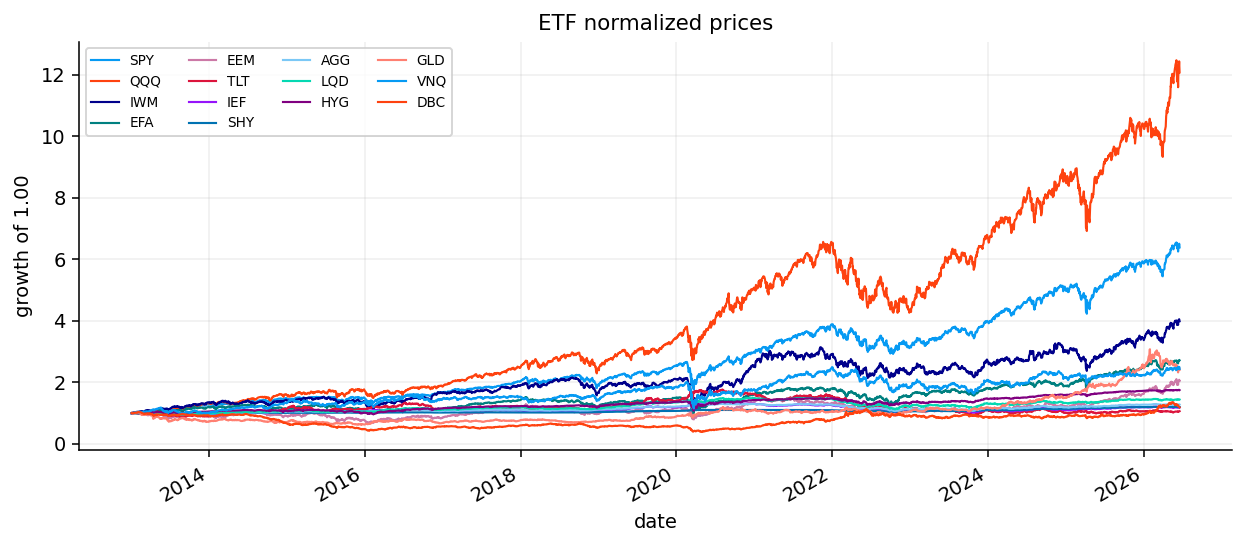

In [10]:
normalized_prices = close / close.ffill().bfill().iloc[0]
ax = normalized_prices.plot(figsize=(9, 4), lw=1.1)
ax.set_title("ETF normalized prices")
ax.set_ylabel("growth of 1.00")
ax.set_xlabel("date")
ax.legend(ncol=4, fontsize=7)
plt.tight_layout()
plt.show()


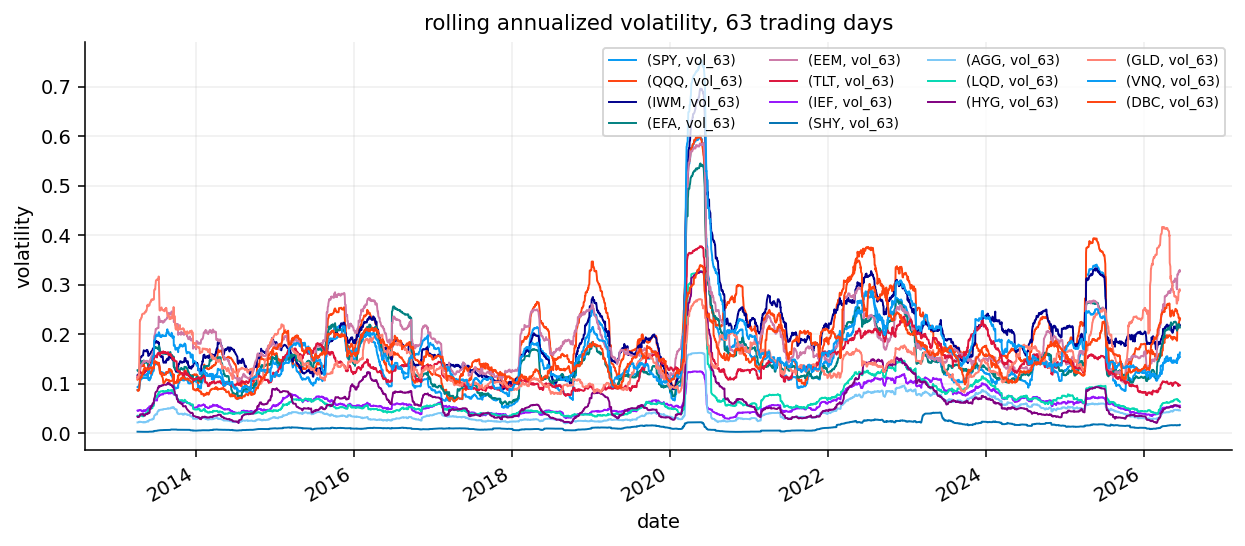

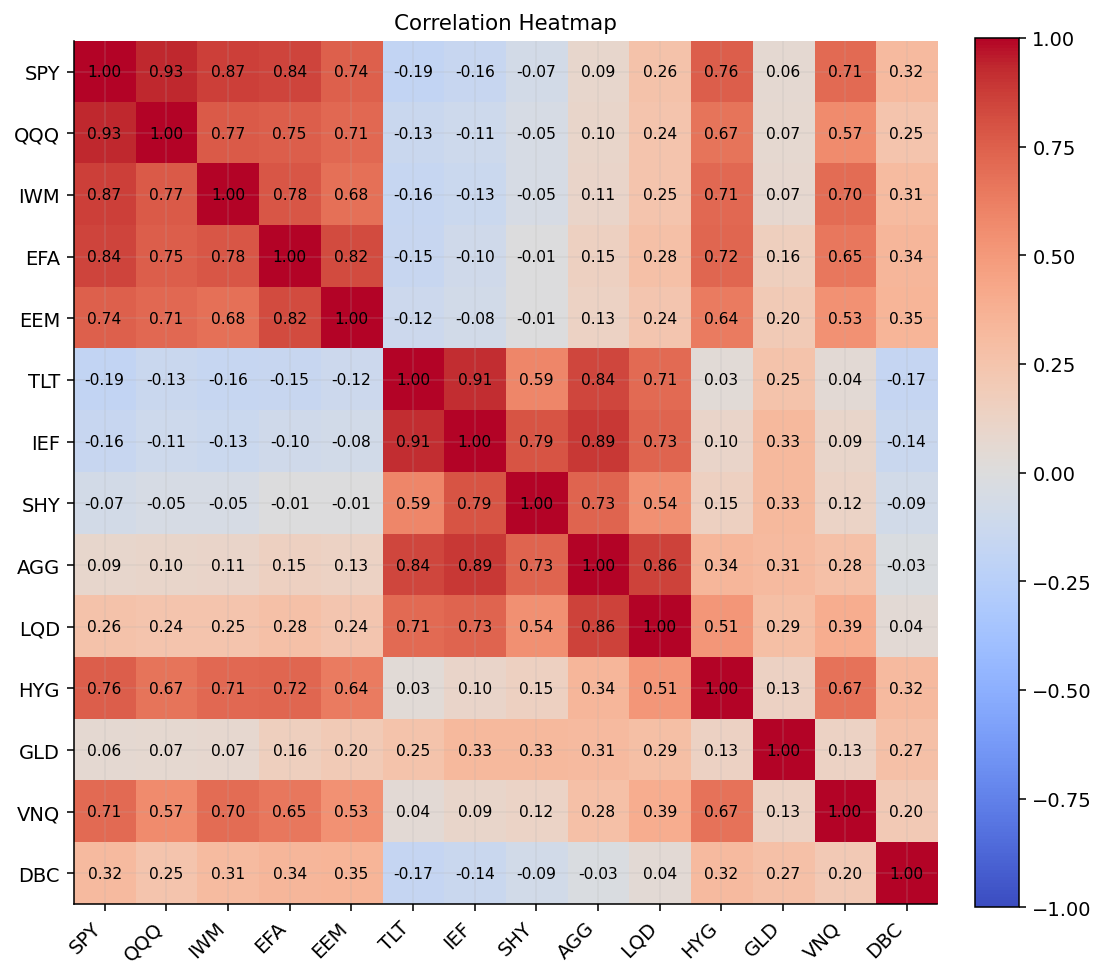

In [11]:
rolling_vol = rolling_volatility(returns, windows=(63,), annualization=annualization)
ax = rolling_vol.plot(figsize=(9, 4), lw=1.0)
ax.set_title("rolling annualized volatility, 63 trading days")
ax.set_ylabel("volatility")
ax.set_xlabel("date")
ax.legend(ncol=4, fontsize=7, loc="best")
plt.tight_layout()
plt.show()

corr = corr_matrix(returns)
fig, ax = plt.subplots(figsize=(8, 8))
ax = plot_corr_heatmap(ax, corr)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


As we can see, volatility jumps during crisis periods, especially around the COVID shock. Equity and real asset ETFs show much larger volatility spikes than short duration bonds. SHY remains the lowest volatility instrument throughout the sample.

U.S. equity ETFs are highly correlated with each other. SPY and QQQ move very closely, and IWM also has strong equity market correlation. Developed and emerging market equity ETFs also connect strongly to the US equity. This means that simply owning SPY, QQQ, IWM, EFA, and EEM is not as diversified as the number of tickers suggests.

The bond holding ETFs are different. TLT, IEF, SHY, AGG, and LQD have their own internal structure. TLT and IEF are strongly related because both are Treasury duration exposures. TLT has negative correlation with SPY around $-0.19$, which shows why long Treasuries historically helped in some equity selloffs. But the correlation is not fixed forever. In inflation shocks, stocks and bonds can fall together.

AGG and LQD are also connected to the broader bond and credit market. HYG behaves more like risky credit and often correlates more with equities than with pure Treasuries.

Gold and commodities contain a different kind of exposure. GLD has weaker relationships with most assets, which can make it a good diversifier. DBC has a different inflation and commodity cycle profile, so it can help when inflation sensitive assets are leading, but it can also be very difficult to hold during long weak commodity regimes.

If the optimizer only sees a covariance matrix and expected returns, it may concentrate in a few assets. The human portfolio manager might add economic sanity to the model instead of just relying on estimation. This is why Black-Litterman can be great for combining economic ideas and views into a portfolio optimization model.

## 3) Building the strategic benchmark and Prior

If we remember the bayes rule from earlier, we want to update our belief when new information arrives. We first need an intial belief or a starting point that is going to change with the new information.

### 3.1 Benchmark portfolio

We First define a neutral portfolio. This is not supposed to be the smartest portfolio in the notebook. In Black-Litterman, the benchmark exists because it represents the **starting belief about how capital should be allocated** before any active views are added.

The benchmark we use is a portfolio with pre-defined fixed weights and the weights are based on what we think can be reasonable for these ETFs based on their performance, behaviour and what they hold. It gives meaningful weight to US equities, international equities, bonds, credit, gold, real estate, and commodities. It is also constrained by asset caps and constraints. These caps protect the optimization from unrealistic concentration on just one asset.

For example, even if QQQ has a strong historical return, we probably do not want a mult asset benchmark to become almost entirely QQQ. We are looking for diversification. Also, even if short Treasuries have low volatility, a diversified benchmark should not become a pure cash substitute. In that case we will end up with a very low volatility portfolio but almost the worst return.

We don't want the optimizer to do whatever it wants. We want it to stay inside a realistic multi asset allocation structure. That's why we use bounds and caps for weights on each asset.

Since we already know from notebook 2, A benchmark weight vector looks like this:

$$
w_b=\begin{bmatrix}w_{b,\mathrm{SPY}} & w_{b,\mathrm{QQQ}} & \cdots & w_{b,\mathrm{DBC}}\end{bmatrix}^{\top}
$$

with the full investment condition

$$
\sum_{i=1}^{N}w_{b,i}=1
$$

And the benchmark is long-only, so all weights are nonnegative:

$$
w_{b,i}\geq 0
$$


In [12]:
w_min = 0.0
w_max = 0.40

fixed_benchmark_weights = {
    "SPY": 0.22, "QQQ": 0.08, "IWM": 0.04, "EFA": 0.09, "EEM": 0.05,
    "TLT": 0.08, "IEF": 0.08, "SHY": 0.05, "AGG": 0.10, "LQD": 0.05,
    "HYG": 0.04, "GLD": 0.05, "VNQ": 0.04, "DBC": 0.02}

asset_cap_map = {
    "SPY": 0.35, "QQQ": 0.25, "IWM": 0.15, "EFA": 0.20, "EEM": 0.15,
    "TLT": 0.25, "IEF": 0.25, "SHY": 0.20, "AGG": 0.25,
    "LQD": 0.15, "HYG": 0.08, "GLD": 0.10, "VNQ": 0.08, "DBC": 0.05}

asset_caps = pd.Series({asset: asset_cap_map.get(asset, w_max) for asset in assets}, index=assets, dtype=float)

sleeve_constraints = {
    "equity": {"assets": ["SPY", "QQQ", "IWM", "EFA", "EEM"], "min": 0.35, "max": 0.75},
    "bonds": {"assets": ["TLT", "IEF", "SHY", "AGG"], "min": 0.15, "max": 0.55},
    "credit": {"assets": ["LQD", "HYG"], "min": 0.00, "max": 0.18},
    "real_assets": {"assets": ["GLD", "VNQ", "DBC"], "min": 0.00, "max": 0.22}}


def normalize_box_weights(raw_weights, index, lower=0.0, upper=0.25):
    w = pd.Series(raw_weights, index=index, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    upper_s = pd.Series(upper, index=index, dtype=float) if np.isscalar(upper) else pd.Series(upper, index=index, dtype=float).reindex(index).fillna(w_max)
    w = w.clip(lower=max(lower, 0.0), upper=upper_s)
    if w.sum() <= 0:
        w = pd.Series(1.0 / len(index), index=index).clip(upper=upper_s)
    else:
        w = w / w.sum()
    if upper_s.sum() < 1.0 - 1e-10:
        return pd.Series(1.0 / len(index), index=index)
    for _ in range(100):
        over = w > upper_s + 1e-12
        if not over.any():
            break
        excess = float((w[over] - upper_s[over]).sum())
        w[over] = upper_s[over]
        room = (upper_s[~over] - w[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        w.loc[room.index] = w.loc[room.index] + excess * room / room.sum()
    w = w.clip(lower=lower, upper=upper_s)
    w = w / w.sum() if w.sum() > 0 else pd.Series(1.0 / len(index), index=index)
    return w


benchmark_raw = {ticker: fixed_benchmark_weights.get(ticker, 0.0) for ticker in assets}
benchmark_w = normalize_box_weights(benchmark_raw, assets, lower=w_min, upper=asset_caps)
if (benchmark_w > asset_caps + 1e-6).any() or abs(benchmark_w.sum() - 1.0) > 1e-6:
    benchmark_w = normalize_box_weights(pd.Series(1.0, index=assets), assets, lower=w_min, upper=asset_caps)
benchmark_table = pd.DataFrame({
    "asset": benchmark_w.index,
    "sleeve": [sleeve_map.get(ticker, "Other") for ticker in benchmark_w.index],
    "benchmark_weight": benchmark_w.values,
    "asset_cap": asset_caps.reindex(benchmark_w.index).values,
})
display(benchmark_table.round(4))


,asset,sleeve,benchmark_weight,asset_cap
0,SPY,US equity,0.2222,0.35
1,QQQ,US equity,0.0808,0.25
2,IWM,US equity,0.0404,0.15
3,EFA,International equity,0.0909,0.20
4,EEM,International equity,0.0505,0.15
5,TLT,Duration bonds,0.0808,0.25
6,IEF,Duration bonds,0.0808,0.25
7,SHY,Short bonds,0.0505,0.20
8,AGG,Core bonds,0.1010,0.25
9,LQD,Credit,0.0505,0.15


### What weights we used and why

As we can see, we set SPY as the largest position at about **$22.2\%$**, followed by AGG around **$10.1\%$**, EFA around **$9.1\%$**, and several exposures around **$8.1\%$** or **$5.1\%$**. Large weights go to liquid core exposures. SPY for broad US equity, AGG for core bonds, EFA for developed international equities, and intermediate/long Treasuries for duration. Smaller weights go to more specialized or volatile exposures such as DBC, VNQ, HYG, and IWM. This makes sense because those assets can be useful, but we usually do not want them to dominate the portfolio.

US equity is the largest section at about 34.3%. Duration bonds and international equities are also used enough. Core bonds, real assets, and credit each have visible allocations, while commodities are intentionally small.

This looks like a reasonable strategic benchmark for a multi asset project. It is growth oriented enough to participate in equity markets, but it is not a pure equity portfolio to end up with too high volatility. It has bonds, gold, real estate, credit, and commodities. That makes it a useful starting point for active allocation.

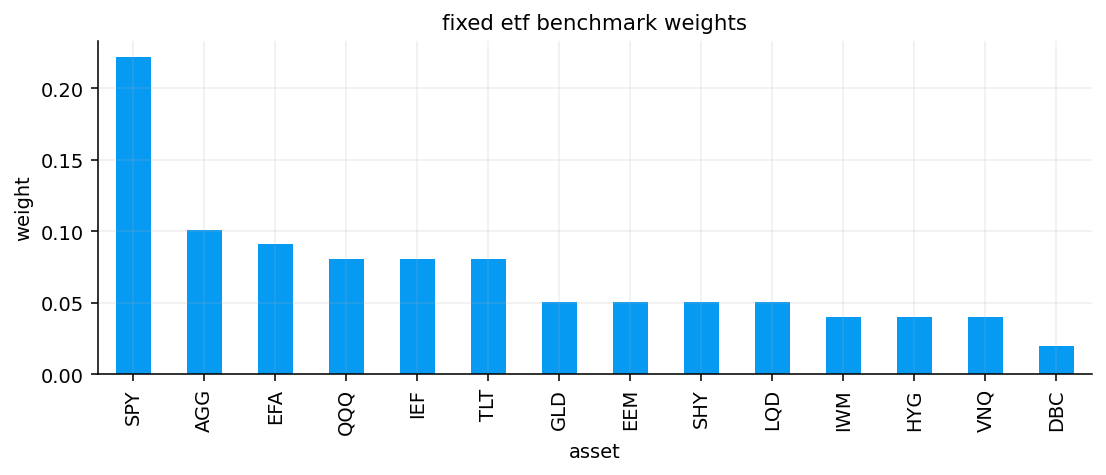

,sleeve,benchmark_weight
7,US equity,0.3434
3,Duration bonds,0.1616
4,International equity,0.1414
1,Core bonds,0.1010
5,Real assets,0.0909
2,Credit,0.0909
6,Short bonds,0.0505
0,Commodities,0.0202


In [13]:
fig, ax = plt.subplots(figsize=(8, 3.5))
benchmark_w.sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("fixed etf benchmark weights")
ax.set_ylabel("weight")
ax.set_xlabel("asset")
plt.tight_layout()
plt.show()
benchmark_sleeve = benchmark_table.groupby("sleeve", as_index=False)["benchmark_weight"].sum().sort_values("benchmark_weight", ascending=False)
display(benchmark_sleeve.round(4))


### 3.2 Building Black-Litterman prior

We now build the first Black-Litterman object: the prior expected return vector.

In ordinary mean-variance optimization, expected returns are usually the weakest input. Historical average returns are noisy, unstable, and extremely sensitive to the sample window. Black-Litterman avoids starting from raw sample means. Instead, we do a reverse action. We now have a portfolio with our defined weights, so there has to be a Mean-Variance that produces these weights with an unknown mean. We are looking for that mean given our weights. We want to see what expected returns would make this benchmark look optimal for an investor?

This is called **reverse optimization**.


### 3.2.1 Estimating $\mu$ from equilibrium

We start with the standard mean-variance utility:

$$
\mathbf{w}_b = \mathbf{w}^\top \boldsymbol{\mu} - \frac{\delta}{2} \mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}
$$


Here $\mu$ is the expected return vector, $\Sigma_t$ is the covariance matrix estimated at time $t$, $w_b$ is the benchmark weight vector, and $\delta_t$ is the risk-aversion coefficient. Higher $\delta$ means the investor wants more compensation for taking variance.

the unconstrained solution is $\mathbf{w}_b^* = \frac{1}{\delta} \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}$, which can be changed to give:

$$
\boldsymbol{\mu}_{\text{eq}} = \delta\, \boldsymbol{\Sigma}\, \mathbf{w}_b
$$

The vector $\mu_\text{eq}$ is the prior expected return vector. If an investor maximizes expected return minus a penalty for variance, then the expected return vector that supports a given benchmark is equal to covariance times benchmark weights. If an asset contributes a lot of risk to the benchmark, it must have a higher implied return to justify its place. If an asset is defensive or low risk, it's implied return is usually lower.

### 3.2.2 Estimating Covariance $\Sigma$ and Risk Aversion $\delta$

We also estimate $\Sigma$ with EWMA covariance. As we analyzes in notebook 2, EWMA puts more weight on recent returns:

$$
\Sigma_t=(1-\lambda)\sum_{j=0}^{L-1}\lambda^j(r_{t-j}-\bar r_t)(r_{t-j}-\bar r_t)^{\top}
$$

A high $\lambda$ such as $0.97$ makes the covariance estimate persistent but still responsive. This is useful for portfolio risk because covariance regimes change: 2020, 2022, and 2025 do not have the same market structure.

The parameter $\delta$ is the **market risk aversion coefficient** which controls the overall scale of the implied returns. Economically, $\delta$ is the additional expected return the representative investor requires per unit of portfolio variance. We get the $\delta$ from benchmark too:

$$
\delta = \frac{\mu_{\text{bench}} - r_f}{\sigma_{\text{bench}}^2}
$$

This is the Sharpe ratio of the benchmark expressed in variance units. It measures how many units of expected excess return the market demands per unit of variance. Rather than assuming a fixed $\delta = 2.5$ (usual in literature), we **estimate it dynamically** at each rebalance date from the rolling historical performance of the benchmark portfolio itself.

> you might be confused about using $\lambda$ as the risk reversion parameter for Mean-Variance model in notebook 2, and here, using $\delta$. We use $\delta$ as the symbol for implied risk aversion, which means extracting it from an existing model/portfolio. But $\lambda$ is used as the parameter of risk aversion for optimizing a model and getting to the optimal portfolio we want.

Note: The prior is not static. At each rebalance date we use the current EWMA covariance estimate, so $\boldsymbol{\mu}_{\text{eq}}$ evolves with the market's volatility and correlation structure.

In [14]:
ewma_lambda = 0.97
delta_fallback = 2.5
delta_min = 0.30
delta_max = 8.00
risk_free_daily = (1.0 + 0.04) ** (1.0 / 252.0) - 1.0


def make_psd(matrix, eps=1e-10):
    arr = np.asarray(matrix, dtype=float)
    arr = 0.5 * (arr + arr.T)
    vals, vecs = np.linalg.eigh(arr)
    vals = np.maximum(vals, eps)
    out = (vecs * vals) @ vecs.T
    return 0.5 * (out + out.T)


def make_psd_df(matrix, index):
    arr = make_psd(np.asarray(matrix, dtype=float), eps=1e-10)
    return pd.DataFrame(arr, index=index, columns=index)


def estimate_ewma_cov_at_date(returns, date, lookback=cov_lookback, lam=ewma_lambda):
    date = pd.Timestamp(date)
    pos = returns.index.searchsorted(date, side="right") - 1
    window = returns.iloc[max(0, pos - lookback + 1):pos + 1].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    cov_ann = estimate_covariance(window, method="EWMA", annualization=annualization, ewma_lambda=lam, return_df=True)
    return cov_ann


def estimate_delta_at_date(returns, date, benchmark_w, lookback=cov_lookback):
    date = pd.Timestamp(date)
    pos = returns.index.searchsorted(date, side="right") - 1
    window = returns.iloc[max(0, pos - lookback + 1):pos + 1][benchmark_w.index].fillna(0.0)
    bench_ret = window @ benchmark_w
    ann_return = float(bench_ret.mean() * annualization)
    ann_var = float(bench_ret.var(ddof=1) * annualization)
    delta = (ann_return - risk_free_daily * annualization) / ann_var
    if not np.isfinite(delta):
        delta = delta_fallback
    return float(np.clip(delta, delta_min, delta_max))


cov_by_date = {}
delta_by_date = {}
prior_mu_by_date = {}
for dt in rebalance_dates:
    cov_ann = estimate_ewma_cov_at_date(returns, dt)
    delta_t = estimate_delta_at_date(returns, dt, benchmark_w)
    prior_mu = pd.Series(delta_t * cov_ann.loc[assets, assets].values @ benchmark_w.loc[assets].values, index=assets)
    cov_by_date[pd.Timestamp(dt)] = cov_ann
    delta_by_date[pd.Timestamp(dt)] = delta_t
    prior_mu_by_date[pd.Timestamp(dt)] = prior_mu

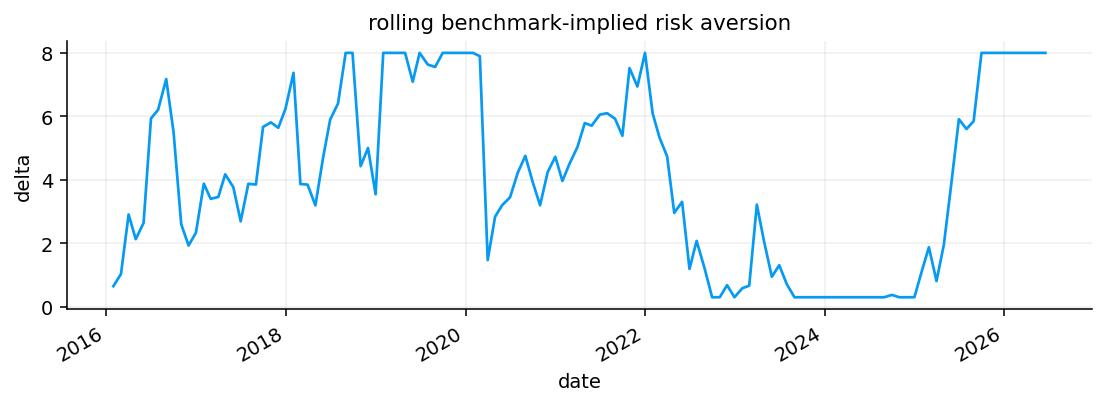

,asset,prior_mu,benchmark_weight
0,EEM,0.2775,0.0505
1,GLD,0.2091,0.0505
2,QQQ,0.2056,0.0808
3,IWM,0.1822,0.0404
4,EFA,0.1652,0.0909
5,SPY,0.1337,0.2222
6,TLT,0.0511,0.0808
7,VNQ,0.0477,0.0404
8,LQD,0.0425,0.0505
9,HYG,0.0376,0.0404


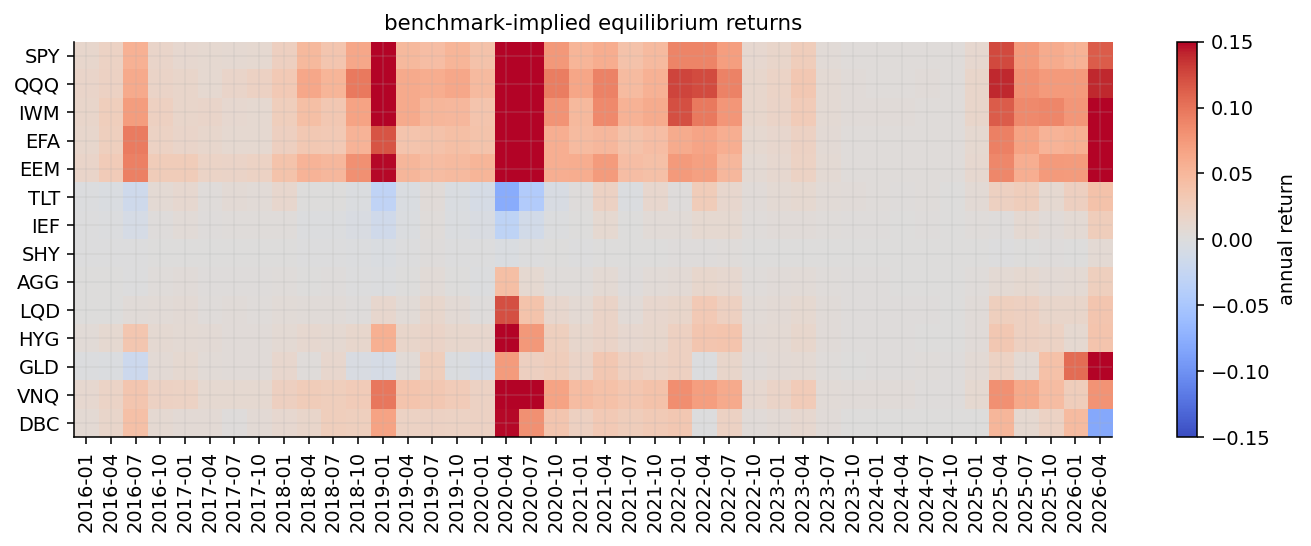

In [15]:
delta_series = pd.Series(delta_by_date).sort_index()
ax = delta_series.plot(figsize=(8, 3), lw=1.4)
ax.set_title("rolling benchmark-implied risk aversion")
ax.set_ylabel("delta")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()

latest_rebalance_date = rebalance_dates[-1]
latest_prior = prior_mu_by_date[pd.Timestamp(latest_rebalance_date)].sort_values(ascending=False)
prior_table = pd.DataFrame({"asset": latest_prior.index, "prior_mu": latest_prior.values,
                             "benchmark_weight": benchmark_w.reindex(latest_prior.index).values})
display(prior_table.round(4))

prior_mu_frame = pd.DataFrame(prior_mu_by_date).T.sort_index()
prior_mu_heat = prior_mu_frame.iloc[::max(1, len(prior_mu_frame) // 36)].T
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(prior_mu_heat, aspect="auto", cmap="coolwarm", vmin=-0.15, vmax=0.15)
ax.set_title("benchmark-implied equilibrium returns")
ax.set_yticks(range(len(prior_mu_heat.index)), prior_mu_heat.index)
ax.set_xticks(range(len(prior_mu_heat.columns)), [d.strftime("%Y-%m") for d in prior_mu_heat.columns], rotation=90)
fig.colorbar(im, ax=ax, label="annual return")
plt.tight_layout()
plt.show()


The latest prior table ranks EEM at about $21.5\%$, EFA around $17.2\%$, GLD around $16.5\%$, IWM around $15.5\%$, QQQ around $14.1\%$, and SPY around $11.3\%$. These are annualized equilibrium returns implied by the benchmark, the latest covariance estimate, and the risk-aversion estimate.

When the latest prior ranks EEM, EFA, GLD, IWM, QQQ, and SPY highly, it's not simply saying these assets will have higher return, It's saying that in the latest covariance estimate, and based on the benchmark exposures, those assets carry some kind of risk contribution that needs higher equilibrium return. DBC having a negative prior in the latest table means the benchmark and covariance structure do not naturally reward DBC in the same way at that time, so any active overweight to commodities must come from views rather than from the prior alone. This means we say on default, investing on commodities doesn't benefit us in the way we want it, but since we use Black-Litterman, our views might show us things we don't kno, guiding us to invest on them in the right time.

GLD receiving a high prior is interesting. Gold does not always have high historical average return, but in a covariance-based prior it can receive more implied return when it contributes useful portfolio risk control maybe as a diversification power. This is one of the reasons Black-Litterman is more stable than raw historical mean estimation.

In periods when an asset becomes more volatile or more connected to the benchmark, its implied prior can move. In 2020 and parts of 2022 which are stress regimes, implied returns change a lot because covariance and benchmark risk conditions changed suddenly. This is better than using one fixed prior for the whole sample. If market risk structure changes, the return should update too.

## 4) Building baseline strategies

We now run the baseline portfolio models from the portfolios we made in notebook 2, and compare them against the strategic benchmark.

A quick reminder from notebook 2: The minimum-variance problem is

$$
\min_w w^{\top}\Sigma w
$$

subject to the usual constraints like full investment, long-only weights, caps, and sleeve bounds.

The mean-variance problem is

$$
\max_w w^{\top}\mu-\lambda w^{\top}\Sigma w
$$

where $\mu$ is the expected return vector. The problem is that $\hat\mu$ is noisy. A small change in expected returns can create a large change in weights. This is why the baseline uses shrinkage-style inputs such as Ledoit-Wolf covariance and Bayes-Stein means as we implemented and explained in notebook 2, here we don't repeat the code and use the library's grid function for producing models.

In [16]:
cost_bps = 10.0
bl_mv_lambda = 4.0

def backtest_result_to_dict(name, result, fallback_flags=None):
    flags = pd.Series(dtype=float) if fallback_flags is None else pd.Series(fallback_flags).sort_index()
    return {
        "returns": result.net_returns.rename(name), "gross_returns": result.gross_returns.rename(name),
        "nav": result.net_values.rename(name), "gross_nav": result.gross_values.rename(name),
        "weights": result.weights.copy(), "turnover": result.turnover.rename(name),
        "costs": result.costs.rename(name), "fallback_flags": flags.rename(name),
        "fallback_count": int(result.fallbacks)}


def strategic_weight_schedule():
    rows = [benchmark_w.reindex(assets).rename(pd.Timestamp(dt)) for dt in rebalance_dates[:-1]]
    flags = pd.Series(0.0, index=pd.DatetimeIndex(rebalance_dates[:-1]))
    return pd.DataFrame(rows), flags


strategic_weights, strategic_flags = strategic_weight_schedule()
strategic_backtest = run_many_weights_backtests(
    {"Strategic Benchmark": strategic_weights}, returns=returns[assets],
    cost_bps=cost_bps, w_min=w_min, w_max=None,
    long_only=True, normalize=True, weight_timing="next_close")["Strategic Benchmark"]

fixed_universe_by_date = {
    pd.Timestamp(dt): {"tickers": list(assets), "avg_dollar_volume": pd.Series(1.0, index=assets)}
    for dt in rebalance_dates}

walkforward_grid = run_walkforward_grid(
    returns=returns[assets], close=close[assets],
    rebalance_dates=rebalance_dates,
    universe_by_date=fixed_universe_by_date,
    cov_lookback=cov_lookback, mu_lookback=mu_lookback,
    min_cov_observations=cov_lookback - 1,
    min_mu_observations=mu_lookback - 1,
    max_weight=w_max, min_weight=w_min, long_only=True,
    trading_cost_bps=cost_bps, turnover_penalty_bps=cost_bps,
    fallback="equal", rf_daily=risk_free_daily,
    annualization=annualization,
    optimizer_params={
        "MV": {"mv_lambda": bl_mv_lambda},
        "RidgeMV": {"mv_lambda": bl_mv_lambda},
        "FrontierGrid": {"grid_n": 15}})


best_minvar, best_mv = selection.select_finalists(
    walkforward_grid.results,
    minvar_n=1,
    mv_n=1,
    ridge_n=0,
    maxsharpe_n=0,
    include_frontier=False,
    include_baseline=False,
    metric="Sharpe",
)

baseline_candidates = {
    "Strategic Benchmark": backtest_result_to_dict("Strategic Benchmark", strategic_backtest, strategic_flags),
    "Equal Weight": backtest_result_to_dict("Equal Weight", walkforward_grid.backtests["EW"]),
    best_minvar: backtest_result_to_dict(best_minvar, walkforward_grid.backtests[best_minvar]),
    best_mv: backtest_result_to_dict(best_mv, walkforward_grid.backtests[best_mv])}

baseline_results = {name: baseline_candidates[name] for name in ["Strategic Benchmark", "Equal Weight", best_minvar, best_mv]}


In [17]:
candidate_rows = []
for name, result in baseline_candidates.items():
    m = selection.performance_metrics(
        result["returns"],
        result["nav"],
        rf_daily=risk_free_daily,
        annualization=annualization,
    )
    candidate_rows.append({
        "strategy": name,
        "cagr": m["CAGR"],
        "ann_vol": m["Vol"],
        "sharpe": m["Sharpe"],
        "max_drawdown": m["Max Drawdown"],
        "avg_turnover": result["turnover"].mean(),
    })

baseline_candidate_summary = pd.DataFrame(candidate_rows).sort_values("sharpe", ascending=False)
display(baseline_candidate_summary.round(4))


,strategy,cagr,ann_vol,sharpe,max_drawdown,avg_turnover
0,Strategic Benchmark,0.0914,0.1014,0.5284,-0.2242,0.0144
3,"MV (LedoitWolf, BayesStein)",0.0814,0.0847,0.4949,-0.1378,0.0369
1,Equal Weight,0.0848,0.0935,0.4842,-0.2038,0.0114
2,MinVar (OAS),0.0665,0.0754,0.3543,-0.1973,0.0031


,avg_turnover
Strategic Benchmark,0.0144
Equal Weight,0.0114
MinVar (OAS),0.0031
"MV (LedoitWolf, BayesStein)",0.0369


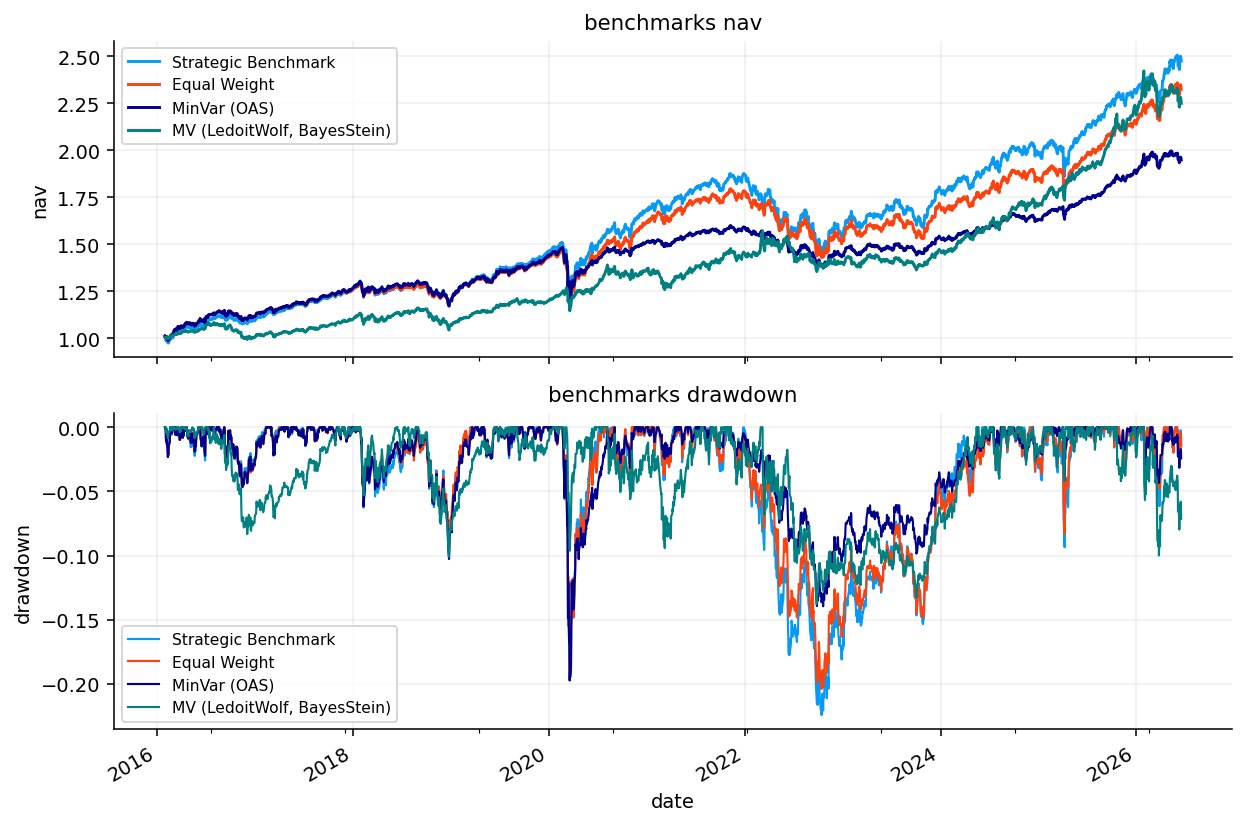

In [18]:
avg_turnover_table = pd.DataFrame({name: result["turnover"].mean() for name, result in baseline_results.items()}, index=["avg_turnover"]).T
display(avg_turnover_table.round(4))
baseline_nav = pd.DataFrame({name: result["nav"] for name, result in baseline_results.items()})
baseline_dd = baseline_nav / baseline_nav.cummax() - 1.0
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
baseline_nav.plot(ax=axes[0])
axes[0].set_title("benchmarks nav")
axes[0].set_ylabel("nav")
baseline_dd.plot(ax=axes[1], lw=1.1)
axes[1].set_title("benchmarks drawdown")
axes[1].set_ylabel("drawdown")
axes[1].set_xlabel("date")
plt.tight_layout() 
plt.show()


As we can see, the strategic benchmark has the highest Sharpe ratio, around $0.52$, with a CAGR around $9.1\%$ and volatility around $10.1\%$.

The MV Model using Ledoit-Wolf and Bayes-Stein has the lowest drawdown among these baselines, around $-13.8\%$, and volatility around $8.4\%$, but its CAGR is also lower than the benchmark. So it is safer in path terms, but it does not beat the benchmark on return and Sharpe. Equal weight is close but slightly weaker. The minimum-variance portfolio has lower volatility around $7.6\%$, but its CAGR is only around $6.8\%$ and its Sharpe is around $0.38$. 

This is an issue that MinVar has in These assets, there are some low volatility assets that also have really low return like SHY is almost one of the safest investments and one of the lowest returns, a model like Min-Variance will overweight it to reduce volatility. But reducing variance does not automatically create a better return-risk tradeoff if the portfolio gives up too much return. That's why it ennds up as the lowest Sharpe model in our benchmarks. For these assets specifically, taking return more seriously is more important than the stock market that we tested in notebook 2, because there were a lot of very high return-high risk stocks in nasdaq market and controlling risk was really important to a better performance. But here, we have all ETFs having lower volatility compared to the stocks, but also not that high of return, so having higher return in a way to control risk enough, is important, Because in this specific set of assets, reducing volatility too much, will hurt returns too much.

Another Note is our made benchmark being the best Sharpe between the models, even if the views don't add anything or even move the benchmark to wrong direction, the Black-Litterman model still can end up with better Sharpe than other models, so we have to really check the difference of Sharpe between the strategic benchmark and BL model to be able to tell if the views and their confidence have added anything and had positive effect on return and sharpe compared to benchmark or not.

---

## 5) market signals

Before making a Black-Litterman view, we need a way to describe the market environment. We use signals that are common in asset allocation: momentum, trend, volatility, drawdown quality, dividend yield, relative strength and correlation

**Momentum signals:** Computed as the cumulative return of an asset over a trailing window, excluding the most recent month (the standard momentum definition avoids short-term reversal), for example, this is how a 6 month momentum is calculated:

$$
\text{Mom}_{t,i}^{(126,21)}=\prod_{s=t-125}^{t-21}(1+r_{s,i})-1
$$

We compute this for 1-month, 3-month including recent, 6-to-1 month, and 12-to-1 month.

**Trend signals:** The price of each asset relative to its $n$-day simple moving average (SMA), normalized by the SMA:
$$
\text{Trend}_n = \frac{\text{Price} - \text{SMA}_n}{\text{SMA}_n}
$$

or more clearly:

$$
\text{Trend}_{t,i}^{(L)}=\frac{P_{t,i}}{\frac{1}{L}\sum_{s=t-L+1}^{t}P_{s,i}}-1
$$

A positive 200-day trend means the asset is in a long-term uptrend. Negative means a downtrend. This is one of the almost close to momentum and give us information about recent perofemance in a different way.

**Volatility and drawdown signals:** Rolling 63-day volatility and trailing 252-day drawdown capture the risk profile and stress state of each asset.

**Composite score:** Each asset gets an overall score combining the above signals, which ranks assets from most to least attractive for overweighting relative to the benchmark. This score is used as a sorting tool inside view-generation rules. But these scores might not be in the same scale, and we have to make them comparable to each other.

Therefore we use cross-sectional z-scores. A z-score shows us whether an asset's signal is strong or weak relative to the other assets at the same date. A z-score turns different things into comparable units. The basic idea is

$$
z_{t,i}=\frac{x_{t,i}-\mathrm{median}(x_t)}{\mathrm{scale}(x_t)}
$$

The point is not to make one perfect signal. The point is to avoid relying on a single noisy indicator and try to cover different sides of behaviour of these assets. Momentum, trend, volatility, and drawdown quality each capture a different part of the market state.

**Market state signals:** besides per-asset signals, we compute a set of **market-wide state variables** that describe the current market environment:
- fraction of risky assets (SPY, QQQ, IWM, EEM, HYG, VNQ, DBC) above their 200-day SMA, measures broad market health
- current SPY drawdown from its 252-day high detects whether we are in an equity stress environment which can be very important for weighting in this set of assets.
- rolling 126-day correlation between SPY and TLT is important for understanding whether diversification is working
- relative cumulative returns of one ETF versus another over 63 days is the market's current relative performance signal that directly feed into views

In [19]:
risky_asset_names = ["SPY", "QQQ", "IWM", "EFA", "EEM", "HYG", "VNQ", "DBC"]
cyclical_asset_names = ["IWM", "EEM", "VNQ", "HYG"]
defensive_asset_names = ["TLT", "IEF", "SHY", "AGG", "LQD", "GLD"]


def winsorized_zscore(series):
    s = pd.Series(series, dtype=float).replace([np.inf, -np.inf], np.nan)
    good = s.dropna()
    clipped = s.clip(good.quantile(0.05), good.quantile(0.95))
    std = clipped.std(ddof=0)
    return ((clipped - clipped.mean()) / std).fillna(0.0)


def cumulative_return(window):
    if window is None or len(window) == 0:
        return np.nan
    return float((1.0 + window.dropna()).prod() - 1.0)


def trailing_dividend_yield(dividends, close_hist, ticker, lookback=252):
    if dividends is None or dividends.empty or ticker not in dividends.columns or ticker not in close_hist.columns:
        return np.nan
    div_window = dividends[ticker].reindex(close_hist.index).fillna(0.0).tail(lookback)
    px = close_hist[ticker].dropna()
    if px.empty or px.iloc[-1] <= 0:
        return np.nan
    return float(div_window.sum() / px.iloc[-1])


def relative_cumulative_return(ret_hist, long_asset, short_asset, lookback=63):
    if long_asset not in ret_hist.columns or short_asset not in ret_hist.columns or len(ret_hist) < lookback:
        return np.nan
    long_ret = cumulative_return(ret_hist[long_asset].tail(lookback))
    short_ret = cumulative_return(ret_hist[short_asset].tail(lookback))
    return long_ret - short_ret if np.isfinite(long_ret) and np.isfinite(short_ret) else np.nan


def trailing_pair_correlation(ret_hist, asset_a, asset_b, lookback=126):
    if asset_a not in ret_hist.columns or asset_b not in ret_hist.columns or len(ret_hist) < lookback:
        return np.nan
    window = ret_hist[[asset_a, asset_b]].tail(lookback).dropna()
    if len(window) < max(30, lookback // 3):
        return np.nan
    if window[asset_a].std(ddof=1) <= 1e-12 or window[asset_b].std(ddof=1) <= 1e-12:
        return np.nan
    corr = float(window[asset_a].corr(window[asset_b]))
    return corr if np.isfinite(corr) else np.nan


def trailing_average_correlation(ret_hist, names, lookback=126):
    names = [x for x in names if x in ret_hist.columns]
    if len(names) < 2 or len(ret_hist) < lookback:
        return np.nan
    window = ret_hist[names].tail(lookback).dropna(how="any")
    if len(window) < max(30, lookback // 3):
        return np.nan
    corr = window.corr().replace([np.inf, -np.inf], np.nan)
    vals = corr.where(~np.eye(len(corr), dtype=bool)).stack().dropna()
    return float(vals.mean()) if len(vals) else np.nan


def trend_breadth_from_close(close_hist, names, ma_window=200, offset=0):
    names = [x for x in names if x in close_hist.columns]
    if not names:
        return np.nan
    hist = close_hist.iloc[:len(close_hist) - offset] if offset and len(close_hist) > offset else close_hist
    vals = []
    for ticker in names:
        px = hist[ticker].dropna()
        if len(px) < ma_window:
            continue
        ma = px.tail(ma_window).mean()
        if ma > 0:
            vals.append(px.iloc[-1] / ma - 1.0)
    return float((pd.Series(vals) > 0).mean()) if vals else np.nan

In [20]:
def compute_asset_signals(close, returns, date, dividends=None):
    date = pd.Timestamp(date)
    close_pos = close.index.searchsorted(date, side="right") - 1
    ret_pos = returns.index.searchsorted(date, side="right") - 1
    close_hist = close.iloc[:close_pos + 1]
    ret_hist = returns.iloc[:ret_pos + 1]
    rows = []
    for ticker in returns.columns:
        px = close_hist[ticker].dropna() if ticker in close_hist else pd.Series(dtype=float)
        rt = ret_hist[ticker].dropna() if ticker in ret_hist else pd.Series(dtype=float)
        if len(px) < 200 or len(rt) < 63:
            continue
        mom_1_0 = cumulative_return(rt.tail(21))
        mom_3_0 = cumulative_return(rt.tail(63))
        mom_6_1 = cumulative_return(rt.iloc[-147:-21]) if len(rt) >= 147 else np.nan
        mom_12_1 = cumulative_return(rt.iloc[-273:-21]) if len(rt) >= 273 else np.nan
        trend_50 = float(px.iloc[-1] / px.tail(50).mean() - 1.0) if px.tail(50).mean() > 0 else np.nan
        trend_200 = float(px.iloc[-1] / px.tail(200).mean() - 1.0) if px.tail(200).mean() > 0 else np.nan
        vol_63 = float(rt.tail(63).std(ddof=1) * math.sqrt(annualization))
        high_252 = px.tail(252).max()
        dd_252 = float(px.iloc[-1] / high_252 - 1.0) if high_252 > 0 else np.nan
        rows.append({
            "ticker": ticker,
            "sleeve": sleeve_map.get(ticker, "Other"),
            "mom_1_0": mom_1_0, "mom_3_0": mom_3_0,
            "mom_6_1": mom_6_1, "mom_12_1": mom_12_1,
            "trend_50": trend_50, "trend_200": trend_200,
            "vol_63": vol_63, "dd_252": dd_252, "drawdown_quality": dd_252,
            "dividend_yield_252": trailing_dividend_yield(dividends, close_hist, ticker)})
        
    asset_signal_table = pd.DataFrame(rows).set_index("ticker") if rows else pd.DataFrame()
    if asset_signal_table.empty:
        return asset_signal_table, {}
    asset_signal_table["score"] = (
        0.25 * winsorized_zscore(asset_signal_table["mom_3_0"])
        + 0.25 * winsorized_zscore(asset_signal_table["mom_6_1"])
        + 0.15 * winsorized_zscore(asset_signal_table["mom_12_1"])
        + 0.20 * winsorized_zscore(asset_signal_table["trend_200"])
        - 0.10 * winsorized_zscore(asset_signal_table["vol_63"])
        + 0.05 * winsorized_zscore(asset_signal_table["drawdown_quality"]))
    
    scores = asset_signal_table["score"]
    risky_available = [ticker for ticker in risky_asset_names if ticker in scores.index]
    defensive_available = [ticker for ticker in defensive_asset_names if ticker in scores.index]
    cyclical_available = [ticker for ticker in cyclical_asset_names if ticker in scores.index]
    risky_trend_breadth = float((asset_signal_table.reindex(risky_available)["trend_200"] > 0).mean()) if risky_available else np.nan
    cyclical_trend_breadth = float((asset_signal_table.reindex(cyclical_available)["trend_200"] > 0).mean()) if cyclical_available else np.nan
    risky_trend_breadth_3m_ago = trend_breadth_from_close(close_hist, risky_available, offset=63)
    cyclical_trend_breadth_3m_ago = trend_breadth_from_close(close_hist, cyclical_available, offset=63)
    spy_drawdown_252 = float(asset_signal_table.loc["SPY", "dd_252"]) if "SPY" in asset_signal_table.index else np.nan
    spy_vol_63 = float(asset_signal_table.loc["SPY", "vol_63"]) if "SPY" in asset_signal_table.index else np.nan
    spy_vol_line = ret_hist["SPY"].rolling(63).std() * math.sqrt(annualization) if "SPY" in ret_hist.columns else pd.Series(dtype=float)
    vol_sample = spy_vol_line.dropna().tail(252)
    spy_vol_threshold = vol_sample.quantile(0.80) if not vol_sample.empty else np.nan
    spy_vol_z = float((spy_vol_63 - vol_sample.mean()) / vol_sample.std(ddof=1)) if len(vol_sample) > 20 and vol_sample.std(ddof=1) > 1e-12 else np.nan
    spy_tlt_corr_126 = trailing_pair_correlation(ret_hist, "SPY", "TLT", 126)
    spy_ief_corr_126 = trailing_pair_correlation(ret_hist, "SPY", "IEF", 126)
    stock_bond_corr_126 = spy_tlt_corr_126 if np.isfinite(spy_tlt_corr_126) else spy_ief_corr_126
    market_state = {
        "risky_median_score": float(scores.reindex(risky_available).median()) if risky_available else np.nan,
        "defensive_median_score": float(scores.reindex(defensive_available).median()) if defensive_available else np.nan,
        "risk_on_score": (float(scores.reindex(risky_available).median()) - float(scores.reindex(defensive_available).median())) if risky_available and defensive_available else np.nan,
        "risky_trend_breadth": risky_trend_breadth,
        "risky_trend_breadth_3m_ago": risky_trend_breadth_3m_ago,
        "risky_trend_breadth_change_63": risky_trend_breadth - risky_trend_breadth_3m_ago if np.isfinite(risky_trend_breadth) and np.isfinite(risky_trend_breadth_3m_ago) else np.nan,
        "cyclical_trend_breadth": cyclical_trend_breadth,
        "cyclical_trend_breadth_3m_ago": cyclical_trend_breadth_3m_ago,
        "cyclical_trend_breadth_change_63": cyclical_trend_breadth - cyclical_trend_breadth_3m_ago if np.isfinite(cyclical_trend_breadth) and np.isfinite(cyclical_trend_breadth_3m_ago) else np.nan,
        "spy_trend_200": float(asset_signal_table.loc["SPY", "trend_200"]) if "SPY" in asset_signal_table.index else np.nan,
        "spy_drawdown_252": spy_drawdown_252,
        "spy_vol_63": spy_vol_63,
        "spy_vol_z": spy_vol_z,
        "equity_stress": bool((np.isfinite(spy_drawdown_252) and spy_drawdown_252 < -0.10) or (np.isfinite(spy_vol_63) and np.isfinite(spy_vol_threshold) and spy_vol_63 > spy_vol_threshold)),
        "qqq_spy_63": relative_cumulative_return(ret_hist, "QQQ", "SPY", 63),
        "qqq_spy_126": relative_cumulative_return(ret_hist, "QQQ", "SPY", 126),
        "hyg_lqd_63": relative_cumulative_return(ret_hist, "HYG", "LQD", 63),
        "hyg_lqd_126": relative_cumulative_return(ret_hist, "HYG", "LQD", 126),
        "iwm_spy_63": relative_cumulative_return(ret_hist, "IWM", "SPY", 63),
        "iwm_spy_126": relative_cumulative_return(ret_hist, "IWM", "SPY", 126),
        "eem_efa_63": relative_cumulative_return(ret_hist, "EEM", "EFA", 63),
        "dbc_ief_63": relative_cumulative_return(ret_hist, "DBC", "IEF", 63),
        "dbc_agg_63": relative_cumulative_return(ret_hist, "DBC", "AGG", 63),
        "dollar_trend": float(asset_signal_table.loc["UUP", "trend_200"]),
        "dollar_mom_3_0": float(asset_signal_table.loc["UUP", "mom_3_0"]),
        "spy_tlt_corr_126": spy_tlt_corr_126, "spy_ief_corr_126": spy_ief_corr_126,
        "stock_bond_corr_126": stock_bond_corr_126,
        "avg_risky_corr_126": trailing_average_correlation(ret_hist, risky_available, 126),
        "avg_risky_corr_63": trailing_average_correlation(ret_hist, risky_available, 63),
        "asset_corr_to_spy_126": {asset: trailing_pair_correlation(ret_hist, asset, "SPY", 126) for asset in asset_signal_table.index if asset != "SPY"},
        "real_asset_score": float(scores.reindex([x for x in ["GLD", "DBC"] if x in scores.index]).median()) if any(x in scores.index for x in ["GLD", "DBC"]) else np.nan,
        "bond_score": float(scores.reindex([x for x in ["TLT", "IEF", "AGG"] if x in scores.index]).median()) if any(x in scores.index for x in ["TLT", "IEF", "AGG"]) else np.nan}
    return asset_signal_table.sort_values("score", ascending=False), market_state

In [21]:
latest_signal_table, latest_market_state = compute_asset_signals(signal_close, signal_returns, latest_rebalance_date, dividends=dividends_all)
signal_display_cols = ["sleeve", "mom_1_0", "mom_3_0", "mom_6_1", "trend_50", "trend_200", "vol_63", "dd_252", "dividend_yield_252", "score"]
display(latest_signal_table[signal_display_cols].reset_index().round(4))

latest_market_state_table = pd.DataFrame([latest_market_state], index=[pd.Timestamp(latest_rebalance_date)])
latest_market_state_table.index.name = "date"
display(latest_market_state_table.round(4))


,ticker,sleeve,mom_1_0,mom_3_0,mom_6_1,trend_50,trend_200,vol_63,dd_252,dividend_yield_252,score
0,EEM,International equity,0.0607,0.1973,0.1997,0.0522,0.1871,0.3267,-0.0266,0.0162,1.2184
1,QQQ,US equity,0.0236,0.2160,0.1632,0.0464,0.1526,0.2318,-0.0317,0.0039,1.0964
2,IWM,US equity,0.0529,0.1811,0.1715,0.0352,0.1303,0.2173,-0.0162,0.0092,0.9919
3,DBC,Commodities,-0.1170,-0.0533,0.4152,-0.0717,0.1025,0.2293,-0.1256,0.0268,0.4554
4,SPY,US equity,0.0031,0.1233,0.1054,0.0175,0.0806,0.1542,-0.0245,0.0100,0.4530
5,EFA,International equity,0.0269,0.0903,0.0941,0.0212,0.0785,0.2135,-0.0051,0.0324,0.2341
6,VNQ,Real assets,0.0063,0.0508,0.0839,-0.0015,0.0503,0.1629,-0.0294,0.0365,-0.0835
7,UUP,Dollar,0.0173,0.0118,0.0205,0.0199,0.0349,0.0571,0.0000,0.0329,-0.3577
8,HYG,Credit,0.0075,0.0195,0.0212,0.0017,0.0145,0.0524,-0.0039,0.0592,-0.3689
9,SHY,Short bonds,0.0003,0.0012,0.0093,-0.0012,0.0040,0.0167,-0.0042,0.0369,-0.5029


,risky_median_score,defensive_median_score,risk_on_score,risky_trend_breadth,risky_trend_breadth_3m_ago,risky_trend_breadth_change_63,cyclical_trend_breadth,cyclical_trend_breadth_3m_ago,cyclical_trend_breadth_change_63,spy_trend_200,spy_drawdown_252,spy_vol_63,spy_vol_z,equity_stress,qqq_spy_63,qqq_spy_126,hyg_lqd_63,hyg_lqd_126,iwm_spy_63,iwm_spy_126,eem_efa_63,dbc_ief_63,dbc_agg_63,dollar_trend,dollar_mom_3_0,spy_tlt_corr_126,spy_ief_corr_126,stock_bond_corr_126,avg_risky_corr_126,avg_risky_corr_63,asset_corr_to_spy_126,real_asset_score,bond_score
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-06-17,0.4542,-0.6078,1.062,1.0,1.0,0.0,1.0,1.0,0.0,0.0806,-0.0245,0.1542,0.4066,True,0.0927,0.0917,0.0071,0.01,0.0578,0.0646,0.107,-0.0451,-0.0556,0.0349,0.0118,0.3429,0.4085,0.3429,0.4427,0.44,"{'QQQ': 0.9412363206836531, 'IWM': 0.856072019...",-0.1064,-0.6796


From the latest signals (2026-06-17) table, we can see that EEM has the strongest latest score by a wide margin. It has strong recent momentum, strong medium-term momentum, a positive trend, and a small drawdown. DBC, IWM, QQQ, SPY and EFA also score positively, while several bond and credit ETFs score negatively.

The latest market-state also shows the same thing. The risky median score is above the defensive median score, so the risk-on score is positive. Risky trend breadth and cyclical trend breadth are both strong. SPY is not in a deep drawdown, and the equity stress flag is false. The commodity-versus-duration signal is also strong because DBC has been outperforming duration-sensitive bond exposures.

This is not yet a portfolio decision. It is an information layer. We are learning what the current market looks like: risk-on, commodity-positive, cyclicals reasonably strong, bonds relatively weak, and dollar strength present but not dominant enough to overturn the other signals. Now we want to use these signals and states to generate the views that directly effect on Black-Litterman model.

---


## 6) Black-Litterman views

We now translate market signals into views. This is the conceptual center of the notebook.

A **view** in Black-Litterman is a statement of the form: "I believe that asset (or portfolio) $A$ will outperform asset (or portfolio) $B$ by $q$ per year." Formally, a view is a pair $(\mathbf{p}, q)$ where $\mathbf{p} \in \mathbb{R}^N$ is a portfolio vector encoding which assets are long and which are short, and $q \in \mathbb{R}$ is the expected excess return of that portfolio vector $\mathbf{p}$.

The portfolio vector $\mathbf{p}$ for a simple relative view (asset $A$ outperforms asset $B$) is:
$$
p_i = \begin{cases} +1/|L| & \text{if asset } i \text{ is long} \\ -1/|S| & \text{if asset } i \text{ is short} \\ 0 & \text{otherwise} \end{cases}
$$

where $|L|$ and $|S|$ are the number of long and short assets in the view. This equal-weighting within each side keeps views comparable in scale. The vector $\mathbf{p}$ sums to zero (long equals short), which means the view expresses a **relative return** rather than an absolute level.

If we have $K$ views and $N$ assets, we are working with a view **matrix** $P$ that has shape $K\times N$. Each row of $P$ defines one long-short or relative-return portfolio. The view vector $q$ has length $K$ and contains the expected return attached to each view.

For one view $k$, the statement is

$$
P_k\mu=q_k
$$

For $K$ views, all rows stack into the view matrix:

$$
P=\begin{bmatrix}p_1^{\top}\\p_2^{\top}\\\vdots\\p_K^{\top}\end{bmatrix}
$$

And we have the expected returns $q$ vector and each row's expected return as:

$$
q=\begin{bmatrix}q_1\\q_2\\\vdots\\q_K\end{bmatrix} \qquad p_i^{\top}\mu=q_i
$$

If the view is “QQQ and SPY should outperform HYG and VNQ,” then the portfolio row could look like a long-short spread with positive weights on QQQ and SPY, negative weights on HYG and VNQ, and zeros elsewhere. The row sums to zero when it is a relative view.

This is useful because it means the view is not simply bullish on the whole market. It shows one set of assets should beat another set.

We don't just use these "this asset will outperform that one" type of views, these can be useful for someone who actually has a belief or information about the market and expects something to happen in near future. 

but we want to make views that can work and track different states and regimes of markets and be useful most of the time. we make several economically motivated view families. 

But how we write these views in math form for this model? we extract a portfolio vector out of it with expected return of that portfolio. we can't just say "SPY is going to outperform EEM", but we can say "i have a portfolio $\mathbf{p}$ with weights 50% on SPY and -50% on EEM with expected return $q$ of $0.50\mu_{\mathrm{SPY}}-0.50\mu_{\mathrm{EEM}}$".

If the universe is ordered as SPY, QQQ, IWM, EFA, EEM, TLT, IEF, SHY, AGG, LQD, HYG, GLD, VNQ, DBC, then one inflation-style view could look like:

$$
p_i=\begin{bmatrix}0 & 0 & 0 & 0 & 0 & -0.25 & -0.25 & 0 & -0.25 & -0.25 & 0 & 0.50 & 0 & 0.50\end{bmatrix}
$$

The view return is the dot product:

$$
p_i^{\top}\mu=0.50\mu_{\mathrm{GLD}}+0.50\mu_{\mathrm{DBC}}-0.25\mu_{\mathrm{TLT}}-0.25\mu_{\mathrm{IEF}}-0.25\mu_{\mathrm{AGG}}-0.25\mu_{\mathrm{LQD}}
$$

That is why Black-Litterman views are so useful. They allow us to include views and predictions inside of portfolio without needing to forecast every single asset's standalone return.

---

### 6.1. constructing the views

**1. Liquidity Leadership:** This view shows when large-cap US growth (SPY, QQQ) is outperforming cyclical and small-cap assets (IWM, EEM, VNQ, HYG) on a trend and momentum basis. Economically, this corresponds to a **narrow market leadership** regime when investors are concentrating risk in the most liquid, high-quality names rather than spreading into cyclicals. This is often seen in late-cycle or uncertainty environments. The view goes long the leaders (SPY, QQQ) and short the lagging cyclicals.

**2. Dual Momentum:** This is a cross-sectional momentum view. The assets with the best recent risk-adjusted momentum scores are expected to continue outperforming the assets with the worst scores. The view is formed by going long the top-ranked assets and short the bottom-ranked across all 14 ETFs. This actually works very much in practice even though it's completely backward-looking.

**3. Inflation Rotation:** This view shows when real assets (GLD, DBC) are outperforming fixed income (IEF, AGG) on a trend basis, signalling an inflationary environment. Economically, when commodities and gold are trending up relative to bonds, the market is pricing in higher inflation expectations. The view goes long real assets and short bonds.

**4. Risk-Adjusted Momentum:** A more sophisticated version of dual momentum that addresses volatility too. Assets are ranked by their Sharpe-ratio-like signal (return per unit of recent volatility). High Sharpe-ratio assets are expected to continue outperforming low Sharpe-ratio assets.

**5. Credit Switch:** When HYG (high yield) is significantly outperforming LQD (investment grade) on a relative basis, the credit market is in risk-on state. This view goes long high yield and short investment grade, betting that credit spreads will continue to compress. When HYG is underperforming, the signal reverses.

**6. Reflation Breadth:** This view detects a broad economic reflation. A regime where small caps outperform large caps (IWM > SPY), high yield outperforms investment grade, cyclical trend breadth is high, and commodities are trending. When all these conditions are confirmed together, the view goes long cyclicals (IWM, EEM, VNQ, HYG, DBC) and short SPY, TLT. This is the close to risk-on, reflation macro regime.

**7. Growth-Duration Barbell:** This view shows when equity momentum (QQQ/SPY relative performance) and bond momentum (TLT/IEF) are strong together, suggesting the market is rewarding both growth and duration. This is a barbell view. long growth equity and long-duration bonds, short the middle (IWM, EEM, HYG). This regime covers much of the 2014–2020 period.

**8. Correlation Stress:** When the stock-bond correlation turns positive (both stocks and bonds are falling together, as happened in 2022), the traditional diversification benefit of bonds breaks down. This view reduces long duration exposure (TLT, IEF) and favours real assets and short duration (GLD, SHY) as alternative diversifiers.

**9. International Rotation:** This view tracks the relative performance of emerging markets (EEM) versus developed international (EFA). When EEM is outperforming EFA on momentum, it signals a risk-on, dollar-weak, commodity-supportive environment. The view goes long EEM and short EFA. When the dollar (UUP) is strengthening, we control this view to not get it fired up and avoid false signal.

**10. Duration Quality:** This view monitors the relative performance of long-duration bonds (TLT) versus short-duration (SHY) to determine the slope of the term premium. A positive signal (TLT outperforming SHY) shows the market is pricing in falling rates and suggests an overweight in long duration.

In [22]:
view_caps = {
    "liquid_leadership": 0.08,
    "dual_momentum": 0.10,
    "inflation_rotation": 0.05,
    "risk_adj_momentum": 0.10,
    "credit_switch": 0.05,
    "reflation_breadth": 0.10,
    "growth_duration": 0.08,
    "correlation_stress": 0.08,
    "international_rotation": 0.10,
    "duration_quality": 0.08,
}
view_names = {
    "liquid_leadership": "Liquidity leadership",
    "dual_momentum": "Dual momentum",
    "inflation_rotation": "Inflation rotation",
    "risk_adj_momentum": "Risk-adjusted momentum",
    "credit_switch": "Credit switch",
    "reflation_breadth": "Reflation breadth",
    "growth_duration": "Growth-duration barbell",
    "correlation_stress": "Correlation stress",
    "international_rotation": "International rotation",
    "duration_quality": "Duration quality",
}
q_strength_scale = 1.25


def p_series_from_assets(long_assets, short_assets, asset_list=assets):
    p = pd.Series(0.0, index=asset_list, dtype=float)
    long_assets = [x for x in long_assets if x in p.index]
    short_assets = [x for x in short_assets if x in p.index]
    if not long_assets or not short_assets:
        return None
    p.loc[long_assets] = 1.0 / len(long_assets)
    p.loc[short_assets] = -1.0 / len(short_assets)
    return p


def make_view_row(view_id, view, long_assets, short_assets, view_strength, 
                  risk_orientation, source="view_rule", priority=0.50, confluence_score=None, view_state=None):
    long_assets = list(dict.fromkeys([x for x in long_assets if x in assets]))
    short_assets = [x for x in short_assets if x in assets and x not in long_assets]
    short_assets = list(dict.fromkeys(short_assets))
    if view_id not in view_caps or not long_assets or not short_assets:
        return None
    if not np.isfinite(view_strength):
        return None
    view_strength = float(abs(view_strength))
    if view_strength <= 1e-8:
        return None
    cap = view_caps[view_id]
    q_tilt = float(cap * math.tanh(view_strength / q_strength_scale))
    p = p_series_from_assets(long_assets, short_assets)
    if p is None:
        return None
    if confluence_score is None:
        confluence_score = view_strength / 3.0
    confluence = float(np.clip(confluence_score, 0.0, 1.0))
    view = view or view_names.get(view_id, view_id.replace("_", " ").title())
    state = view_state or risk_orientation
    return {
        "view_id": view_id, "view": view, "view_state": state,
        "long_assets": long_assets, "short_assets": short_assets,
        "signal_value": view_strength, "raw_strength": view_strength,
        "view_strength": view_strength, "confluence_score": confluence,
        "q_tilt": q_tilt, "q": q_tilt, "confidence": np.nan,
        "risk_orientation": risk_orientation, "source": source,
        "priority": float(np.clip(priority, 0.0, 1.0)),
        "view_priority": float(np.clip(priority, 0.0, 1.0)),
        "p_vector": p.round(6).to_dict()}


def available(signal_table, names):
    return [x for x in names if x in signal_table.index]


def metric(signal_table, asset, col, default=np.nan):
    if asset not in signal_table.index or col not in signal_table.columns:
        return default
    val = signal_table.loc[asset, col]
    return float(val) if np.isfinite(val) else default


def state_value(market_state, key, default=np.nan):
    val = market_state.get(key, default)
    try:
        return float(val) if np.isfinite(val) else default
    except Exception:
        return default


def score_value(signal_table, asset):
    return metric(signal_table, asset, "score")


def median_score(signal_table, names):
    names = available(signal_table, names)
    return float(signal_table.reindex(names)["score"].median()) if names else np.nan


def robust_mean(values):
    vals = [float(x) for x in values if np.isfinite(x)]
    return float(np.mean(vals)) if vals else np.nan


def clipped(value, scale=1.0, lower=-2.0, upper=2.0):
    if not np.isfinite(value) or scale == 0:
        return np.nan
    return float(np.clip(value / scale, lower, upper))


def best_assets(signal_table, candidates, n=1, require_positive=False):
    names = available(signal_table, candidates)
    if not names:
        return []
    frame = signal_table.reindex(names).sort_values("score", ascending=False)
    if require_positive:
        frame = frame[(frame["score"] > 0) | (frame["trend_200"] > 0) | (frame["mom_3_0"] > 0)]
    return list(frame.head(n).index)


def worst_assets(signal_table, candidates, n=1, require_weak=False):
    names = available(signal_table, candidates)
    if not names:
        return []
    frame = signal_table.reindex(names).sort_values("score", ascending=True)
    if require_weak:
        frame = frame[(frame["score"] < 0) | (frame["trend_200"] < 0) | (frame["mom_3_0"] < 0)]
    return list(frame.head(n).index)


def sleeve_limited_assets(signal_table, candidates, n=3, side="long", per_sleeve=1):
    names = available(signal_table, candidates)
    if not names:
        return []
    frame = signal_table.reindex(names).sort_values("score", ascending=(side == "short"))
    picks, sleeve_counts = [], {}
    for asset, row in frame.iterrows():
        sleeve = row.get("sleeve", sleeve_map.get(asset, "Other"))
        if sleeve_counts.get(sleeve, 0) >= per_sleeve:
            continue
        if side == "long" and row.get("trend_200", 0.0) <= 0 and row.get("mom_3_0", 0.0) <= 0:
            continue
        if side == "short" and row.get("trend_200", 0.0) >= 0 and row.get("mom_3_0", 0.0) >= 0:
            continue
        picks.append(asset)
        sleeve_counts[sleeve] = sleeve_counts.get(sleeve, 0) + 1
        if len(picks) >= n:
            break
    return picks


def cov_corr_to_spy(cov_ann, asset):
    if cov_ann is None or asset not in cov_ann.index or "SPY" not in cov_ann.index:
        return np.nan
    var_a = float(cov_ann.loc[asset, asset])
    var_s = float(cov_ann.loc["SPY", "SPY"])
    if var_a <= 1e-12 or var_s <= 1e-12:
        return np.nan
    corr = float(cov_ann.loc[asset, "SPY"] / math.sqrt(var_a * var_s))
    return corr if np.isfinite(corr) else np.nan


def beta_to_basket(cov_ann, asset, basket):
    basket = [x for x in basket if cov_ann is not None and x in cov_ann.index]
    if cov_ann is None or asset not in cov_ann.index or not basket:
        return np.nan
    b = pd.Series(1.0 / len(basket), index=basket)
    cov_ab = float(cov_ann.loc[asset, basket] @ b)
    var_b = float(b.values @ cov_ann.loc[basket, basket].values @ b.values)
    return cov_ab / var_b if np.isfinite(var_b) and var_b > 1e-12 else np.nan


In [23]:
def make_high_level_views(signal_table, market_state, cov_ann=None):
    rows = []
    if signal_table.empty:
        return rows

    spy_trend = metric(signal_table, "SPY", "trend_200")
    qqq_trend = metric(signal_table, "QQQ", "trend_200")
    spy_drawdown = state_value(market_state, "spy_drawdown_252", 0.0)
    spy_vol_z = state_value(market_state, "spy_vol_z", 0.0)
    risky_breadth = state_value(market_state, "risky_trend_breadth")
    risky_breadth_change = state_value(market_state, "risky_trend_breadth_change_63", 0.0)
    cyc_breadth = state_value(market_state, "cyclical_trend_breadth")
    cyc_breadth_change = state_value(market_state, "cyclical_trend_breadth_change_63", 0.0)
    qqq_spy = state_value(market_state, "qqq_spy_63", 0.0)
    hyg_lqd = state_value(market_state, "hyg_lqd_63", 0.0)
    iwm_spy = state_value(market_state, "iwm_spy_63", 0.0)
    eem_efa = state_value(market_state, "eem_efa_63", 0.0)
    dbc_ief = state_value(market_state, "dbc_ief_63", 0.0)
    dbc_agg = state_value(market_state, "dbc_agg_63", 0.0)
    stock_bond_corr = state_value(market_state, "stock_bond_corr_126")
    avg_risky_corr = state_value(market_state, "avg_risky_corr_126")
    candidates = [asset for asset in assets if asset in signal_table.index]

    leaders = best_assets(signal_table, ["SPY", "QQQ"], n=2, require_positive=True)
    weak_cyclicals = worst_assets(signal_table, ["IWM", "EEM", "VNQ", "HYG"], n=3, require_weak=True)
    if len(weak_cyclicals) < 2:
        weak_cyclicals = worst_assets(signal_table, ["IWM", "EEM", "VNQ", "HYG"], n=3)
    reflation_confirmed = ( iwm_spy > 0.015 and hyg_lqd > 0.010 and np.isfinite(cyc_breadth) and cyc_breadth >= 0.75
                           and (metric(signal_table, "DBC", "trend_200") > 0 or metric(signal_table, "VNQ", "trend_200") > 0))
    leadership_spread = (
        median_score(signal_table, leaders) - median_score(signal_table, weak_cyclicals) if leaders and weak_cyclicals else np.nan)
    liquid_strength = robust_mean([clipped(max(spy_trend, qqq_trend), 0.06),
                                   clipped(qqq_spy, 0.035), clipped(leadership_spread, 1.25),
                                   clipped(0.55 - cyc_breadth, 0.25), clipped(-cyc_breadth_change, 0.25)])
    if (leaders and weak_cyclicals and max(spy_trend, qqq_trend) > 0 and liquid_strength > 0.25 and not reflation_confirmed):
        rows.append(
            make_view_row("liquid_leadership", "Liquidity leadership", leaders, weak_cyclicals,
                          liquid_strength, "risk_on", priority=0.90,
                confluence_score=min(1.0, max(liquid_strength, 0.0) / 2.0), view_state="narrow_leadership"))

    dual_table = signal_table.reindex(candidates).copy()
    dual_table["score"] = (0.40 * winsorized_zscore(dual_table["mom_6_1"]) + 0.25 * winsorized_zscore(dual_table["mom_12_1"])
                           + 0.20 * winsorized_zscore(dual_table["mom_3_0"]) + 0.15 * winsorized_zscore(dual_table["trend_200"]))
    dual_dispersion = (
        float(dual_table["score"].quantile(0.80) - dual_table["score"].quantile(0.20)) if len(dual_table) >= 6 else np.nan)
    dual_longs = sleeve_limited_assets(dual_table, candidates, n=4, side="long", per_sleeve=1)
    if len(dual_longs) < 3:
        dual_longs = list(dual_table[(dual_table["trend_200"] > 0) | (dual_table["mom_3_0"] > 0)].sort_values("score", ascending=False).head(4).index)
    dual_shorts = sleeve_limited_assets(dual_table, candidates, n=4, side="short", per_sleeve=1)
    if len(dual_shorts) < 3:
        dual_shorts = list(dual_table[(dual_table["trend_200"] < 0) | (dual_table["mom_3_0"] < 0)].sort_values("score").head(4).index)
    dual_spread = (median_score(dual_table, dual_longs) - median_score(dual_table, dual_shorts)if dual_longs and dual_shorts else np.nan)
    if (dual_longs and dual_shorts and np.isfinite(dual_dispersion) and dual_dispersion > 0.65 and dual_spread > 0.50):
        rows.append(make_view_row("dual_momentum", "Dual momentum", dual_longs, dual_shorts, max(dual_spread, dual_dispersion),
                                  "neutral", priority=0.85, confluence_score=min(1.0, max(dual_spread, 0.0) / 2.5), view_state="trend_following"))

    commodity_score = median_score(signal_table, ["DBC", "GLD"])
    duration_score = median_score(signal_table, ["TLT", "IEF", "AGG"])
    commodity_confirmed = any(
        metric(signal_table, asset, "trend_200") > 0 and metric(signal_table, asset, "mom_3_0") > 0
        for asset in ["DBC", "GLD"]
        if asset in signal_table.index)
    duration_weak = any(
        metric(signal_table, asset, "trend_200") < 0
        for asset in ["TLT", "IEF", "AGG"]
        if asset in signal_table.index)
    inflation_strength = robust_mean(
        [clipped(max(dbc_ief, dbc_agg), 0.035),
         clipped(commodity_score - duration_score, 1.25), clipped(-hyg_lqd, 0.04)])
    if commodity_confirmed and duration_weak and hyg_lqd < 0.020 and inflation_strength > 0.20:
        longs = best_assets(signal_table, ["DBC", "GLD"], n=2, require_positive=True)
        shorts = worst_assets(
            signal_table, ["TLT", "IEF", "AGG", "LQD", "HYG", "VNQ"], n=4, require_weak=True)
        if len(shorts) < 3:
            shorts = worst_assets(signal_table, ["TLT", "IEF", "AGG", "LQD"], n=3)
        rows.append(
            make_view_row("inflation_rotation", "Inflation rotation", longs, shorts,
                          max(inflation_strength, commodity_score - duration_score), "neutral",
                          priority=0.80, confluence_score=min(1.0, max(inflation_strength, 0.0) / 2.0),
                          view_state="inflation_shock"))

    risk_adj_table = signal_table.reindex(candidates).copy()
    risk_adj_table["score"] = (
        0.30 * winsorized_zscore(risk_adj_table["mom_6_1"])
        + 0.25 * winsorized_zscore(risk_adj_table["mom_12_1"])
        + 0.15 * winsorized_zscore(risk_adj_table["mom_3_0"])
        + 0.15 * winsorized_zscore(risk_adj_table["trend_200"])
        - 0.20 * winsorized_zscore(risk_adj_table["vol_63"])
        + 0.15 * winsorized_zscore(risk_adj_table["drawdown_quality"]))
    risk_adj_dispersion = (float(risk_adj_table["score"].quantile(0.80) - risk_adj_table["score"].quantile(0.20))
                           if len(risk_adj_table) >= 6 else np.nan)
    ra_longs = list(risk_adj_table[(risk_adj_table["trend_200"] > 0) | (risk_adj_table["mom_3_0"] > 0)].sort_values("score", ascending=False).head(4).index)
    if len(ra_longs) < 3:
        ra_longs = list(risk_adj_table.sort_values("score", ascending=False).head(4).index)
    weak_mask = (
        (risk_adj_table["trend_200"] < 0) | (risk_adj_table["vol_63"] > risk_adj_table["vol_63"].median()) | (risk_adj_table["dd_252"] < risk_adj_table["dd_252"].median()))
    ra_shorts = list(risk_adj_table[weak_mask].sort_values("score").head(4).index)
    if len(ra_shorts) < 3:
        ra_shorts = list(risk_adj_table.sort_values("score").head(4).index)
    ra_spread = (
        median_score(risk_adj_table, ra_longs) - median_score(risk_adj_table, ra_shorts) if ra_longs and ra_shorts else np.nan)
    if (ra_longs and ra_shorts and np.isfinite(risk_adj_dispersion) and risk_adj_dispersion > 0.55 and ra_spread > 0.50):
        rows.append(make_view_row("risk_adj_momentum", "Risk-adjusted momentum", ra_longs, ra_shorts, 
                                  max(ra_spread, risk_adj_dispersion), "neutral", priority=1.00,
                                  confluence_score=min(1.0, max(ra_spread, 0.0) / 2.5), view_state="quality_momentum"))

    credit_risk_on = (
        spy_trend > 0 and hyg_lqd > 0.010 and np.isfinite(risky_breadth) and risky_breadth >= 0.55)
    credit_risk_off = (
        (spy_trend < 0 or spy_drawdown < -0.08 or spy_vol_z > 0.80)
        and hyg_lqd < -0.005
        and (not np.isfinite(risky_breadth) or risky_breadth < 0.55))
    if credit_risk_on:
        longs = [x for x in ["SPY", "QQQ", "HYG"] if x in signal_table.index]
        if iwm_spy > 0 and metric(signal_table, "IWM", "trend_200") > 0:
            longs.append("IWM")
        shorts = available(signal_table, ["SHY", "IEF", "AGG"])
        strength = robust_mean(
            [clipped(spy_trend, 0.06), clipped(hyg_lqd, 0.025), clipped(risky_breadth - 0.50, 0.30)])
        rows.append(make_view_row("credit_switch", "Credit switch: risk-on", longs, shorts, strength,
                                  "risk_on", priority=0.88, confluence_score=min(1.0, max(strength, 0.0) / 2.0), view_state="risk_on"))
    elif credit_risk_off:
        longs = best_assets(signal_table, ["SHY", "IEF", "AGG", "GLD"], n=4)
        shorts = worst_assets(signal_table, ["HYG", "IWM", "EEM", "VNQ"], n=4, require_weak=True)
        if len(shorts) < 3:
            shorts = worst_assets(signal_table, ["HYG", "IWM", "EEM", "VNQ"], n=4)
        strength = robust_mean([clipped(-spy_trend, 0.06), clipped(-hyg_lqd, 0.025), 
                                clipped(0.55 - risky_breadth, 0.30), clipped(-spy_drawdown, 0.15)])
        rows.append(make_view_row("credit_switch", "Credit switch: risk-off", longs, shorts, strength,
                                  "risk_off", priority=0.88, confluence_score=min(1.0, max(strength, 0.0) / 2.0), view_state="risk_off"))

    dollar_trend = state_value(market_state, "dollar_trend", 0.0)
    dollar_mom = state_value(market_state, "dollar_mom_3_0", 0.0)
    eem_trend = metric(signal_table, "EEM", "trend_200")
    efa_trend = metric(signal_table, "EFA", "trend_200")
    eem_efta_score_spread = score_value(signal_table, "EEM") - score_value(signal_table, "EFA")
    eem_leadership = eem_efa > 0.040 and dollar_trend < 0.040 and dollar_mom < 0.030 and eem_trend > -0.02
    efa_leadership = eem_efa < -0.020 and dollar_trend > 0.020 and dollar_mom > 0.0
    if eem_leadership:
        strength = robust_mean([clipped(eem_efa, 0.050), clipped(0.040 - dollar_trend, 0.040),
                                clipped(eem_efta_score_spread, 1.00), clipped(eem_trend, 0.08)])
        rows.append(make_view_row("international_rotation", "International rotation", ["EEM"], ["EFA"],
                                  strength, "risk_on", priority=0.72, confluence_score=min(1.0, max(strength, 0.0) / 2.0), view_state="em_leadership"))
    elif efa_leadership:
        strength = robust_mean([clipped(-eem_efa, 0.040), clipped(dollar_trend, 0.050),
                                clipped(dollar_mom, 0.030), clipped(-eem_efta_score_spread, 1.00)])
        rows.append(make_view_row("international_rotation", "International rotation", ["EFA"], ["EEM"], strength, "risk_off",
                                  priority=0.72, confluence_score=min(1.0, max(strength, 0.0) / 2.0), view_state="developed_ex_us_leadership"))

    reflation_active = (iwm_spy > 0.010 and hyg_lqd > 0.008 and np.isfinite(risky_breadth) and risky_breadth >= 0.55
        and (metric(signal_table, "DBC", "trend_200") > 0 or metric(signal_table, "VNQ", "trend_200") > 0) and spy_drawdown > -0.12)
    if reflation_active:
        reflation_longs = [x for x in ["IWM", "HYG", "VNQ", "DBC", "EEM"] if x in signal_table.index and (metric(signal_table, x, "trend_200") > 0 or metric(signal_table, x, "mom_3_0") > 0)]
        if len(reflation_longs) < 3:
            reflation_longs = best_assets(signal_table, ["IWM", "HYG", "VNQ", "DBC", "EEM"], n=4, require_positive=True)
        reflation_shorts = available(signal_table, ["SHY", "IEF", "AGG", "GLD"])
        reflation_strength = robust_mean([clipped(iwm_spy, 0.030), clipped(hyg_lqd, 0.020), 
                                          clipped(risky_breadth - 0.50, 0.25), clipped(max(metric(signal_table, "DBC", "trend_200"), metric(signal_table, "VNQ", "trend_200")), 0.08)])
        rows.append(make_view_row("reflation_breadth", "Reflation breadth", reflation_longs, reflation_shorts, reflation_strength, 
                                  "risk_on", priority=0.78, confluence_score=min(1.0, max(reflation_strength, 0.0) / 2.0), view_state="broad_reflation"))

    duration_candidates = [x for x in ["IEF", "AGG", "TLT"] if x in signal_table.index
                           and (metric(signal_table, x, "trend_200") > 0
                                or metric(signal_table, x, "trend_50") > 0)]
    dbc_weak = metric(signal_table, "DBC", "trend_200") < 0 or metric(signal_table, "DBC", "mom_3_0") < 0
    growth_duration_active = (qqq_spy > 0.005 and duration_candidates and dbc_weak
                              and ((not np.isfinite(stock_bond_corr)) or stock_bond_corr < 0.25)
                              and hyg_lqd > -0.040)
    if growth_duration_active:
        longs = [x for x in ["QQQ", "SPY"] if x in signal_table.index
                 and (metric(signal_table, x, "trend_200") > 0
                      or metric(signal_table, x, "mom_3_0") > 0)] + duration_candidates[:3]
        shorts = worst_assets(signal_table, ["DBC", "HYG", "IWM", "VNQ"], n=4, require_weak=True)
        if len(shorts) < 2:
            shorts = worst_assets(signal_table, ["DBC", "HYG", "IWM", "VNQ"], n=3)
        gd_strength = robust_mean([clipped(qqq_spy, 0.030),
                                   clipped(median_score(signal_table, duration_candidates), 1.00),
                                   clipped(-metric(signal_table, "DBC", "trend_200"), 0.08),
                                   clipped(0.25 - stock_bond_corr, 0.35) if np.isfinite(stock_bond_corr) else np.nan])
        rows.append(make_view_row("growth_duration", "Growth-duration barbell", longs, shorts, gd_strength,
                                  "risk_on", priority=0.75, confluence_score=min(1.0, max(gd_strength, 0.0) / 2.0),
                                  view_state="soft_landing"))

    duration_not_protective = ((np.isfinite(stock_bond_corr) and stock_bond_corr > 0.15)
                               or median_score(signal_table, ["TLT", "IEF", "AGG"]) < 0)
    correlation_active = (np.isfinite(avg_risky_corr) and avg_risky_corr > 0.55 and spy_vol_z > 0.50
                          and (not np.isfinite(risky_breadth) or risky_breadth < 0.55)
                          and duration_not_protective)
    if correlation_active:
        longs = [x for x in ["SHY", "GLD"] if x in signal_table.index]
        if metric(signal_table, "IEF", "trend_200") > 0:
            longs.append("IEF")
        shorts = worst_assets(signal_table, ["IWM", "EEM", "HYG", "VNQ", "DBC", "SPY", "QQQ"],
                              n=5, require_weak=True)
        if len(shorts) < 3:
            shorts = worst_assets(signal_table, ["IWM", "EEM", "HYG", "VNQ", "DBC"], n=5)
        corr_strength = robust_mean([clipped(avg_risky_corr - 0.45, 0.25), clipped(spy_vol_z, 1.5),
                                     clipped(0.55 - risky_breadth, 0.30),
                                     clipped(stock_bond_corr, 0.35) if np.isfinite(stock_bond_corr) else np.nan])
        rows.append(make_view_row("correlation_stress", "Correlation stress", longs, shorts, corr_strength,
                                  "risk_off", priority=0.72, confluence_score=min(1.0, max(corr_strength, 0.0) / 2.0),
                                  view_state="correlation_breakdown"))

    tlt_trend = metric(signal_table, "TLT", "trend_200")
    ief_trend = metric(signal_table, "IEF", "trend_200")
    agg_trend = metric(signal_table, "AGG", "trend_200")
    duration_pair_score = median_score(signal_table, ["TLT", "IEF"])
    quality_score = median_score(signal_table, ["SHY", "AGG", "IEF"])
    duration_weak = ((tlt_trend < -0.015 or duration_pair_score < -0.20)
                     and np.isfinite(stock_bond_corr) and stock_bond_corr > 0.10)
    duration_helpful = ((tlt_trend > 0.015 or ief_trend > 0.010 or duration_pair_score > 0.20)
                        and ((not np.isfinite(stock_bond_corr)) or stock_bond_corr < 0.05))
    if duration_weak:
        longs = [x for x in ["SHY", "AGG"] if x in signal_table.index]
        if "IEF" in signal_table.index and ief_trend > -0.010:
            longs.append("IEF")
        shorts = ["TLT"] if "TLT" in signal_table.index else []
        if "HYG" in signal_table.index and (hyg_lqd < 0.0 or metric(signal_table, "HYG", "trend_200") < 0):
            shorts.append("HYG")
        strength = robust_mean([clipped(-tlt_trend, 0.060), clipped(stock_bond_corr, 0.30),
                                clipped(quality_score - duration_pair_score, 1.00), clipped(-hyg_lqd, 0.030)])
        rows.append(make_view_row("duration_quality", "Duration quality", longs, shorts, strength,
                                  "risk_off", priority=0.70, confluence_score=min(1.0, max(strength, 0.0) / 2.0),
                                  view_state="short_duration_quality"))
    elif duration_helpful:
        longs = [x for x in ["TLT", "IEF"] if x in signal_table.index
                 and (metric(signal_table, x, "trend_200") > 0
                      or metric(signal_table, x, "mom_3_0") > 0)]
        shorts = [x for x in ["SHY", "HYG"] if x in signal_table.index]
        strength = robust_mean([clipped(max(tlt_trend, ief_trend), 0.060),
                                clipped(0.05 - stock_bond_corr, 0.25) if np.isfinite(stock_bond_corr) else np.nan,
                                clipped(duration_pair_score - score_value(signal_table, "SHY"), 1.00),
                                clipped(-hyg_lqd, 0.050)])
        rows.append(make_view_row("duration_quality", "Duration quality", longs, shorts, strength,
                                  "risk_off", priority=0.70, confluence_score=min(1.0, max(strength, 0.0) / 2.0),
                                  view_state="duration_hedge"))
    return rows


def make_simple_interpretable_views(signal_table, market_state, cov_ann=None):
    return make_high_level_views(signal_table, market_state, cov_ann=cov_ann)


latest_cov_ann = cov_by_date[pd.Timestamp(latest_rebalance_date)].loc[assets, assets]
latest_simple_views = make_simple_interpretable_views(latest_signal_table, latest_market_state,
                                                      cov_ann=latest_cov_ann)
latest_simple_table = pd.DataFrame(latest_simple_views)
if not latest_simple_table.empty:
    latest_view_columns = ["view", "view_state", "long_assets", "short_assets", "signal_value", "q_tilt",
                           "confluence_score", "risk_orientation"]
    display(latest_simple_table[latest_view_columns].round(4))


,view,view_state,long_assets,short_assets,signal_value,q_tilt,confluence_score,risk_orientation
0,Liquidity leadership,narrow_leadership,"[QQQ, SPY]","[HYG, VNQ]",0.6001,0.0357,0.3001,risk_on
1,Dual momentum,trend_following,"[EEM, QQQ, DBC, VNQ]","[TLT, GLD]",1.9521,0.0916,0.5191,neutral
2,Risk-adjusted momentum,quality_momentum,"[EEM, QQQ, IWM, DBC]","[GLD, TLT, IEF, VNQ]",1.5039,0.0835,0.6015,neutral
3,International rotation,em_leadership,[EEM],[EFA],1.2779,0.0771,0.6389,risk_on
4,Duration quality,short_duration_quality,"[SHY, AGG, IEF]",[TLT],0.2665,0.0168,0.1332,risk_off


As we can see in the last state, we have 5 active views that are built based on the signals and were strong enough based on q tilt to be kept. liquid leadership, dual momentum, inflation rotation, risk-adjusted momentum, international rotation, and duration quality.

Dual momentum is The strongest view by annualized tilt. It goes long the strongest assets such as QQQ, DBC, EEM, and VNQ, and short assets such as TLT and GLD. This is a clean cross-asset relative-strength view. risk adjusted is the second most q tilt view and is almost similar to dual momentum but it shorts VNQ instead of longing it which is the effect of including volatiliy in momentum too.

International rotation goes long EEM against EFA, which shows emerging-market leadership compared to developed international equities.

Duration quality has a small tilt, which also makes sense. It shows that inside fixed income, shorter or higher-quality exposures look more attractive than long-duration TLT when duration risk doesn't worth it.

The key point is that we don't let one signal directly control the portfolio. It first converts signals into interpretable relative-return views. That makes the model easier to analyze and easier to fix.

---

### 6.2 View Strength and the Tilt Cap

Before adding the view, the prior already implies an expected return spread:

$$
\text{prior spread}_i = \boldsymbol{P}^\top \boldsymbol{\mu}_{\text{prior}}
$$

where $\boldsymbol{\mu}_{\text{prior}}$ is the Black-Litterman prior return vector. This is what the benchmark-implied prior already believes about the long-short spread.

The view doesn't replace the prior from zero. We add a tilt on top of the prior spread:

$$
q = \underbrace{\mathbf{p}^\top \boldsymbol{\mu}_{\text{prior}}}_{\text{prior spread}} + \underbrace{q_{\text{tilt}}}_{\text{active tilt}}
$$

That means $q_{\text{tilt}}$ is the extra view adjustment. The full $q_i$ is the actual right-hand side used in the BL equation.

This also explains the posterior update. The model mainly reacts to the difference between the view and the prior:

$$
\text{view gap}_i = q_i - \boldsymbol{p}_i^\top \boldsymbol{\pi} = q_{\text{tilt},i}
$$

So the final tilt is the part that actually makes the posterior to move from the prior in the direction that views takes it.

The tilt $q_{\text{tilt}}$ is the amount that the view moves expected returns away from what the prior already implies for this portfolio. If the prior already assigns the right weights, the tilt is zero and the view adds nothing.

Now how can we know which view is most likely important and which state is most likely happening at each time? Each view has a maximum allowed view size. This avoids one strong-looking signal from creating an unrealistic return estimate. If the signal strength is $s_i$ and the family cap is $c_i$, we use a smooth function:

$$
q_{\text{tilt}} = \text{cap} \cdot \tanh\!\left(\frac{\text{signal\_strength}}{q_{\text{scale}}}\right)
$$

The hyperbolic tangent is useful because it maps signal strength to $(-1, 1)$ and grows quickly at first and then flattens. A signal can become stronger, but the view cannot become too large. This is more realistic than a linear rule because financial signals do not become twice as trustworthy just because the z-score is twice as large. A small signal creates a small active return view. A strong signal creates a larger active return view. But once the signal is already strong, the cap prevents overconfidence.

for example, the liquid leadership has a cap of 8%, meaning even an infinitely strong signal cannot push the expected return tilt for that view above 8% per year. The $q_{\text{scale}} = 1.25$ parameter controls how quickly the tilt saturates. Smaller values mean the tilt reaches its cap faster for a given signal strength. 

Having all of 10 views for all the times might cause problems, so we set a function for picking the most useful views with meaningful $q_\text{tilt}$

### 8.3 Candidate view log through time

After defining the view rules, we generate candidate views at every rebalance date and record the view activity through time. This gives us two diagnostics:

1. how many views tend to fire in each month,
2. which view families dominate the historical sample.

The frequency of a view family matters because it changes the reliability problem. A view that fires 126 times has enough observations to estimate payoff quality with some usefulness. A view that fires 4 times can still be economically important, but its learned confidence has to be treated with caution.

The q-tilt heatmap adds another layer. It shows not only whether a view appears, but how strong its tilt is when it appears. A view that fires often with tiny $q$ is less influential than a view that fires less often with large $q$.

Mathematically, each rebalance produces a set:

$$
\mathcal{V}_t = \{(\mathbf{p}_{1,t}, q_{1,t}), \ldots, (\mathbf{p}_{K_t,t}, q_{K_t,t})\}
$$

where $K_t$ changes over time. Black-Litterman can handle a changing number of views because the posterior update only requires the current $P_t$, $\mathbf{q}_t$, and $\Omega_t$.


In [24]:
max_active_views = len(view_caps)

def view_signature(row):
    long_side = tuple(sorted(row.get("long_assets", [])))
    short_side = tuple(sorted(row.get("short_assets", [])))
    return long_side, short_side


def combine_and_rank_views(simple_views):
    rows, seen = [], set()
    for original in simple_views:
        sig = view_signature(original)
        if sig in seen:
            continue
        seen.add(sig)
        row = dict(original)
        cap = view_caps.get(row.get("view_id"), 0.020)
        if cap > 0:
            q_score = float(np.clip(abs(row.get("q_tilt", 0.0)) / cap, 0.0, 1.0))
        else:
            q_score = 0.0
        row["q_score"] = q_score
        row["adjusted_strength"] = (0.55 * row.get("confluence_score", 0.0) + 0.25 * q_score
                                    + 0.20 * row.get("view_priority", 0.0))
        rows.append(row)
    return sorted(rows, key=lambda item: item["adjusted_strength"], reverse=True)[:max_active_views]


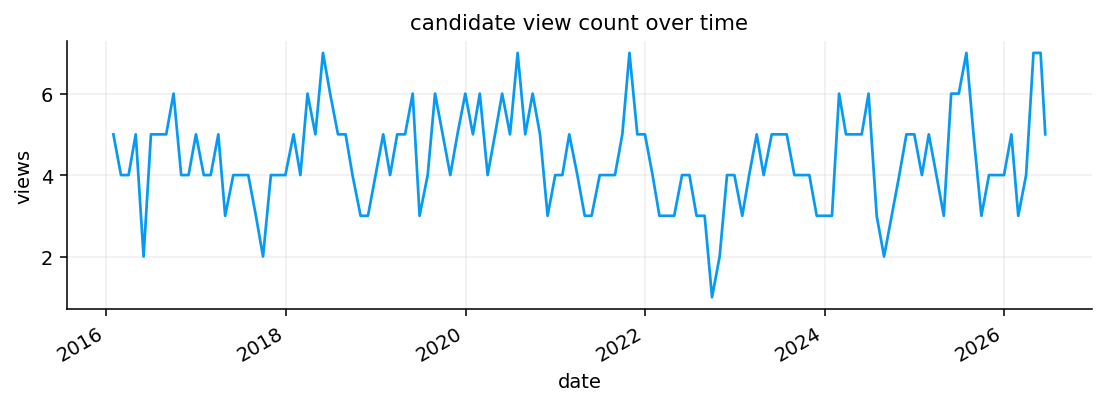

,active_count,avg_q_tilt,avg_abs_q_tilt,avg_signal_strength
view,,,,
Risk-adjusted momentum,126,0.0883,0.0883,1.8283
Dual momentum,119,0.0867,0.0867,1.7720
Duration quality,78,0.0334,0.0334,0.6185
Liquidity leadership,52,0.0399,0.0399,0.7446
International rotation,47,0.0656,0.0656,1.0208
Credit switch: risk-on,44,0.0356,0.0356,1.1821
Growth-duration barbell,29,0.0415,0.0415,0.7668
Reflation breadth,21,0.0754,0.0754,1.3170
Inflation rotation,20,0.0313,0.0313,0.9807


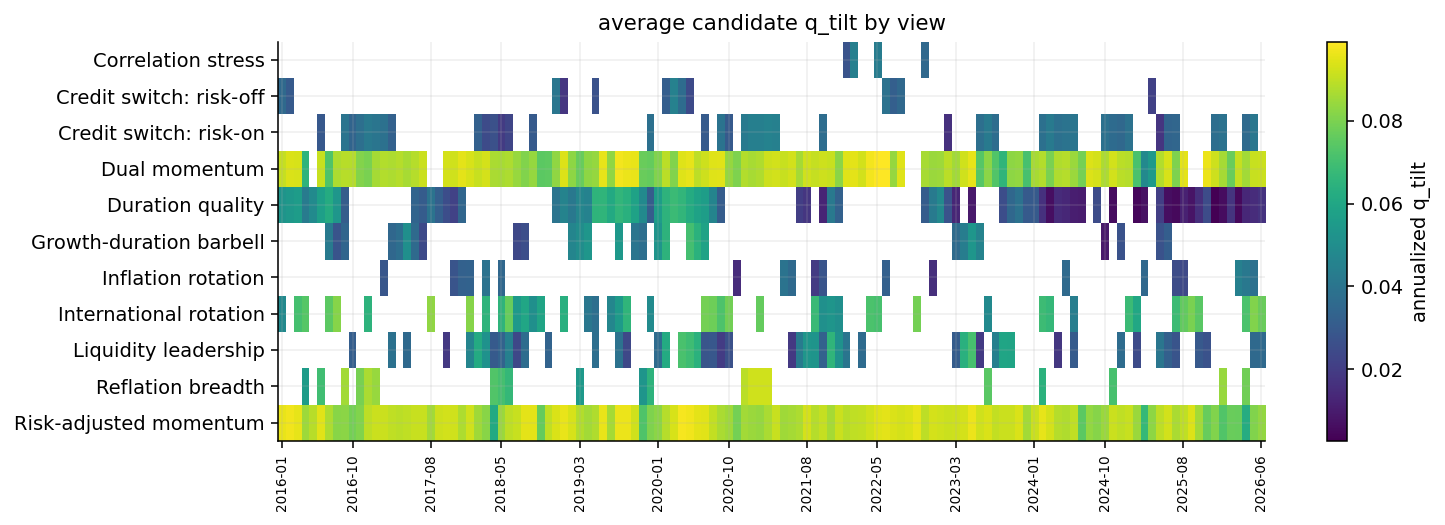

In [25]:
view_cache = {}
view_log_rows = []
for dt in rebalance_dates:
    dt = pd.Timestamp(dt)
    signal_table, market_state = compute_asset_signals(signal_close, signal_returns, dt,
                                                       dividends=dividends_all)
    cov_ann = cov_by_date[dt].loc[assets, assets]
    simple_views = make_simple_interpretable_views(signal_table, market_state, cov_ann=cov_ann)
    active_views = combine_and_rank_views(simple_views)
    view_cache[dt] = {"asset_signal_table": signal_table, "market_state": market_state,
                      "simple_views": simple_views, "active_views": active_views}
    for row in active_views:
        rec = dict(row)
        rec["date"] = dt
        view_log_rows.append(rec)
view_preview_log = pd.DataFrame(view_log_rows)
if not view_preview_log.empty:
    active_count_series = view_preview_log.groupby("date").size().reindex(rebalance_dates, fill_value=0)
else:
    active_count_series = pd.Series(0, index=rebalance_dates)
ax = active_count_series.plot(figsize=(8, 3), lw=1.4)
ax.set_title("candidate view count over time")
ax.set_ylabel("views")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()
latest_active_views = view_cache[pd.Timestamp(latest_rebalance_date)]["active_views"]
latest_active_table = pd.DataFrame(latest_active_views)
if not view_preview_log.empty:
    view_frequency = (view_preview_log.groupby("view")
                      .agg(active_count=("view", "size"), avg_q_tilt=("q_tilt", "mean"),
                           avg_abs_q_tilt=("q_tilt", lambda x: np.mean(np.abs(x))),
                           avg_signal_strength=("signal_value", lambda x: np.mean(np.abs(x))))
                      .sort_values("active_count", ascending=False))
    display(view_frequency.round(4))
    q_heatmap = view_preview_log.groupby(["view", "date"])["q_tilt"].mean().unstack().sort_index()
    fig, ax = plt.subplots(figsize=(11, max(3, 0.35 * len(q_heatmap))))
    im = ax.imshow(q_heatmap, aspect="auto", cmap="viridis")
    ax.set_title("average candidate q_tilt by view")
    ax.set_yticks(range(len(q_heatmap.index)), q_heatmap.index)
    tick_count = min(14, len(q_heatmap.columns))
    tick_pos = np.linspace(0, len(q_heatmap.columns) - 1, tick_count, dtype=int) if tick_count else []
    ax.set_xticks(tick_pos, [q_heatmap.columns[i].strftime("%Y-%m") for i in tick_pos],
                  rotation=90, fontsize=7)
    fig.colorbar(im, ax=ax, label="annualized q_tilt")
    plt.tight_layout()
    plt.show()


The candidate view count plot shows that the model usually has several views active, often around 4 to 6, but the count moves through time. This is good. If the count were always fixed, the view engine would be forcing views even when the market didn't support them. If the count were usually zero, the model would behave too much like the benchmark.

The view frequency table shows that **Risk-adjusted momentum** and **Dual momentum** dominate the candidate set. Risk-adjusted momentum fires **126** times with average q-tilt around **0.0883**. Dual momentum fires **119** times with average q-tilt around **0.0867**. These are the broadest and most persistent view families, so it makes sense that they appear often.

Duration quality fires **78** times, but with a smaller average tilt around **0.0334**. Liquidity leadership, international rotation, and credit-switch risk-on also fire frequently. Reflation breadth and inflation rotation are more regime-specific. Correlation stress only fires **4** times, which is exactly the kind of view that should stay rare.

The q-tilt heatmap shows clustering. Momentum views are active through most of the sample, while inflation and correlation views concentrate in specific regimes. That distinction is important for the learned-confidence system: frequent views get more statistical learning, rare views need stronger conservative caps.


## 9) View payoff history

This is the part that makes the project different from a standard Black-Litterman implementation.

Classical Black-Litterman asks the user to choose confidence manually. In practice, that is hard. Saying "I am 70% confident in this view" sounds precise, but it often has no statistical meaning. We instead measure how the view has actually performed whenever it fired in the past.

For each view at date $t$, we look forward $h=21$ trading days and compute the cumulative return of each asset:

$$
R_{i,t:t+h}=\prod_{s=t+1}^{t+h}(1+r_{i,s})-1
$$

Then the view payoff is the return of the long-short view portfolio:

$$
\text{payoff}_{k,t}=\mathbf{p}_{k,t}^\top\mathbf{R}_{t:t+h}
$$

If the view was long EEM and short EFA, the payoff is simply:

$$
\text{payoff}_{k,t}=R_{EEM,t:t+h}-R_{EFA,t:t+h}
$$

If the view was a basket, the payoff is the average return of the long basket minus the average return of the short basket.

For annualized payoff, we use the log-scaled horizon conversion:

$$
\text{payoff}^{ann}_{k,t}=\frac{252}{h}\log(1+\text{payoff}_{k,t})
$$

This puts payoff values on the same annual scale as $q$ and the posterior expected returns.

> A view earns a positive payoff when the long side beats the short side over the next month. That is the direct test of whether the view was useful.


### 9.1 Hit rate, payoff IR, t-stat, and information coefficient

Once we have payoff history, we summarize each view family.

The **hit rate** is the fraction of realized payoffs that were positive:

$$
H_k = \frac{1}{n_k}\sum_{j=1}^{n_k}\mathbf{1}\{\text{payoff}_{k,j}>0\}
$$

A hit rate above 50% means the view was directionally correct more often than it was wrong.

The **recent hit rate** uses only the latest six observations:

$$
H_{k,recent}=\frac{1}{m_k}\sum_{j=n_k-m_k+1}^{n_k}\mathbf{1}\{\text{payoff}_{k,j}>0\}
$$

with $m_k\leq 6$. This helps detect decay. A view can have a good long-run history but fail recently.

The **average payoff** is:

$$
\bar{x}_k = \frac{1}{n_k}\sum_{j=1}^{n_k}x_{k,j}
$$

where $x_{k,j}$ is the annualized view payoff.

The **payoff volatility** is:

$$
s_k = \sqrt{\frac{1}{n_k-1}\sum_{j=1}^{n_k}(x_{k,j}-\bar{x}_k)^2}
$$

The **payoff information ratio** is:

$$
IR_k=\frac{\bar{x}_k}{s_k}
$$

This is basically a Sharpe ratio for the view itself. It tells us how much average payoff the view produced per unit of payoff noise.

The **t-statistic** is:

$$
t_k = IR_k\sqrt{n_k}
$$

It rewards both consistency and sample size. A view with decent IR and many observations earns more trust than a view with decent IR from only a few observations.

The **information coefficient** checks whether stronger signal values actually lead to stronger future payoffs:

$$
IC_k = \text{Corr}(|s_{k,t}|, \text{payoff}_{k,t})
$$

This is useful because a view can have a decent hit rate, but if larger signal strength doesn't lead to larger payoff, the magnitude of $q$ is less trustworthy.


In [26]:
view_horizon_days = 21


def p_row_from_view(row, assets):
    return p_series_from_assets(row.get("long_assets", []), row.get("short_assets", []), list(assets))


def stress_state_from_market_state(market_state):
    spy_dd = state_value(market_state, "spy_drawdown_252", 0.0)
    spy_vol_z = state_value(market_state, "spy_vol_z", 0.0)
    breadth = state_value(market_state, "risky_trend_breadth")
    credit = state_value(market_state, "hyg_lqd_63", 0.0)
    return bool((np.isfinite(spy_dd) and spy_dd < -0.08) or spy_vol_z > 0.80
                or (np.isfinite(breadth) and breadth < 0.45) or credit < -0.020)


def build_view_payoff_history(view_log, returns, horizon=view_horizon_days):
    if view_log.empty:
        return pd.DataFrame()
    rows = []
    for _, row in view_log.iterrows():
        dt = pd.Timestamp(row["date"])
        pos = returns.index.searchsorted(dt, side="right") - 1
        if pos < 0 or pos + horizon >= len(returns.index):
            continue
        forward_asset_return = (1.0 + returns.iloc[pos + 1 : pos + horizon + 1]).prod() - 1.0
        p = p_row_from_view(row, returns.columns)
        if p is None:
            continue
        payoff_horizon = float(p @ forward_asset_return.reindex(p.index).fillna(0.0))
        payoff_ann = float(np.log1p(np.clip(payoff_horizon, -0.95, None)) * annualization / horizon)
        market_state_t = view_cache.get(dt, {}).get("market_state", {}) if "view_cache" in globals() else {}
        stress_state = stress_state_from_market_state(market_state_t) if market_state_t else False
        rows.append({
                "date": dt,
                "payoff_end_date": returns.index[pos + horizon],
                "view_id": row["view_id"],
                "view": row.get("view", row.get("view_id", "other")),
                "view_state": row.get("view_state", row.get("risk_orientation", "neutral")),
                "signal_value": row["signal_value"],
                "raw_strength": row.get("raw_strength", abs(row["signal_value"])),
                "signal_strength": abs(row["signal_value"]),
                "q_tilt": row.get("q_tilt", np.nan),
                "q": row.get("q", np.nan),
                "payoff_horizon": payoff_horizon,
                "payoff_ann": payoff_ann,
                "payoff": payoff_ann,
                "hit": payoff_horizon > 0,
                "risk_orientation": row["risk_orientation"],
                "spy_drawdown_252": market_state_t.get("spy_drawdown_252", np.nan),
                "spy_vol_z": market_state_t.get("spy_vol_z", np.nan),
                "risky_trend_breadth": market_state_t.get("risky_trend_breadth", np.nan),
                "hyg_lqd_63": market_state_t.get("hyg_lqd_63", np.nan),
                "stress_state": stress_state,
                "p_vector": p.round(6).to_dict(),
        })
    return pd.DataFrame(rows)


all_payoff_history = build_view_payoff_history(view_preview_log, returns[assets])

if not all_payoff_history.empty:
    view_payoff_stats = all_payoff_history.groupby("view").agg(
        observations=("payoff_ann", "size"),
        hit_rate=("hit", "mean"),
        recent_hit_rate=("hit", lambda x: x.tail(6).mean()),
        avg_payoff_ann=("payoff_ann", "mean"),
        payoff_vol=("payoff_ann", "std"),
        avg_q_tilt=("q_tilt", "mean"))
    payoff_vol = view_payoff_stats["payoff_vol"].replace(0.0, np.nan)
    view_payoff_stats["payoff_ir"] = view_payoff_stats["avg_payoff_ann"] / payoff_vol
    display(view_payoff_stats.sort_values("observations", ascending=False).round(4))


,observations,hit_rate,recent_hit_rate,avg_payoff_ann,payoff_vol,avg_q_tilt,payoff_ir
view,,,,,,,
Risk-adjusted momentum,124,0.5726,0.6667,0.0376,0.4215,0.0884,0.0893
Dual momentum,117,0.5726,1.0000,0.0478,0.4323,0.0867,0.1106
Duration quality,76,0.3553,0.3333,-0.0344,0.3200,0.0338,-0.1073
Liquidity leadership,50,0.6200,0.5000,0.0533,0.4112,0.0401,0.1297
International rotation,45,0.4444,0.5000,-0.0562,0.3637,0.0651,-0.1546
Credit switch: risk-on,43,0.6512,0.8333,0.1504,0.4029,0.0355,0.3733
Growth-duration barbell,29,0.4138,0.1667,0.0746,0.4565,0.0415,0.1633
Reflation breadth,21,0.7143,0.3333,0.1328,0.3402,0.0754,0.3905
Inflation rotation,19,0.4737,0.5000,-0.0667,0.5422,0.0310,-0.1229


The payoff history table is one of the most important outputs in the project.

The best broad evidence comes from **Dual momentum** and **Risk-adjusted momentum**. Dual momentum has **117 observations**, hit rate around **57.26%**, recent hit rate **100%**, average annualized payoff around **4.78%**, and payoff IR around **0.1106**. Risk-adjusted momentum has **124 observations**, hit rate around **57.26%**, recent hit rate **66.67%**, and payoff IR around **0.0893**. These aren't huge IR values, but for noisy monthly cross-asset views, they are meaningful enough to deserve moderate confidence.

**Credit switch: risk-on** has a strong profile: hit rate around **65.12%**, average payoff around **15.04%**, and payoff IR around **0.3733**. This suggests that when credit confirms a risk-on environment, the view has historically been useful.

**Reflation breadth** also looks strong, with hit rate around **71.43%** and payoff IR around **0.3905**, but it has only **21 observations**. This is useful but less statistically mature than momentum.

Some views are weak. **Duration quality** has hit rate around **35.53%** and negative payoff IR. **International rotation** has hit rate around **44.44%** and negative payoff IR. **Credit switch: risk-off** has very poor hit rate around **23.08%**. These views can still be selected if current signals support them, but learned confidence needs to shrink them.

Correlation stress has excellent-looking numbers, with hit rate **75%** and payoff IR **0.5361**, but only **4 observations**. We shouldn't give it high confidence just because the few examples worked. The sample is too small.


## 10) Learned confidence

Now we convert payoff statistics into a confidence number. Confidence is bounded between 0.30 and 0.90:

$$
0.30 \leq \omega_k \leq 0.90
$$

Here $\omega_k$ is not the same as the Black-Litterman uncertainty matrix $\Omega$. It is a human-readable confidence score. Later we convert it into $\Omega$.

The learned confidence formula starts from a skeptical baseline:

$$
\omega_k^{base}=0.40
$$

Then it adds evidence from t-stat, payoff IR, information coefficient, hit rate, sample size, and confluence:

$$
\omega_k = 0.40 + 0.14\tanh\left(\frac{t_k}{2}\right)+0.12\tanh(2IR_k)+0.08\tanh(2IC_k)
$$

$$
\omega_k \leftarrow \omega_k + 0.18\cdot2(H_k-0.50)+0.05\cdot\text{sample\_score}_k+0.05\cdot\text{confluence}_k
$$

The sample score is:

$$
\text{sample\_score}_k=\text{clip}\left(\frac{n_k-4}{20},0,1\right)
$$

So views with tiny sample size get almost no sample-size bonus, while views with enough history get the full bonus.

The nonlinear $\tanh$ terms are important. They prevent a single statistic from exploding confidence. A very high t-stat helps, but it saturates. A very bad IR hurts, but it also saturates. This keeps confidence in a controlled range.

We also apply safety rules:

- if $n_k<8$, confidence is capped at **0.52**,
- if payoff IR is weak and hit rate is weak, confidence is capped at **0.46**,
- if recent hit rate is below **35%**, confidence is penalized,
- risk-on views are penalized slightly during equity stress,
- protective views need stress-period evidence to earn high stress confidence.

This is a major improvement over manually chosen confidence because the model has to earn trust from actual realized payoffs.


In [27]:
conf_floor = 0.30
conf_cap = 0.90
protective_views = {"correlation_stress"}


def view_reliability_stats(view_id, payoff_history, current_date):
    current_date = pd.Timestamp(current_date)
    if payoff_history is None or len(payoff_history) == 0:
        sample = pd.DataFrame()
    else:
        sample = payoff_history[(payoff_history["view_id"] == view_id)
                                & (payoff_history["date"] < current_date)
                                & (payoff_history["payoff_end_date"] < current_date)].sort_values("date")
    empty = {
        "n_obs": 0, "hit_rate": np.nan, "recent_hit_rate": np.nan, "avg_payoff": 0.0, "payoff_vol": np.nan, "payoff_ir": 0.0, "t_stat": 0.0,
        "info_coefficient": 0.0, "sign_stability": np.nan, "recent_decay": 0.0, "sample_score": 0.0, "stress_n_obs": 0,
        "stress_hit_rate": np.nan, "stress_avg_payoff": 0.0, "stress_payoff_ir": 0.0}
    if sample.empty:
        return empty
    payoff_col = "payoff_ann" if "payoff_ann" in sample.columns else "payoff"
    payoff = pd.to_numeric(sample[payoff_col], errors="coerce").dropna()
    n_obs = int(len(payoff))
    if n_obs == 0:
        return empty
    aligned = sample.loc[payoff.index]
    avg_payoff = float(payoff.mean())
    payoff_vol = float(payoff.std(ddof=1)) if n_obs > 1 else np.nan
    payoff_ir = avg_payoff / payoff_vol if np.isfinite(payoff_vol) and payoff_vol > 1e-10 else 0.0
    t_stat = payoff_ir * math.sqrt(n_obs) if n_obs > 1 else 0.0
    hit_rate = float((payoff > 0).mean())
    recent = payoff.tail(6)
    recent_hit_rate = float((recent > 0).mean()) if len(recent) else np.nan
    signal_strength = (pd.to_numeric(aligned.get("signal_strength", aligned["signal_value"].abs()), errors="coerce")
                       .reindex(payoff.index).fillna(0.0))
    info_coefficient = (float(signal_strength.corr(payoff)) if n_obs >= 8 and signal_strength.std(ddof=1) > 1e-10 and payoff.std(ddof=1) > 1e-10 else 0.0)
    if not np.isfinite(info_coefficient):
        info_coefficient = 0.0
    stress_n_obs, stress_hit_rate, stress_avg_payoff, stress_payoff_ir = 0, np.nan, 0.0, 0.0
    if view_id in protective_views and "stress_state" in aligned.columns:
        stress_mask = aligned["stress_state"].astype(bool).reindex(payoff.index).fillna(False)
        stress_payoff = payoff[stress_mask]
        stress_n_obs = int(len(stress_payoff))
        if stress_n_obs:
            stress_avg_payoff = float(stress_payoff.mean())
            stress_hit_rate = float((stress_payoff > 0).mean())
            stress_vol = float(stress_payoff.std(ddof=1)) if stress_n_obs > 1 else np.nan
            stress_payoff_ir = (stress_avg_payoff / stress_vol
                                if np.isfinite(stress_vol) and stress_vol > 1e-10 else 0.0)
    return {
        "n_obs": n_obs, "hit_rate": hit_rate, "recent_hit_rate": recent_hit_rate,
        "avg_payoff": avg_payoff, "payoff_vol": payoff_vol, "payoff_ir": payoff_ir,
        "t_stat": t_stat, "info_coefficient": info_coefficient,
        "sign_stability": hit_rate, "recent_decay": float(recent.mean() - avg_payoff) if len(recent) else 0.0,
        "sample_score": float(np.clip((n_obs - 4) / 20.0, 0.0, 1.0)),
        "stress_n_obs": stress_n_obs, "stress_hit_rate": stress_hit_rate,
        "stress_avg_payoff": stress_avg_payoff, "stress_payoff_ir": stress_payoff_ir}


def confidence_from_stats(stats, row, market_state, confidence_mode):
    n_obs = stats["n_obs"]
    hit_rate = stats["hit_rate"] if np.isfinite(stats["hit_rate"]) else 0.50
    recent_hit_rate = stats["recent_hit_rate"] if np.isfinite(stats["recent_hit_rate"]) else hit_rate
    payoff_ir = stats["payoff_ir"] if np.isfinite(stats["payoff_ir"]) else 0.0
    t_stat = stats["t_stat"] if np.isfinite(stats["t_stat"]) else 0.0
    info_coefficient = stats["info_coefficient"] if np.isfinite(stats["info_coefficient"]) else 0.0
    confidence = (0.40 + 0.14 * math.tanh(t_stat / 2.0) + 0.12 * math.tanh(2.0 * payoff_ir)
                  + 0.08 * math.tanh(2.0 * info_coefficient))
    confidence += (0.18 * (hit_rate - 0.50) * 2.0 + 0.05 * stats["sample_score"]
                   + 0.05 * float(row.get("confluence_score", 0.0)))
    if n_obs < 8:
        confidence = min(confidence, 0.52)
    if payoff_ir <= 0.03 and hit_rate <= 0.52 and n_obs >= 8:
        confidence = min(confidence, 0.46)
    if recent_hit_rate < 0.35 and n_obs >= 8:
        confidence = min(confidence - 0.08, 0.42)
    if row.get("view_id") in protective_views and stats.get("stress_n_obs", 0) >= 6:
        if stats.get("stress_hit_rate", 1.0) < 0.50 or stats.get("stress_payoff_ir", 1.0) <= 0.0:
            confidence = min(confidence, 0.40)
    if market_state.get("equity_stress", False) and row.get("risk_orientation") == "risk_on":
        confidence -= 0.03
    else:
        confidence = float(np.clip(confidence, conf_floor, conf_cap))
    out = dict(stats)
    out.update({"confidence": confidence, "confidence_mode": confidence_mode,
                "risk_orientation": row.get("risk_orientation", "neutral")})
    return out


def confidence_for_view(row, payoff_history, current_date, market_state, confidence_mode):
    return confidence_from_stats(view_reliability_stats(row["view_id"], payoff_history, current_date),
                                 row, market_state, confidence_mode)


latest_confidence_rows = []
for row in latest_active_views:
    details = confidence_for_view(row, all_payoff_history, latest_rebalance_date, latest_market_state, "learned")
    latest_confidence_rows.append({
        "view": row["view"],
        "view_state": row.get("view_state", row.get("risk_orientation", "neutral")),
        "confidence": details["confidence"],
        "n_obs": details["n_obs"],
        "hit_rate": details["hit_rate"],
        "recent_hit_rate": details["recent_hit_rate"],
        "payoff_ir": details["payoff_ir"],
        "t_stat": details["t_stat"],
        "info_coefficient": details["info_coefficient"],
        "risk_orientation": details["risk_orientation"]})
latest_confidence_table = pd.DataFrame(latest_confidence_rows)
if not latest_confidence_table.empty:
    display(latest_confidence_table.round(4))


,view,view_state,confidence,n_obs,hit_rate,recent_hit_rate,payoff_ir,t_stat,info_coefficient,risk_orientation
0,Risk-adjusted momentum,quality_momentum,0.5431,124,0.5726,0.6667,0.0893,0.9944,-0.3538,neutral
1,International rotation,em_leadership,0.3309,45,0.4444,0.5000,-0.1546,-1.0370,0.0104,risk_on
2,Dual momentum,trend_following,0.5857,117,0.5726,1.0000,0.1106,1.1960,-0.1111,neutral
3,Liquidity leadership,narrow_leadership,0.5802,50,0.6200,0.5000,0.1297,0.9173,0.0722,risk_on
4,Duration quality,short_duration_quality,0.3000,76,0.3553,0.3333,-0.1073,-0.9358,0.0247,risk_off


The latest confidence table shows learned confidence doing exactly what it is supposed to do.

**Dual momentum** has confidence around **0.5857**, the highest in the latest active set. It has 117 observations, hit rate **57.26%**, recent hit rate **100%**, and positive payoff IR. The model trusts it more because it has both a long history and good recent behavior.

**Liquidity leadership** also receives high confidence around **0.5802**, supported by hit rate **62%** and positive payoff IR. **Risk-adjusted momentum** gets confidence around **0.5431**, which is moderate and sensible: it has a good sample and positive hit rate, but the information coefficient is negative, so signal magnitude hasn't translated cleanly into larger payoffs.

**International rotation** is held down to **0.3309**. It has 45 observations, but hit rate is below 50% and payoff IR is negative. The model still allows the view to exist, but it won't let the view dominate the posterior.

**Duration quality** is floored at **0.3000** because its history is weak: hit rate around **35.53%**, recent hit rate **33.33%**, and negative payoff IR. That is a very important output. The view fires because the current state says short duration quality matters, but the learned confidence system says, "be careful, this view hasn't worked well historically."

This is the difference between a rule-based allocation system and learned-confidence BL. The rule creates the view. The payoff history controls how much the view is allowed to matter.


### 10.1 View selection and redundancy control

After computing confidence, we still need to select views. If too many overlapping views enter the posterior, the same economic bet can be counted multiple times.

Each candidate view gets a selected score:

$$
\text{score}_k = 0.25\cdot\text{historical\_confidence}_k + 0.25\cdot\text{payoff\_quality}_k + 0.20\cdot\text{confluence}_k
$$

$$
+0.15\cdot q\text{-score}_k + 0.10\cdot\text{priority}_k + 0.05\cdot\text{diversification}_k
$$

The $q$-score measures how large the raw tilt is relative to its cap:

$$
q\text{-score}_k = \frac{|q_{tilt,k}|}{c_k}
$$

The payoff-quality score combines hit rate, recent hit rate, payoff IR, and sample score. Confluence measures how many independent signal dimensions support the view.

Then we remove redundant views using cosine similarity between exposure vectors:

$$
\text{sim}(i,j)=\frac{\mathbf{p}_i^\top\mathbf{p}_j}{\lVert\mathbf{p}_i\rVert\lVert\mathbf{p}_j\rVert}
$$

If two views have similarity above **0.85**, we keep the stronger one. This matters because dual momentum and risk-adjusted momentum can sometimes point to almost the same long-short basket. Without redundancy control, the posterior would double-count the same bet.

We also cap selected views at 7 and limit too many same-direction views. That keeps the posterior from becoming a pile of correlated risk-on bets.


In [28]:
max_active_selected_views = 7
redundancy_similarity_threshold = 0.85
max_same_direction_views = 5


def novelty_score_for_view(row, payoff_history, current_date):
    if payoff_history is None or len(payoff_history) == 0:
        return 1.0
    current_date = pd.Timestamp(current_date)
    recent = payoff_history[(payoff_history["date"] < current_date)
                            & (payoff_history["date"] >= current_date - pd.DateOffset(months=12))]
    view_count = int((recent["view_id"] == row["view_id"]).sum()) if not recent.empty else 0
    return float(1.0 / (1.0 + view_count / 6.0))


def payoff_quality_from_stats(stats):
    n_obs = stats.get("n_obs", 0)
    if n_obs < 8:
        return 0.45
    hit_rate = stats.get("hit_rate", np.nan)
    recent_hit_rate = stats.get("recent_hit_rate", np.nan)
    payoff_ir = stats.get("payoff_ir", np.nan)
    sample_score = stats.get("sample_score", 0.0)
    hit_base = hit_rate if np.isfinite(hit_rate) else 0.50
    hit_component = np.clip((hit_base - 0.50) / 0.15, 0.0, 1.0)
    recent_base = recent_hit_rate if np.isfinite(recent_hit_rate) else hit_base
    recent_component = np.clip((recent_base - 0.50) / 0.20, 0.0, 1.0)
    ir_component = np.clip((payoff_ir if np.isfinite(payoff_ir) else 0.0) / 0.30, 0.0, 1.0)
    quality = 0.35 * hit_component + 0.25 * ir_component + 0.20 * recent_component + 0.20 * sample_score
    return float(np.clip(quality, 0.0, 1.0))


def view_exposure_vector(row):
    if isinstance(row.get("p_vector"), dict):
        return pd.Series(row.get("p_vector"), dtype=float).reindex(assets).fillna(0.0)
    p = p_series_from_assets(row.get("long_assets", []), row.get("short_assets", []), assets)
    return p if p is not None else pd.Series(0.0, index=assets)


def exposure_cosine_similarity(row_a, row_b):
    a = view_exposure_vector(row_a).values
    b = view_exposure_vector(row_b).values
    denom = float(np.linalg.norm(a) * np.linalg.norm(b))
    if denom <= 1e-12:
        return np.nan
    return float(a @ b / denom)


def select_selected_views(active_views, payoff_history, current_date, market_state, confidence_mode):
    evaluated = []
    for row in active_views:
        row = dict(row)
        row["view"] = row.get("view", row.get("view_id", "other"))
        details = confidence_for_view(row, payoff_history, current_date, market_state, confidence_mode)
        gate = None
        skip, reason = False, "eligible"
        cap = view_caps.get(row.get("view_id"), 0.020)
        if details["n_obs"] < 8:
            row["q_tilt"] = min(float(row.get("q_tilt", 0.0)), min(cap, 0.012))
        q_score = float(np.clip(abs(float(row.get("q_tilt", 0.0))) / cap, 0.0, 1.0)) if cap > 0 else 0.0
        confluence_score = float(np.clip(row.get("confluence_score", 0.0), 0.0, 1.0))
        historical_confidence = float(details["confidence"] if np.isfinite(details["confidence"]) else 0.50)
        payoff_quality = payoff_quality_from_stats(details)
        novelty_score = novelty_score_for_view(row, payoff_history, current_date)
        basket_size = len(row.get("long_assets", [])) + len(row.get("short_assets", []))
        basket_breadth = float(np.clip(basket_size / 8.0, 0.0, 1.0))
        diversification_bonus = float(np.clip(0.70 * basket_breadth + 0.30 * novelty_score, 0.0, 1.0))
        view_priority = float(np.clip(row.get("view_priority", row.get("priority", 0.0)), 0.0, 1.0))
        selected_score = (0.25 * historical_confidence + 0.25 * payoff_quality + 0.20 * confluence_score
                          + 0.15 * q_score + 0.10 * view_priority + 0.05 * diversification_bonus)
        row.update({
                "confidence": historical_confidence,
                "hit_rate": details["hit_rate"],
                "recent_hit_rate": details["recent_hit_rate"],
                "avg_payoff": details["avg_payoff"],
                "payoff_vol": details["payoff_vol"],
                "payoff_ir": details["payoff_ir"],
                "t_stat": details["t_stat"],
                "info_coefficient": details["info_coefficient"],
                "n_obs": details["n_obs"],
                "stress_n_obs": details.get("stress_n_obs", 0),
                "stress_hit_rate": details.get("stress_hit_rate", np.nan),
                "stress_payoff_ir": details.get("stress_payoff_ir", np.nan),
                "historical_confidence": historical_confidence,
                "q_score": q_score,
                "payoff_quality": payoff_quality,
                "novelty_score": novelty_score,
                "diversification_bonus": diversification_bonus,
                "selected_score": selected_score,
        })
        evaluated.append({"row": row, "skip": skip, "reason": reason, "redundancy_similarity": np.nan})

    selected = []
    eligible = [x for x in evaluated if not x["skip"]]
    for item in sorted(eligible, key=lambda x: x["row"]["selected_score"], reverse=True):
        row = item["row"]
        max_similarity, redundant = np.nan, False
        for kept in selected:
            similarity = exposure_cosine_similarity(row, kept)
            if np.isfinite(similarity):
                max_similarity = max(abs(similarity), max_similarity if np.isfinite(max_similarity) else 0.0)
                if abs(similarity) > redundancy_similarity_threshold:
                    redundant = True
        item["redundancy_similarity"] = max_similarity
        if redundant:
            item["skip"], item["reason"] = True, "redundancy gate: exposure cosine similarity"
            continue
        same_direction = sum(kept.get("risk_orientation") == row.get("risk_orientation")
                             and row.get("risk_orientation") in ["risk_on", "risk_off"] for kept in selected)
        if same_direction >= max_same_direction_views and row["selected_score"] < 0.78:
            item["skip"], item["reason"] = True, "direction crowding gate"
            continue
        if len(selected) >= max_active_selected_views:
            item["skip"], item["reason"] = True, "below top selected views"
            continue
        selected.append(row)

    selected_ids = {id(row) for row in selected}
    log_rows = []
    for item in evaluated:
        row = item["row"]
        kept = id(row) in selected_ids
        log_rows.append({
            "date": pd.Timestamp(current_date), "view_id": row["view_id"], "view": row.get("view", row["view_id"]),
            "view_state": row.get("view_state", row.get("risk_orientation", "neutral")), "kept": kept, "scale_reason": "kept" if kept else item["reason"],
            "confidence_mode": confidence_mode, "confidence": row.get("confidence", np.nan), "historical_confidence": row.get("historical_confidence", np.nan),
            "payoff_quality": row.get("payoff_quality", np.nan), "confluence_score": row.get("confluence_score", np.nan),
            "novelty_score": row.get("novelty_score", np.nan), "diversification_bonus": row.get("diversification_bonus", np.nan),
            "view_priority": row.get("view_priority", np.nan), "q_tilt": row.get("q_tilt", np.nan), "q_score": row.get("q_score", np.nan),
            "selected_score": row.get("selected_score", np.nan), "n_obs": row.get("n_obs", np.nan),
            "hit_rate": row.get("hit_rate", np.nan), "recent_hit_rate": row.get("recent_hit_rate", np.nan), "payoff_ir": row.get("payoff_ir", np.nan),
            "avg_payoff": row.get("avg_payoff", np.nan), "t_stat": row.get("t_stat", np.nan), "info_coefficient": row.get("info_coefficient", np.nan),
            "stress_n_obs": row.get("stress_n_obs", np.nan), "stress_hit_rate": row.get("stress_hit_rate", np.nan),
            "stress_payoff_ir": row.get("stress_payoff_ir", np.nan), "signal_value": row.get("signal_value", np.nan),
            "raw_strength": row.get("raw_strength", row.get("view_strength", np.nan)), "view_strength": row.get("view_strength", np.nan),
            "redundancy_similarity": item.get("redundancy_similarity", np.nan),
            "source": row.get("source", ""), "risk_orientation": row.get("risk_orientation", "neutral")})
    return selected, log_rows


latest_selected_views, latest_selection_rows = select_selected_views(
    latest_active_views, all_payoff_history, latest_rebalance_date, latest_market_state, "learned")
latest_selection_table = pd.DataFrame(latest_selection_rows)
if not latest_selection_table.empty:
    selection_cols = ["view", "view_state", "kept", "confidence", "selected_score", "q_tilt",
                      "hit_rate", "recent_hit_rate", "payoff_ir", "scale_reason"]
    display(latest_selection_table[selection_cols].round(4))

latest_selected_table = pd.DataFrame(latest_selected_views)
if not latest_selected_table.empty:
    selected_cols = ["view", "view_state", "long_assets", "short_assets", "confidence", "selected_score",
                     "q_tilt", "risk_orientation"]
    display(latest_selected_table[selected_cols].round(4))


,view,view_state,kept,confidence,selected_score,q_tilt,hit_rate,recent_hit_rate,payoff_ir,scale_reason
0,Risk-adjusted momentum,quality_momentum,True,0.5431,0.6742,0.0835,0.5726,0.6667,0.0893,kept
1,International rotation,em_leadership,True,0.3309,0.4651,0.0771,0.4444,0.5000,-0.1546,kept
2,Dual momentum,trend_following,True,0.5857,0.6703,0.0916,0.5726,1.0000,0.1106,kept
3,Liquidity leadership,narrow_leadership,True,0.5802,0.5355,0.0357,0.6200,0.5000,0.1297,kept
4,Duration quality,short_duration_quality,True,0.3000,0.2759,0.0168,0.3553,0.3333,-0.1073,kept


,view,view_state,long_assets,short_assets,confidence,selected_score,q_tilt,risk_orientation
0,Risk-adjusted momentum,quality_momentum,"[EEM, QQQ, IWM, DBC]","[GLD, TLT, IEF, VNQ]",0.5431,0.6742,0.0835,neutral
1,Dual momentum,trend_following,"[EEM, QQQ, DBC, VNQ]","[TLT, GLD]",0.5857,0.6703,0.0916,neutral
2,Liquidity leadership,narrow_leadership,"[QQQ, SPY]","[HYG, VNQ]",0.5802,0.5355,0.0357,risk_on
3,International rotation,em_leadership,[EEM],[EFA],0.3309,0.4651,0.0771,risk_on
4,Duration quality,short_duration_quality,"[SHY, AGG, IEF]",[TLT],0.3000,0.2759,0.0168,risk_off


From the latest selection table, all five candidate views are kept. The ranking is sensible:

1. Risk-adjusted momentum, selected score **0.6742**.
2. Dual momentum, selected score **0.6703**.
3. Liquidity leadership, selected score **0.5355**.
4. International rotation, selected score **0.4651**.
5. Duration quality, selected score **0.2759**.

Risk-adjusted momentum ranks slightly above dual momentum because its confluence and selection score are strong, even though dual momentum has higher confidence. Duration quality is clearly the weakest selected view, and the score reflects that.

The selected-view table also shows the long/short side of each final view. This is helpful because we can directly connect the model's active ideas to later posterior shifts:

- EEM and QQQ appear repeatedly on the long side.
- TLT appears repeatedly on the short side.
- GLD is short in the momentum views, but later the full posterior can still be affected by covariance interactions.
- International rotation directly pushes EEM above EFA, but with low confidence.

So the view set isn't just a black box. We can read the exact active bets before seeing the posterior.


## 11) Learned $q$ scaling and the view matrix

Confidence affects $\Omega$, but we also use payoff history to scale the active $q$ tilt itself. This is another important part that needs clear interpretation.

The raw view is:

$$
q_k^{raw}=\mathbf{p}_k^\top\boldsymbol{\pi}+q_{tilt,k}^{raw}
$$

But if a view has weak payoff history, we don't want to send the full raw tilt into the posterior. So we apply a reliability multiplier:

$$
q_{tilt,k}^{final}=m_k\cdot q_{tilt,k}^{raw}
$$

where $m_k$ is based on hit rate, recent hit rate, payoff IR, and sample size.

Examples of the logic:

- if hit rate is below 48%, shrink,
- if hit rate is above 58%, boost,
- if payoff IR is negative enough, shrink strongly,
- if recent hit rate is very weak, shrink,
- if recent hit rate is strong, boost,
- if there are fewer than 8 observations, start with only 60% of the tilt.

The multiplier is clipped:

$$
0.35 \leq m_k \leq 1.25
$$

The final view target is:

$$
q_k=\mathbf{p}_k^\top\boldsymbol{\pi}+q_{tilt,k}^{final}
$$

This means $q$ includes two pieces:

| Piece | Formula | Meaning |
|---|---|---|
| Prior spread | $\mathbf{p}_k^\top\boldsymbol{\pi}$ | what the benchmark-implied prior already believes |
| Final active tilt | $q_{tilt,k}^{final}$ | the reliability-scaled active forecast |
| View target | $q_k$ | the spread return the view sends to BL |

This separation is crucial. If the prior already strongly favors the long side, $q$ can be high even with a modest active tilt. If the prior favors the short side, the active tilt has to overcome that base spread.


In [29]:
def q_multiplier_from_stats(stats):
    n_obs = stats.get("n_obs", 0)
    hit_rate = stats.get("hit_rate", np.nan)
    recent_hit_rate = stats.get("recent_hit_rate", np.nan)
    payoff_ir = stats.get("payoff_ir", np.nan)

    if n_obs < 8:
        return 0.60

    mult = 1.00
    if np.isfinite(hit_rate):
        if hit_rate < 0.48:
            mult *= 0.60
        elif hit_rate < 0.52:
            mult *= 0.80
        elif hit_rate > 0.58:
            mult *= 1.10
    if np.isfinite(payoff_ir):
        if payoff_ir < -0.10:
            mult *= 0.50
        elif payoff_ir <= 0.03:
            mult *= 0.75
        elif payoff_ir > 0.20:
            mult *= 1.15
    if np.isfinite(recent_hit_rate):
        if recent_hit_rate < 0.35:
            mult *= 0.75
        elif recent_hit_rate > 0.65:
            mult *= 1.10
    return float(np.clip(mult, 0.35, 1.25))


def learned_q_for_row(row, raw_q, payoff_history, current_date, use_learned_q=True):
    cap = view_caps.get(row.get("view_id"), 0.020)
    stats = (view_reliability_stats(row.get("view_id"), payoff_history, current_date)
             if current_date is not None
             else view_reliability_stats(row.get("view_id"), pd.DataFrame(), pd.Timestamp("1900-01-01")))
    raw_q = float(np.clip(abs(raw_q), 0.0, cap))
    learned_component = 0.0
    q_final = raw_q
    q_model = "rule q only"
    if use_learned_q:
        mult = q_multiplier_from_stats(stats)
        q_final = float(np.clip(raw_q * mult, 0.0, cap))
        learned_component = q_final - raw_q
        q_model = "soft reliability scaled q"
    q_shrinkage_or_boost = (q_final / raw_q - 1.0) if raw_q > 1e-12 else np.nan
    return q_final, learned_component, q_shrinkage_or_boost, q_model, stats


def build_view_matrix(active_views, assets, prior_mu=None, payoff_history=None,
                      current_date=None, use_learned_q=True):
    clean_rows, view_p_rows, view_q_vals = [], [], []
    asset_index = {asset: i for i, asset in enumerate(assets)}
    prior = (pd.Series(prior_mu, index=assets, dtype=float).reindex(assets).fillna(0.0)
             if prior_mu is not None else pd.Series(0.0, index=assets))
    for row in active_views:
        long_assets = [x for x in row.get("long_assets", []) if x in asset_index]
        short_assets = [x for x in row.get("short_assets", []) if x in asset_index]
        if not long_assets or not short_assets:
            continue
        p_row = np.zeros(len(assets), dtype=float)
        for asset in long_assets:
            p_row[asset_index[asset]] += 1.0 / len(long_assets)
        for asset in short_assets:
            p_row[asset_index[asset]] -= 1.0 / len(short_assets)
        tilt_cap = view_caps.get(row.get("view_id"), 0.020)
        view_strength = float(abs(row.get("view_strength", row.get("signal_value", 0.0))))
        raw_q_tilt = float(np.clip(abs(row.get("q_tilt", tilt_cap * math.tanh(view_strength / q_strength_scale))),
                                   0.0, tilt_cap))
        q_tilt_final, learned_q_component, q_shrinkage_or_boost, q_model, stats = learned_q_for_row(
            row, raw_q_tilt, payoff_history, current_date, use_learned_q=use_learned_q)
        if use_learned_q and q_tilt_final <= 1e-10:
            continue
        base_view_spread = float(p_row @ prior.values)
        q_val = base_view_spread + q_tilt_final
        rec = dict(row)
        rec["view"] = rec.get("view", rec.get("view_id", "other"))
        rec["base_view_spread"] = base_view_spread
        rec["raw_q"] = raw_q_tilt
        rec["raw_q_tilt"] = raw_q_tilt
        rec["learned_q_component"] = learned_q_component
        rec["final_q"] = q_tilt_final
        rec["q_tilt"] = q_tilt_final
        rec["q_tilt_final"] = q_tilt_final
        rec["q"] = q_val
        rec["q_model"] = q_model
        rec["q_shrinkage_or_boost"] = q_shrinkage_or_boost
        rec["q_shrink"] = raw_q_tilt - q_tilt_final
        rec["q_n_obs"] = stats.get("n_obs", np.nan)
        rec["q_hit_rate"] = stats.get("hit_rate", np.nan)
        rec["q_recent_hit_rate"] = stats.get("recent_hit_rate", np.nan)
        rec["q_payoff_ir"] = stats.get("payoff_ir", np.nan)
        rec["q_avg_payoff"] = stats.get("avg_payoff", np.nan)
        rec["q_t_stat"] = stats.get("t_stat", np.nan)
        rec["q_info_coefficient"] = stats.get("info_coefficient", np.nan)
        rec["p_vector"] = pd.Series(p_row, index=assets).round(6).to_dict()
        clean_rows.append(rec)
        view_p_rows.append(p_row)
        view_q_vals.append(q_val)
    view_p = np.vstack(view_p_rows) if view_p_rows else np.empty((0, len(assets)))
    view_q = np.asarray(view_q_vals, dtype=float)
    clean_view_table = pd.DataFrame(clean_rows)
    assert view_p.shape[1] == len(assets)
    return view_p, view_q, clean_view_table


latest_prior_mu = prior_mu_by_date[pd.Timestamp(latest_rebalance_date)].reindex(assets)
if not all_payoff_history.empty:
    latest_payoff_history = all_payoff_history[
        all_payoff_history["payoff_end_date"] < pd.Timestamp(latest_rebalance_date)].copy()
else:
    latest_payoff_history = pd.DataFrame()

latest_view_p, latest_view_q, latest_clean_view_table = build_view_matrix(
    latest_selected_views, assets, latest_prior_mu, payoff_history=latest_payoff_history,
    current_date=latest_rebalance_date, use_learned_q=True)

if not latest_clean_view_table.empty:
    q_cols = ["view", "view_state", "base_view_spread", "raw_q", "learned_q_component", "final_q",
              "q", "q_shrinkage_or_boost", "q_hit_rate", "q_recent_hit_rate", "q_payoff_ir"]
    display(latest_clean_view_table[q_cols].round(4))
    latest_p_table = pd.DataFrame(latest_view_p, columns=assets, index=latest_clean_view_table["view"])
    display(latest_p_table.round(3))


,view,view_state,base_view_spread,raw_q,learned_q_component,final_q,q,q_shrinkage_or_boost,q_hit_rate,q_recent_hit_rate,q_payoff_ir
0,Risk-adjusted momentum,quality_momentum,0.0674,0.0835,0.0083,0.0918,0.1592,0.1000,0.5726,0.6667,0.0893
1,Dual momentum,trend_following,-0.0103,0.0916,0.0084,0.1000,0.0897,0.0921,0.5726,1.0000,0.1106
2,Liquidity leadership,narrow_leadership,0.1270,0.0357,0.0036,0.0393,0.1663,0.1000,0.6200,0.5000,0.1297
3,International rotation,em_leadership,0.1123,0.0771,-0.0501,0.0270,0.1393,-0.6500,0.4444,0.5000,-0.1546
4,Duration quality,short_duration_quality,-0.0246,0.0168,-0.0109,0.0059,-0.0187,-0.6500,0.3553,0.3333,-0.1073


,SPY,QQQ,IWM,EFA,EEM,TLT,IEF,SHY,AGG,LQD,HYG,GLD,VNQ,DBC
view,,,,,,,,,,,,,,
Risk-adjusted momentum,0.0,0.25,0.25,0.0,0.25,-0.25,-0.250,0.000,0.000,0.0,0.0,-0.25,-0.25,0.25
Dual momentum,0.0,0.25,0.00,0.0,0.25,-0.50,0.000,0.000,0.000,0.0,0.0,-0.50,0.25,0.25
Liquidity leadership,0.5,0.50,0.00,0.0,0.00,0.00,0.000,0.000,0.000,0.0,-0.5,0.00,-0.50,0.00
International rotation,0.0,0.00,0.00,-1.0,1.00,0.00,0.000,0.000,0.000,0.0,0.0,0.00,0.00,0.00
Duration quality,0.0,0.00,0.00,0.0,0.00,-1.00,0.333,0.333,0.333,0.0,0.0,0.00,0.00,0.00


The learned $q$ table shows the mechanism clearly.

Risk-adjusted momentum has base view spread about **0.0674**, raw q tilt **0.0835**, and a positive learned component **0.0083**, giving final q tilt **0.0918**. Its final view target $q$ is **0.1592**. The model is saying: the prior already likes this spread, and the view history supports a small boost.

Dual momentum is even more interesting. Its base spread is slightly negative at about **-0.0103**, but the raw tilt is **0.0916**, boosted to the cap at **0.1000**. The final target $q$ becomes **0.0897**. This means the active view fully overcomes the prior's slight disagreement.

Liquidity leadership has base spread **0.1270** and final active tilt **0.0393**, producing $q$ around **0.1663**. The prior and view agree.

International rotation has base spread **0.1123**, but the learned component is negative **-0.0501**, shrinking final active tilt from **0.0771** to **0.0270**. So even though EEM looks strong now, its historical payoff record forces a much smaller active push.

Duration quality is also heavily shrunk. Raw q tilt **0.0168** becomes only **0.0059** because hit rate and payoff IR are weak. This is exactly the behavior we want.

The view matrix output confirms the portfolio exposures. For example, international rotation is simply $+1$ EEM and $-1$ EFA. Duration quality is $+1/3$ SHY, $+1/3$ AGG, $+1/3$ IEF, and $-1$ TLT. This matrix is what lets BL translate relative views into asset-level posterior return shifts.


## 12) From confidence to $\Omega$

Now we convert confidence into the Black-Litterman view uncertainty matrix $\Omega$.

In the view equation:

$$
P\boldsymbol{\mu}=\mathbf{q}+\boldsymbol{\varepsilon}
$$

$\boldsymbol{\varepsilon}$ is the view error term:

$$
\boldsymbol{\varepsilon}\sim\mathcal{N}(0,\Omega)
$$

So $\Omega$ controls how noisy the views are. Small $\Omega_{kk}$ means view $k$ is trusted. Large $\Omega_{kk}$ means view $k$ is noisy and the posterior won't move much toward it.

We first compute the covariance of the view portfolios:

$$
\Sigma_P = P\Sigma P^\top
$$

The diagonal element is the variance of the long-short view portfolio:

$$
(\Sigma_P)_{kk}=\mathbf{p}_k^\top\Sigma\mathbf{p}_k
$$

Then confidence enters through a scaling factor:

$$
s_k=\sqrt{\frac{1-\omega_k}{\omega_k}}
$$

where $\omega_k$ is the learned confidence score. Low confidence gives a larger $s_k$. High confidence gives a smaller $s_k$.

The view uncertainty matrix is:

$$
\Omega = \tau \cdot \text{diag}(\mathbf{s})\,(P\Sigma P^\top)\,\text{diag}(\mathbf{s})
$$

This construction is better than assigning arbitrary diagonal numbers because it respects both sources of uncertainty:

1. the market covariance of the view portfolio,
2. the learned reliability of the view family.

A high-volatility long-short view naturally has more uncertainty. A low-confidence view gets even more uncertainty.


In [30]:
tau = 0.05
use_empirical_omega_rescale = False


def empirical_view_variance(view_id, payoff_history, current_date):
    if payoff_history is None or len(payoff_history) == 0:
        return np.nan, 0
    sample = payoff_history[(payoff_history["view_id"] == view_id)
                            & (payoff_history["payoff_end_date"] < pd.Timestamp(current_date))].copy()
    payoff_col = "payoff_ann" if "payoff_ann" in sample.columns else "payoff"
    x = pd.to_numeric(sample.get(payoff_col, pd.Series(dtype=float)), errors="coerce").dropna()
    if len(x) < 8:
        return np.nan, int(len(x))
    return float(x.var(ddof=1)), int(len(x))


def omega_from_confidence(view_p, cov_ann, confidence, active_view_rows=None, payoff_history=None,
                          current_date=None, full_view_cov=True):
    if len(confidence) == 0 or view_p.shape[0] == 0:
        return np.empty((0, 0)), np.array([])
    conf = np.asarray(confidence, dtype=float)
    conf = np.where(np.isfinite(conf), conf, 0.50)
    conf = np.maximum(conf, 1e-4)
    cov_arr = np.asarray(cov_ann, dtype=float)
    view_cov = view_p @ cov_arr @ view_p.T
    view_cov = 0.5 * (view_cov + view_cov.T)
    view_var = np.maximum(np.diag(view_cov), 1e-8)
    scale = np.sqrt((1.0 - conf) / conf)
    base_omega = tau * np.diag(scale) @ view_cov @ np.diag(scale)
    base_omega = 0.5 * (base_omega + base_omega.T) + np.eye(len(conf)) * 1e-8
    base_diag = np.maximum(np.diag(base_omega), 1e-10)
    target_diag = base_diag.copy()
    if (use_empirical_omega_rescale and active_view_rows is not None
            and payoff_history is not None and current_date is not None):
        for i, row in enumerate(active_view_rows):
            emp_var, n_obs = empirical_view_variance(row.get("view_id"), payoff_history, current_date)
            if np.isfinite(emp_var) and emp_var > 1e-10:
                sample_weight = min(0.50, n_obs / 48.0)
                target_diag[i] = (1.0 - sample_weight) * base_diag[i] + sample_weight * emp_var
    try:
        rescale = np.sqrt(np.maximum(target_diag, 1e-10) / base_diag)
        omega = np.diag(rescale) @ base_omega @ np.diag(rescale)
        omega = 0.5 * (omega + omega.T) + np.eye(len(conf)) * 1e-8
        if np.all(np.isfinite(omega)):
            return omega, view_var
    except Exception:
        pass
    return np.diag(np.maximum(target_diag, 1e-8)), view_var


if latest_view_p.shape[0] > 0:
    latest_view_rows = latest_clean_view_table.to_dict("records")
    learned_conf = [confidence_for_view(row, all_payoff_history, latest_rebalance_date,
                                        latest_market_state, "learned")["confidence"]
                    for row in latest_view_rows]
    latest_omega, latest_view_var = omega_from_confidence(
        latest_view_p, latest_cov_ann, learned_conf, active_view_rows=latest_view_rows,
        payoff_history=all_payoff_history, current_date=latest_rebalance_date)
    omega_table = latest_clean_view_table[["view", "raw_q", "learned_q_component", "final_q", "q"]].copy()
    omega_table["confidence"] = learned_conf
    omega_table["view_variance"] = latest_view_var
    omega_table["omega_diag"] = np.diag(latest_omega)
    display(omega_table.round(6))
else:
    learned_conf = []
    latest_omega, latest_view_var = np.empty((0, 0)), np.array([])


,view,raw_q,learned_q_component,final_q,q,confidence,view_variance,omega_diag
0,Risk-adjusted momentum,0.083459,0.008346,0.091805,0.159161,0.543064,0.022687,0.000954
1,Dual momentum,0.091570,0.008430,0.100000,0.089734,0.585711,0.016410,0.000580
2,Liquidity leadership,0.035707,0.003571,0.039277,0.166276,0.580188,0.036126,0.001307
3,International rotation,0.077081,-0.050102,0.026978,0.139307,0.330930,0.039680,0.004011
4,Duration quality,0.016801,-0.010921,0.005880,-0.018717,0.300000,0.003956,0.000462


The latest $\Omega$ diagnostic table shows how this works in practice.

Dual momentum has confidence **0.5857** and view variance about **0.0164**, giving omega diagonal around **0.000580**. This is relatively small, so the view receives meaningful weight in the posterior.

Risk-adjusted momentum has confidence **0.5431** and view variance **0.0227**, giving omega diagonal around **0.000954**. Even though confidence is moderate, the view portfolio variance is larger, so uncertainty is larger than dual momentum.

Liquidity leadership has similar confidence **0.5802**, but view variance is higher at **0.0361**, so omega diagonal rises to about **0.001307**. This is the covariance structure speaking: the view is more volatile, so it gets more view uncertainty.

International rotation has low confidence **0.3309** and high view variance **0.0397**, producing omega diagonal around **0.004011**, the largest in the active set. So even though the current EEM signal is strong, the posterior will treat this view cautiously.

Duration quality has the lowest confidence **0.3000**, but the view variance is tiny at **0.0040**, so omega diagonal is only **0.000462**. This is a subtle point: low confidence increases uncertainty, but the underlying long-short portfolio is much less volatile, so the final $\Omega$ isn't huge. BL combines both effects.


## 13) Black-Litterman posterior

We now have all inputs:

- prior mean $\boldsymbol{\pi}$,
- prior covariance scale $\tau\Sigma$,
- view matrix $P$,
- view target vector $\mathbf{q}$,
- view uncertainty matrix $\Omega$.

The prior is Gaussian:

$$
\boldsymbol{\mu}\sim\mathcal{N}(\boldsymbol{\pi},\tau\Sigma)
$$

The views are Gaussian observations of $P\boldsymbol{\mu}$:

$$
P\boldsymbol{\mu}=\mathbf{q}+\boldsymbol{\varepsilon}, \qquad \boldsymbol{\varepsilon}\sim\mathcal{N}(0,\Omega)
$$

The posterior mean can be written in precision form:

$$
\boldsymbol{\mu}_{post}=\left[(\tau\Sigma)^{-1}+P^\top\Omega^{-1}P\right]^{-1}\left[(\tau\Sigma)^{-1}\boldsymbol{\pi}+P^\top\Omega^{-1}\mathbf{q}\right]
$$

This form is useful because it shows the weighted average logic. The posterior is a precision-weighted combination of the prior and the views. More precise prior, larger prior influence. More precise views, larger view influence.

The same posterior can be written in update form:

$$
\boldsymbol{\mu}_{post}=\boldsymbol{\pi}+\tau\Sigma P^\top(P\tau\Sigma P^\top+\Omega)^{-1}(\mathbf{q}-P\boldsymbol{\pi})
$$

The term:

$$
\mathbf{q}-P\boldsymbol{\pi}
$$

is the **view gap**. It is the difference between what the view says and what the prior already implies. If the view agrees with the prior, the gap is zero and the posterior doesn't move.

The matrix:

$$
K=\tau\Sigma P^\top(P\tau\Sigma P^\top+\Omega)^{-1}
$$

acts like a Kalman gain. It decides how much the view gap gets transmitted into each asset's expected return.

So the posterior shift is:

$$
\boldsymbol{\mu}_{post}-\boldsymbol{\pi}=K(\mathbf{q}-P\boldsymbol{\pi})
$$

This equation explains the whole model. Views don't directly become weights. They first become posterior return shifts, and those shifts depend on prior uncertainty, view covariance, and learned confidence.


In [31]:
def black_litterman_posterior(prior_mu, cov_ann, view_p, view_q, omega, tau=tau):
    prior_mu = pd.Series(prior_mu).astype(float)
    cov_ann = pd.DataFrame(cov_ann, index=prior_mu.index, columns=prior_mu.index).astype(float)
    diag = {
        "n_views": int(view_p.shape[0]),
        "avg_confidence": np.nan,
        "max_confidence": np.nan,
        "min_confidence": np.nan,
        "max_abs_q": float(np.max(np.abs(view_q))) if len(view_q) else 0.0,
        "max_abs_posterior_shift": 0.0,
        "condition_number": np.nan,
        "no_views": view_p.shape[0] == 0,
        "failure": False,
        "clipped": False,
    }
    if view_p.shape[0] == 0:
        return prior_mu.copy(), cov_ann.copy(), diag
    try:
        cov_arr = make_psd_df(cov_ann.values, cov_ann.index).values
        tau_cov = tau * cov_arr
        omega_arr = np.asarray(omega, dtype=float)
        omega_arr = 0.5 * (omega_arr + omega_arr.T) + np.eye(view_p.shape[0]) * 1e-8
        middle = view_p @ tau_cov @ view_p.T + omega_arr
        middle = 0.5 * (middle + middle.T) + np.eye(view_p.shape[0]) * 1e-10
        view_gap = view_q - view_p @ prior_mu.values
        diag["condition_number"] = float(np.linalg.cond(middle))
        solved_gap = np.linalg.solve(middle, view_gap)
        post_mu_arr = prior_mu.values + tau_cov @ view_p.T @ solved_gap
        solved_cov = np.linalg.solve(middle, view_p @ tau_cov)
        posterior_uncertainty = tau_cov - tau_cov @ view_p.T @ solved_cov
        post_cov_arr = make_psd(cov_arr + posterior_uncertainty)
        clipped = np.any((post_mu_arr < -0.30) | (post_mu_arr > 0.30))
        post_mu_arr = np.clip(post_mu_arr, -0.30, 0.30)
        post_mu = pd.Series(post_mu_arr, index=prior_mu.index)
        post_cov = pd.DataFrame(post_cov_arr, index=prior_mu.index, columns=prior_mu.index)
        diag["clipped"] = bool(clipped)
        diag["max_abs_posterior_shift"] = float(np.max(np.abs(post_mu.values - prior_mu.values)))
        return post_mu, post_cov, diag
    except Exception:
        diag["failure"] = True
        return prior_mu.copy(), cov_ann.copy(), diag


if latest_view_p.shape[0] > 0:
    post_mu_sample, post_cov_sample, post_diag_sample = black_litterman_posterior(
        latest_prior_mu, latest_cov_ann, latest_view_p, latest_view_q, latest_omega)
else:
    post_mu_sample, post_cov_sample, post_diag_sample = black_litterman_posterior(
        latest_prior_mu, latest_cov_ann, latest_view_p, latest_view_q, np.empty((0, 0)))
prior_post_table = pd.DataFrame({
    "asset": assets,
    "prior_mu": latest_prior_mu.reindex(assets).values,
    "post_mu": post_mu_sample.reindex(assets).values,
})
prior_post_table["shift"] = prior_post_table["post_mu"] - prior_post_table["prior_mu"]
prior_post_table = prior_post_table.sort_values("shift", ascending=False)
display(prior_post_table.round(4))


,asset,prior_mu,post_mu,shift
13,DBC,-0.0516,-0.0061,0.0455
1,QQQ,0.2056,0.2445,0.0389
2,IWM,0.1822,0.2087,0.0265
4,EEM,0.2775,0.3000,0.0225
0,SPY,0.1337,0.1478,0.0141
3,EFA,0.1652,0.1703,0.0051
10,HYG,0.0376,0.0385,0.0009
7,SHY,0.0111,0.0089,-0.0022
9,LQD,0.0425,0.0397,-0.0028
8,AGG,0.0318,0.0275,-0.0043


The latest posterior shift table shows the active views being translated into asset-level return changes.

DBC gets the largest positive shift in the first posterior diagnostic, about **+4.55%**, because it appears on the long side of both momentum views and starts from a negative prior. QQQ gets **+3.89%**, IWM gets **+2.65%**, EEM gets **+2.25%**, and SPY gets **+1.41%**. These shifts match the latest risk-on and momentum signals.

GLD receives the largest negative shift, about **-6.50%**, because it is short in the momentum views and its recent trend is weak. VNQ also gets a negative shift around **-1.91%** in that diagnostic because risk-adjusted momentum shorts it, even though dual momentum longs it. This is a good example of views partially conflicting and the posterior averaging them through $P$, $q$, and $\Omega$.

TLT, IEF, AGG, and LQD receive small negative shifts. That aligns with duration quality and weak fixed-income signals, but the shifts are not extreme because some bond exposures remain part of the benchmark and the prior is still tight.

EEM is clipped at **0.3000** in some posterior outputs. That tells us the model has a return cap for numerical stability. Clipping is important because posterior expected returns can otherwise become too large for the optimizer.

The key interpretation: the posterior is coherent with the view set, but it is not simply copying the views. It is blending views with the equilibrium prior and covariance structure.


## 14) Portfolio optimization from the posterior

Once we have posterior expected returns and posterior covariance, we solve a constrained mean-variance problem:

$$
\max_{\mathbf{w}} \; \mathbf{w}^\top\boldsymbol{\mu}_{post,t}-\frac{\delta_t}{2}\mathbf{w}^\top\Sigma_{post,t}\mathbf{w}
$$

subject to:

$$
\sum_i w_i=1
$$

$$
w_i\geq 0
$$

$$
w_i\leq c_i
$$

$$
|w_i-w_{b,i}|\leq a
$$

where $a=0.15$ is the active weight limit.

We also keep sleeve constraints:

$$
l_g\leq\sum_{i\in g}w_i\leq u_g
$$

The active limit is very important. It stops the posterior from becoming an all-in allocation just because one view is strong. If QQQ receives a strong posterior shift, the optimizer can overweight it, but only within the active budget.

We also include practical fallbacks. If the strict optimizer fails, we relax the active limit, remove sleeve constraints, or fall back to a tracking-error style solution. If all else fails, we keep previous weights. The output later confirms that the final BL backtest has zero fallback count, so the optimization path is stable.


In [32]:
active_weight_limit = 0.15
active_weight_relaxed = 0.22
gamma_te = 3.0
active_te_target = 0.05


def clean_bl_weight_array(weights, index, previous=None):
    caps = asset_caps.reindex(index).fillna(w_max)
    if weights is None:
        arr = previous if previous is not None else benchmark_w.reindex(index).values
    else:
        arr = np.asarray(weights, dtype=float).reshape(-1)
    if len(arr) != len(index) or not np.all(np.isfinite(arr)):
        if previous is not None:
            arr = np.asarray(previous, dtype=float).reshape(-1)
        else:
            arr = benchmark_w.reindex(index).fillna(0.0).values

    w = pd.Series(arr, index=index).clip(lower=w_min, upper=caps)
    if w.sum() <= 1e-12:
        w = benchmark_w.reindex(index).fillna(0.0).clip(upper=caps)
    w = w / w.sum()
    for _ in range(100):
        over = w > caps + 1e-12
        if not over.any():
            break
        extra = float((w[over] - caps[over]).sum())
        w[over] = caps[over]
        room = (caps[~over] - w[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        w.loc[room.index] += extra * room / room.sum()
    w = w.clip(lower=w_min, upper=caps)
    return (w / w.sum()).to_numpy(dtype=float)


def cvxpy_bl_optimizer(mu, cov_ann, w_prev=None, risk_aversion=None,
                       active_limit=active_weight_limit, use_sleeves=True, te_gamma=0.0):
    if cp is None:
        return None
    index = list(mu.index)
    n = len(index)
    w_var = cp.Variable(n)
    cov_arr = make_psd(cov_ann.values + np.eye(n) * 1e-8)
    caps = asset_caps.reindex(index).fillna(w_max).to_numpy(dtype=float)
    bench = benchmark_w.reindex(index).fillna(0.0).to_numpy(dtype=float)
    prev = np.asarray(w_prev if w_prev is not None else bench, dtype=float)
    risk_aversion = float(delta_fallback if risk_aversion is None or not np.isfinite(risk_aversion)
                           else risk_aversion)
    turnover_penalty = cost_bps / 10000.0 * cp.norm1(w_var - prev)
    te_penalty = te_gamma * cp.quad_form(w_var - bench, cov_arr) if te_gamma and te_gamma > 0 else 0.0
    objective = cp.Maximize(mu.values @ w_var - 0.5 * risk_aversion * cp.quad_form(w_var, cov_arr)
                            - turnover_penalty - te_penalty)
    constraints = [cp.sum(w_var) == 1.0, w_var >= w_min, w_var <= caps]
    if active_limit is not None:
        constraints += [w_var - bench <= active_limit, bench - w_var <= active_limit]
    if use_sleeves:
        for sleeve, spec in sleeve_constraints.items():
            locs = [index.index(asset) for asset in spec["assets"] if asset in index]
            if locs:
                sleeve_weight = cp.sum(w_var[locs])
                constraints += [sleeve_weight >= spec["min"], sleeve_weight <= spec["max"]]
    problem = cp.Problem(objective, constraints)
    for solver in ["CLARABEL", "OSQP", "ECOS", "SCS"]:
        try:
            problem.solve(solver=solver, verbose=False)
            if w_var.value is not None and problem.status in ["optimal", "optimal_inaccurate"]:
                return np.asarray(w_var.value, dtype=float)
        except Exception:
            continue
    return None


def optimize_bl_weights(post_mu, post_cov, w_prev=None, risk_aversion=None):
    attempts = [
        {"active_limit": active_weight_limit, "use_sleeves": True, "te_gamma": 0.0},
        {"active_limit": active_weight_relaxed, "use_sleeves": True, "te_gamma": 0.0},
        {"active_limit": active_weight_limit, "use_sleeves": False, "te_gamma": 0.0},
        {"active_limit": active_weight_relaxed, "use_sleeves": False, "te_gamma": 0.0},
        {"active_limit": None, "use_sleeves": False, "te_gamma": gamma_te},
    ]
    for attempt in attempts:
        w = cvxpy_bl_optimizer(post_mu, post_cov, w_prev=w_prev, risk_aversion=risk_aversion, **attempt)
        if w is not None:
            return clean_bl_weight_array(w, post_mu.index, previous=w_prev), False, attempt
    previous = w_prev if w_prev is not None else benchmark_w.reindex(post_mu.index).values
    return (clean_bl_weight_array(previous, post_mu.index, previous=previous), True,
            {"active_limit": None, "use_sleeves": False, "te_gamma": np.nan})


The full walk-forward loop repeats the complete Black-Litterman process at each monthly rebalance:

1. take the current prior $\boldsymbol{\pi}_t$ and covariance $\Sigma_t$,
2. generate candidate views from current signals,
3. use only already-realized payoff history to learn confidence,
4. select non-redundant views,
5. build $P_t$, $\mathbf{q}_t$, and $\Omega_t$,
6. compute $\boldsymbol{\mu}_{post,t}$ and $\Sigma_{post,t}$,
7. optimize weights under constraints,
8. hold until the next rebalance.

The no-lookahead part is essential. At date $t$, learned confidence only uses payoffs whose end dates are before $t$:

$$
\text{payoff\_end\_date}_{k,j} < t
$$

This prevents the confidence system from using future information. Without this condition, the learned confidence would be a form of leakage and the backtest would be invalid.

The model stores selected views, confidence logs, posterior shifts, and weights. These logs are what allow us to analyze the model after the backtest instead of just looking at final performance.


In [33]:
bl_modes = {
    "Learned-Confidence BL": {"view_set": "selected", "confidence_mode": "learned"},
}
bl_weight_rows = {name: [] for name in bl_modes}
bl_fallback_rows = {name: [] for name in bl_modes}
bl_prev_weights = {name: None for name in bl_modes}
confidence_log_rows = []
posterior_log_rows = []
candidate_view_log_rows = []
selected_view_log_rows = []
selection_log_rows = []
post_mu_store = {}
post_cov_store = {}

for i, dt in enumerate(rebalance_dates[:-1]):
    dt = pd.Timestamp(dt)
    cache = view_cache[dt]
    candidate_views = cache["active_views"]
    market_state = cache["market_state"]
    prior_mu = prior_mu_by_date[dt].reindex(assets)
    cov_ann = cov_by_date[dt].loc[assets, assets]
    risk_aversion_t = delta_by_date[dt]
    if all_payoff_history.empty:
        payoff_history_now = pd.DataFrame()
    else:
        payoff_history_now = all_payoff_history[all_payoff_history["payoff_end_date"] < dt].copy()
    if candidate_views:
        candidate_rows = pd.DataFrame(candidate_views).assign(date=dt, view_set="candidate")
        candidate_view_log_rows.extend(candidate_rows.to_dict("records"))

    selected_views, scale_rows = select_selected_views(candidate_views, payoff_history_now, dt,
                                                        market_state, "learned")
    selection_log_rows.extend(scale_rows)
    view_p, view_q, clean_table = build_view_matrix(selected_views, assets, prior_mu,
                                                    payoff_history=payoff_history_now,
                                                    current_date=dt, use_learned_q=True)
    if not clean_table.empty:
        selected_rows = clean_table.assign(date=dt, view_set="selected", strategy="Learned-Confidence BL")
        selected_view_log_rows.extend(selected_rows.to_dict("records"))

    rows_for_posterior = clean_table.to_dict("records") if not clean_table.empty else []
    conf_values = []
    for strategy_name, spec in bl_modes.items():
        mode = spec["confidence_mode"]
        for row in rows_for_posterior:
            details = confidence_for_view(row, payoff_history_now, dt, market_state, mode)
            conf_values.append(details["confidence"] if np.isfinite(details["confidence"]) else 0.50)
            confidence_log_rows.append({
                    "date": dt,
                    "view_set": "selected",
                    "strategy": strategy_name,
                    "view_id": row["view_id"],
                    "view": row.get("view", row["view_id"]),
                    "view_state": row.get("view_state", row.get("risk_orientation", "neutral")),
                    "confidence_mode": mode,
                    "confidence": details["confidence"],
                    "historical_confidence": row.get("historical_confidence", np.nan),
                    "selected_score": row.get("selected_score", np.nan),
                    "confluence_score": row.get("confluence_score", np.nan),
                    "novelty_score": row.get("novelty_score", np.nan),
                    "view_priority": row.get("view_priority", np.nan),
                    "q_tilt": row.get("q_tilt", np.nan),
                    "hit_rate": details["hit_rate"],
                    "recent_hit_rate": details["recent_hit_rate"],
                    "payoff_ir": details["payoff_ir"],
                    "t_stat": details.get("t_stat", np.nan),
                    "info_coefficient": details.get("info_coefficient", np.nan),
                    "n_obs": details["n_obs"],
                    "risk_orientation": row["risk_orientation"],
            })
        omega, view_var = omega_from_confidence(view_p, cov_ann, conf_values)
        post_mu, post_cov, diag = black_litterman_posterior(prior_mu, cov_ann, view_p, view_q, omega)
        if conf_values:
            diag["avg_confidence"] = float(np.mean(conf_values))
            diag["max_confidence"] = float(np.max(conf_values))
            diag["min_confidence"] = float(np.min(conf_values))
        diag.update({
            "date": dt,
            "strategy": strategy_name,
            "view_set": "selected",
            "confidence_mode": mode,
            "risk_aversion": risk_aversion_t,
        })
        posterior_log_rows.append(diag)
        post_mu_store[(strategy_name, dt)] = post_mu
        post_cov_store[(strategy_name, dt)] = post_cov
        w_prev = bl_prev_weights[strategy_name]
        w_new, fallback, opt_info = optimize_bl_weights(post_mu, post_cov, w_prev=w_prev,
                                                        risk_aversion=risk_aversion_t)
        w_new = clean_bl_weight_array(w_new, assets, previous=w_prev)
        bl_weight_rows[strategy_name].append(pd.Series(w_new, index=assets, name=dt))
        bl_fallback_rows[strategy_name].append((dt, int(bool(fallback or diag.get("failure", False)))))
        bl_prev_weights[strategy_name] = w_new

bl_weight_schedules = {name: pd.DataFrame(rows) for name, rows in bl_weight_rows.items()}
bl_fallback_flags = {name: pd.Series(dict(rows), dtype=float).sort_index()
                     for name, rows in bl_fallback_rows.items()}
bl_backtests = run_many_weights_backtests(bl_weight_schedules, returns=returns[assets], cost_bps=cost_bps,
                                          w_min=w_min, w_max=None, long_only=True, normalize=True,
                                          weight_timing="next_close")
bl_results = {name: backtest_result_to_dict(name, result, bl_fallback_flags[name])
              for name, result in bl_backtests.items()}
candidate_view_log = pd.DataFrame(candidate_view_log_rows)
selected_view_log = pd.DataFrame(selected_view_log_rows)
view_log = selected_view_log.copy()
selection_log = pd.DataFrame(selection_log_rows)
confidence_log = pd.DataFrame(confidence_log_rows)
posterior_log = pd.DataFrame(posterior_log_rows)


## 15) Strategy comparison

Now we combine the baseline strategies and Learned-Confidence BL into one comparison.

The gross/net table separates trading performance from transaction costs. Gross CAGR ignores costs. Net CAGR includes 10 bps per trade. Cost drag is the total return lost to trading costs.

The BL model has **11.31% gross CAGR** and **10.95% net CAGR**. The cost drag is much larger than the benchmark because BL turnover is much larger: average monthly turnover is **27.12%**, and total turnover is **33.90** over the backtest.

This cost difference is real. The benchmark has only **1.44%** average monthly turnover and total turnover **1.80**. MV has **3.69%** average monthly turnover and total turnover **4.65**. BL trades much more because views update monthly and the optimizer responds to posterior changes.

The important point is that BL still keeps a higher net CAGR than the benchmark after costs: **10.95%** versus **9.14%**. So the active model's extra turnover is expensive, but the gross alpha is large enough to survive the assumed transaction cost.

> The model earns more, but it pays for that through turnover. That tradeoff has to be part of the evaluation.


In [34]:
combined_results = {}
combined_results.update(baseline_results)
combined_results.update(bl_results)
final_strategy_names = ["Strategic Benchmark", "Equal Weight", best_minvar, best_mv, "Learned-Confidence BL"]

returns_by_strategy = {name: combined_results[name]["returns"] for name in final_strategy_names}
nav_by_strategy = {name: combined_results[name]["nav"] for name in final_strategy_names}
weights_by_strategy = {name: combined_results[name]["weights"] for name in final_strategy_names}
turnover_by_strategy = {name: combined_results[name]["turnover"] for name in final_strategy_names}
cost_by_strategy = {name: combined_results[name]["costs"] for name in final_strategy_names}


def cagr_from_nav(nav):
    nav = pd.Series(nav).dropna()
    if nav.empty:
        return np.nan
    years = max(len(nav) / annualization, 1e-9)
    return float(nav.iloc[-1] ** (1.0 / years) - 1.0)


gross_net_rows = []
for name in final_strategy_names:
    result = combined_results[name]
    gross_net_rows.append({
            "strategy": name,
            "Gross CAGR": cagr_from_nav(result.get("gross_nav", result["nav"])),
            "Net CAGR": cagr_from_nav(result["nav"]),
            "Cost Drag": float(result["costs"].sum()) if len(result["costs"]) else np.nan,
        "Average Monthly Turnover": float(result["turnover"].mean()) if len(result["turnover"]) else np.nan,
            "Total Turnover": float(result["turnover"].sum()) if len(result["turnover"]) else np.nan,
    })

gross_net_table = pd.DataFrame(gross_net_rows).set_index("strategy")
display(gross_net_table.round(4))


def full_strategy_metrics(name, result):
    metrics = selection.performance_metrics(result["returns"], result["nav"], rf_daily=risk_free_daily,
                                            annualization=annualization)
    weights = result["weights"]
    eff_n = (float((1.0 / weights.pow(2).sum(axis=1)).replace([np.inf, -np.inf], np.nan).mean())
             if not weights.empty else np.nan)
    avg_max_weight = float(weights.max(axis=1).mean()) if not weights.empty else np.nan
    return {
        "strategy": name,
        "CAGR": metrics["CAGR"],
        "Annualized Volatility": metrics["Vol"],
        "Sharpe": metrics["Sharpe"],
        "Sortino": metrics["Sortino"],
        "Max Drawdown": metrics["Max Drawdown"],
        "Calmar": metrics["Calmar"],
        "Avg Monthly Turnover": float(result["turnover"].mean()) if len(result["turnover"]) else np.nan,
        "Total Turnover": float(result["turnover"].sum()) if len(result["turnover"]) else np.nan,
        "Cost Drag": float(result["costs"].sum()) if len(result["costs"]) else np.nan,
        "Effective Number of Holdings": eff_n,
        "Average Max Weight": avg_max_weight,
        "Fallback Count": result.get("fallback_count", 0),
    }


summary_table = pd.DataFrame([full_strategy_metrics(name, combined_results[name]) for name in final_strategy_names]
                             ).set_index("strategy")
display(summary_table.round(4))


def avg_active_risk_against_benchmark(weights):
    rows = []
    bench = benchmark_w.reindex(assets).fillna(0.0)
    for dt, row in weights.iterrows():
        dt = pd.Timestamp(dt)
        if dt not in cov_by_date:
            continue
        diff = row.reindex(assets).fillna(0.0).values - bench.values
        cov_ann = cov_by_date[dt].loc[assets, assets].values
        rows.append(float(np.sqrt(max(diff @ cov_ann @ diff, 0.0))))
    return float(np.mean(rows)) if rows else np.nan


def benchmark_relative_metrics(name):
    bench_ret = pd.Series(combined_results["Strategic Benchmark"]["returns"]).dropna()
    ret = pd.Series(combined_results[name]["returns"]).reindex(bench_ret.index).fillna(0.0)
    active = ret - bench_ret
    active_nav = (1.0 + active).cumprod()
    tracking_error = float(active.std(ddof=1) * math.sqrt(annualization)) if active.std(ddof=1) > 1e-12 else np.nan
    active_return = float(active.mean() * annualization)
    info_ratio = active_return / tracking_error if np.isfinite(tracking_error) and tracking_error > 1e-12 else np.nan
    corr = float(ret.corr(bench_ret)) if ret.std(ddof=1) > 1e-12 and bench_ret.std(ddof=1) > 1e-12 else np.nan
    beta = float(ret.cov(bench_ret) / bench_ret.var(ddof=1)) if bench_ret.var(ddof=1) > 1e-12 else np.nan
    weights = combined_results[name]["weights"].reindex(columns=assets).fillna(0.0)
    bench = benchmark_w.reindex(assets).fillna(0.0)
    avg_active_dist = float(weights.subtract(bench, axis=1).abs().sum(axis=1).mean()) if not weights.empty else np.nan
    return {
        "strategy": name,
        "active_return_ann": active_return,
        "tracking_error": tracking_error,
        "information_ratio": info_ratio,
        "active_max_drawdown": float((active_nav / active_nav.cummax() - 1.0).min()),
        "hit_rate_vs_benchmark": float((active > 0).mean()),
        "corr_to_benchmark": corr,
        "beta_to_benchmark": beta,
        "avg_active_weight_distance": avg_active_dist,
        "avg_active_risk": avg_active_risk_against_benchmark(weights),
    }


benchmark_relative_table = pd.DataFrame([benchmark_relative_metrics(name) for name in final_strategy_names
                                         if name != "Strategic Benchmark"]).set_index("strategy")
display(benchmark_relative_table.round(4))


,Gross CAGR,Net CAGR,Cost Drag,Average Monthly Turnover,Total Turnover
strategy,,,,,
Strategic Benchmark,0.0916,0.0914,0.0026,0.0144,1.7991
Equal Weight,0.0849,0.0848,0.0022,0.0114,1.4385
MinVar (OAS),0.0665,0.0665,0.0005,0.0031,0.3897
"MV (LedoitWolf, BayesStein)",0.0819,0.0814,0.0062,0.0369,4.6481
Learned-Confidence BL,0.1131,0.1095,0.0602,0.2712,33.8951


,CAGR,Annualized Volatility,Sharpe,Sortino,Max Drawdown,Calmar,Avg Monthly Turnover,Total Turnover,Cost Drag,Effective Number of Holdings,Average Max Weight,Fallback Count
strategy,,,,,,,,,,,,
Strategic Benchmark,0.0914,0.1014,0.5284,0.6493,-0.2242,0.4075,0.0144,1.7991,0.0026,9.7136,0.2222,0
Equal Weight,0.0848,0.0935,0.4842,0.5934,-0.2038,0.4159,0.0114,1.4385,0.0022,14.0000,0.0714,0
MinVar (OAS),0.0665,0.0754,0.3543,0.4044,-0.1973,0.3370,0.0031,0.3897,0.0005,9.1680,0.2394,0
"MV (LedoitWolf, BayesStein)",0.0814,0.0847,0.4949,0.6049,-0.1378,0.5904,0.0369,4.6481,0.0062,5.0557,0.3212,0
Learned-Confidence BL,0.1095,0.1066,0.6613,0.8336,-0.2154,0.5083,0.2712,33.8951,0.0602,5.8309,0.2660,0


,active_return_ann,tracking_error,information_ratio,active_max_drawdown,hit_rate_vs_benchmark,corr_to_benchmark,beta_to_benchmark,avg_active_weight_distance,avg_active_risk
strategy,,,,,,,,,
Equal Weight,-0.0083,0.0181,-0.4581,-0.1088,0.4774,0.9860,0.9094,0.4560,0.0170
MinVar (OAS),-0.0268,0.0455,-0.5893,-0.2614,0.4705,0.9086,0.6764,0.7007,0.0400
"MV (LedoitWolf, BayesStein)",-0.0116,0.0812,-0.1432,-0.2863,0.4858,0.6317,0.5277,1.1509,0.0687
Learned-Confidence BL,0.0169,0.0402,0.4218,-0.0667,0.5295,0.9266,0.9746,0.9059,0.0369


The full strategy metrics table gives the strongest evidence for the main model.

Learned-Confidence BL has:

- **10.95% CAGR**, highest among all tested strategies,
- **10.66% volatility**, only slightly above the strategic benchmark,
- **0.6613 Sharpe**, clearly above the benchmark's **0.5284**,
- **0.8336 Sortino**, also stronger than the benchmark,
- **-21.54% max drawdown**, slightly better than the benchmark's **-22.42%**,
- **0 fallback count**, meaning the optimizer didn't rely on emergency behavior.

This is a strong result. BL improves return and risk-adjusted performance without increasing drawdown relative to the benchmark. It doesn't achieve the lowest drawdown. MV has the best drawdown at **-13.78%**, but MV's CAGR is only **8.14%** and its Sharpe is lower than BL.

The effective number of holdings is also informative. BL averages around **5.83 effective holdings**, while the benchmark has **9.71** and equal weight has **14**. So BL is more concentrated. That concentration is the cost of making active tilts. The active weight and sleeve constraints prevent it from becoming extreme, but the model is clearly taking directional relative bets.

So the performance improvement isn't free. It comes from more concentrated, higher-turnover active allocation. The result is convincing because the improvement survives costs and doesn't create a worse drawdown than the benchmark.


### 15.1 Benchmark-relative metrics

Absolute performance can hide whether the active model actually adds value over the benchmark. So we also compute active return, tracking error, information ratio, hit rate versus benchmark, correlation, beta, and active risk.

Active return is:

$$
\alpha_{ann}=252\cdot\overline{(r_{BL,t}-r_{b,t})}
$$

Tracking error is:

$$
TE=\sqrt{252}\,\text{std}(r_{BL,t}-r_{b,t})
$$

Information ratio is:

$$
IR=\frac{\alpha_{ann}}{TE}
$$

Hit rate versus benchmark is:

$$
H_{bench}=\frac{1}{T}\sum_{t=1}^{T}\mathbf{1}\{r_{BL,t}>r_{b,t}\}
$$

The BL model has annualized active return around **1.69%**, tracking error around **4.02%**, and information ratio around **0.4218**. That is a meaningful active result. The monthly hit rate versus benchmark is **52.95%**, so the model wins slightly more often than it loses.

The correlation to benchmark is **0.9266** and beta is **0.9746**. This tells us BL is still fundamentally a benchmark-aware multi-asset portfolio. It isn't becoming a completely different strategy. The alpha comes from active tilts around the benchmark, not from abandoning the benchmark.


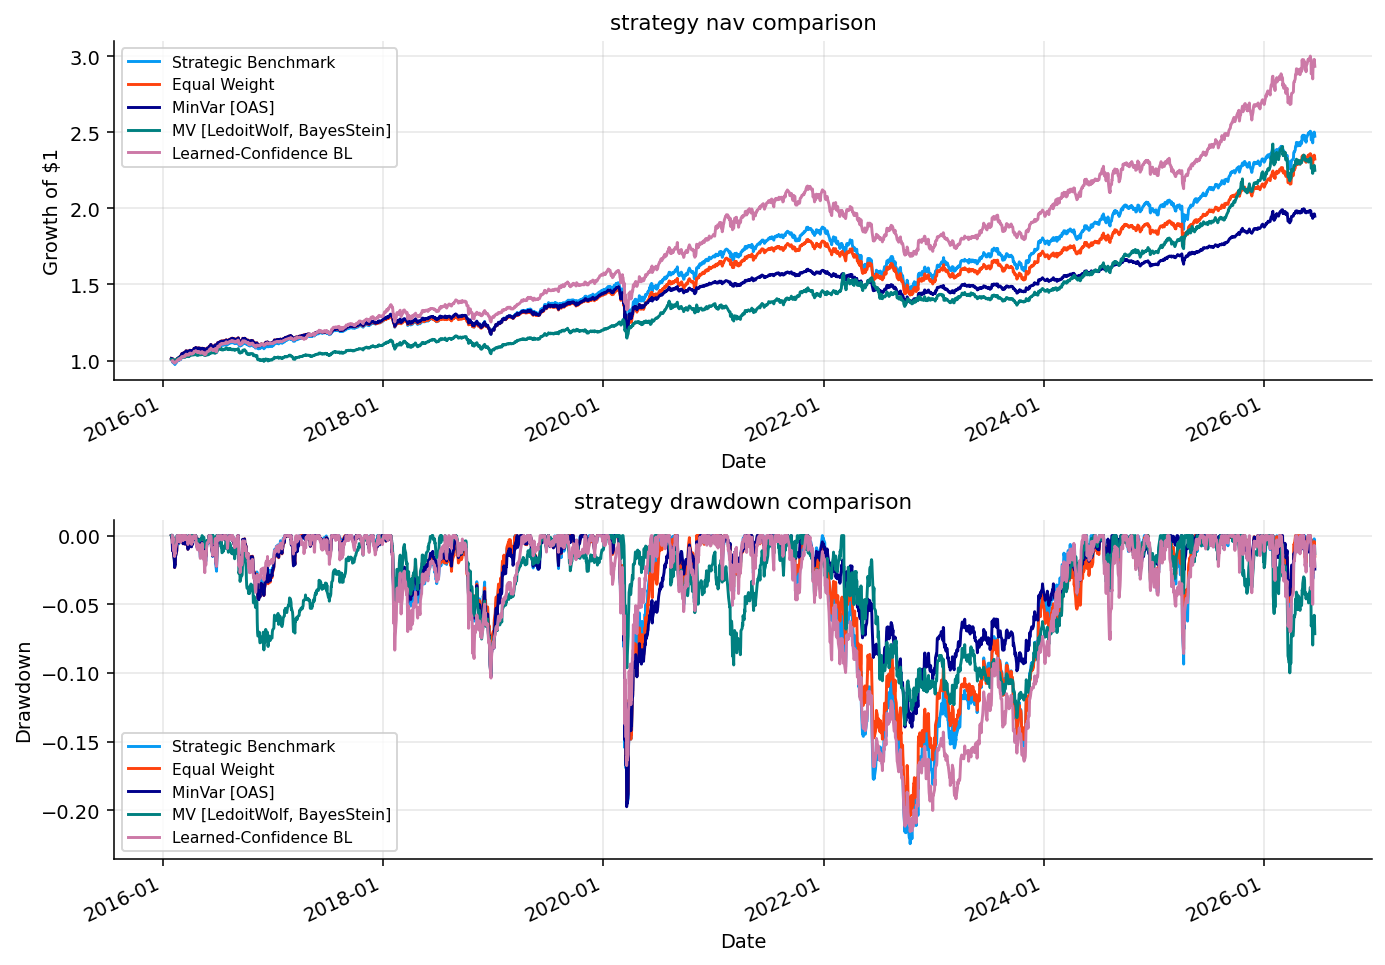

In [35]:
nav_df = pd.DataFrame(nav_by_strategy)[final_strategy_names]
drawdown_df = nav_df / nav_df.cummax() - 1.0
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
plot_strategy_nav(nav_df, final_strategy_names, ax=axes[0], title="strategy nav comparison")
plot_strategy_drawdowns(nav_df, final_strategy_names, ax=axes[1], title="strategy drawdown comparison")
plt.tight_layout()
plt.show()


The NAV and drawdown comparison gives the time-path version of the same result.

BL finishes above the benchmark, equal weight, MinVar, and MV. The strategy doesn't dominate every period, but it compounds better over the full sample. The drawdown panel shows that BL participates in major stress events, which is expected because it remains long-only and benchmark-aware. It isn't a market-neutral strategy.

The drawdown difference versus the benchmark is not huge. The BL model still falls during COVID and the 2022 regime. But the recovery and subsequent compounding are better. That matters more than trying to avoid every drawdown.

The main weakness visible from the path is turnover and responsiveness. Because the model updates monthly, it can lag sudden events. A shock like COVID can hit before signals have time to adjust. But after the shock, the signal engine can rotate faster than a static benchmark.

So the NAV plot supports the table: BL adds value over the full sample, but it remains exposed to broad market risk.


### 15.2 Tail risk and stress windows

The risk-report table compares daily 5% VaR and expected shortfall. Historical VaR is the empirical 5th percentile of returns:

$$
VaR_{5\%}^{hist}= -Q_{0.05}(r_t)
$$

Expected shortfall is the average loss beyond VaR:

$$
ES_{5\%}^{hist}= -E[r_t\mid r_t\leq Q_{0.05}(r_t)]
$$

The filtered historical simulation values are larger because they account for volatility clustering. BL has historical VaR around **1.02%** and historical ES around **1.62%**. Its FHS VaR is around **1.97%** and FHS ES around **2.98%**, higher than the benchmark. That tells us the active tilts increase conditional tail exposure in volatile regimes.

This is an honest limitation. BL improves return and Sharpe, but it doesn't minimize tail risk. MinVar remains the cleanest tail-risk strategy, with lower VaR and ES. The strategic benchmark sits in the middle.

The stress plots are important because each stress window tests a different regime:

- **2018 Q4 selloff**, Fed tightening and equity derisking.
- **COVID crash**, sudden exogenous shock.
- **2022 rates/inflation**, stock-bond correlation failure and duration crash.
- **2023 growth rebound**, recovery led by growth assets.

BL is designed to adapt to regimes, but it can't react before a sudden shock appears in the data. Its strength is more visible in slower regime shifts like 2022 inflation and 2023 growth recovery.


,hist_var5,hist_es5,fhs_var5,fhs_es5
object,,,,
Equal Weight,0.0086,0.0139,0.0119,0.0182
Learned-Confidence BL,0.0102,0.0162,0.0197,0.0298
"MV (LedoitWolf, BayesStein)",0.0083,0.0132,0.0144,0.0209
MinVar (OAS),0.0066,0.0111,0.0086,0.0132
Strategic Benchmark,0.0093,0.0151,0.0127,0.0200


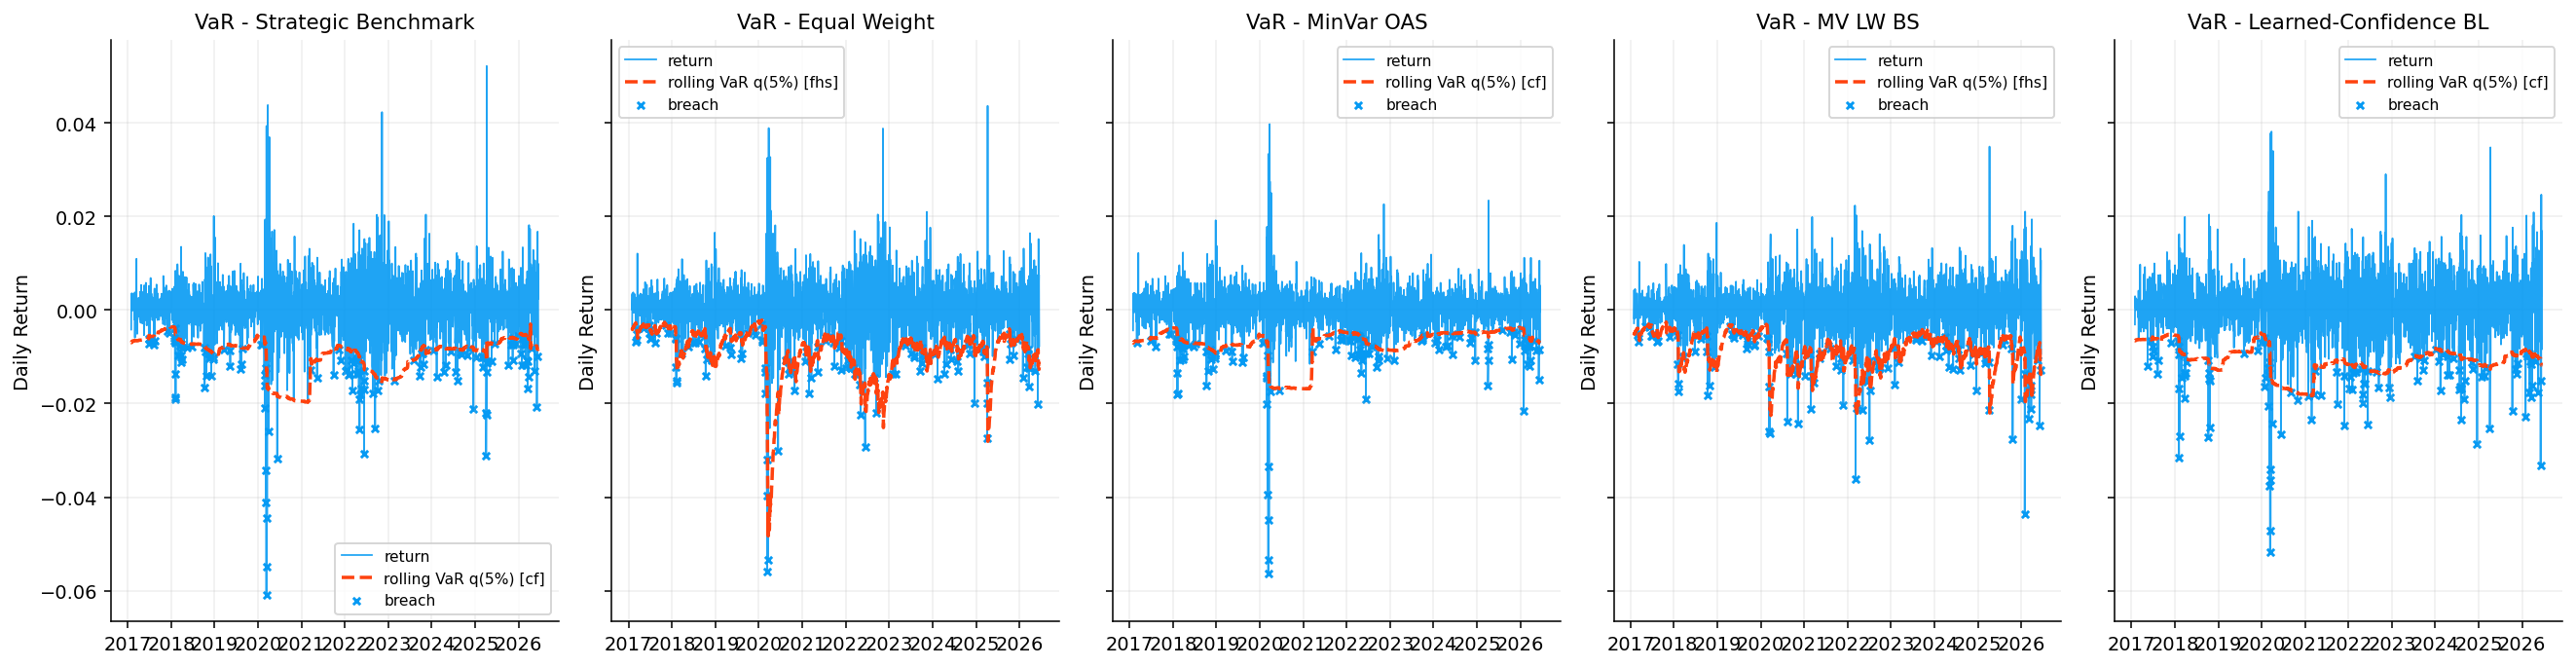

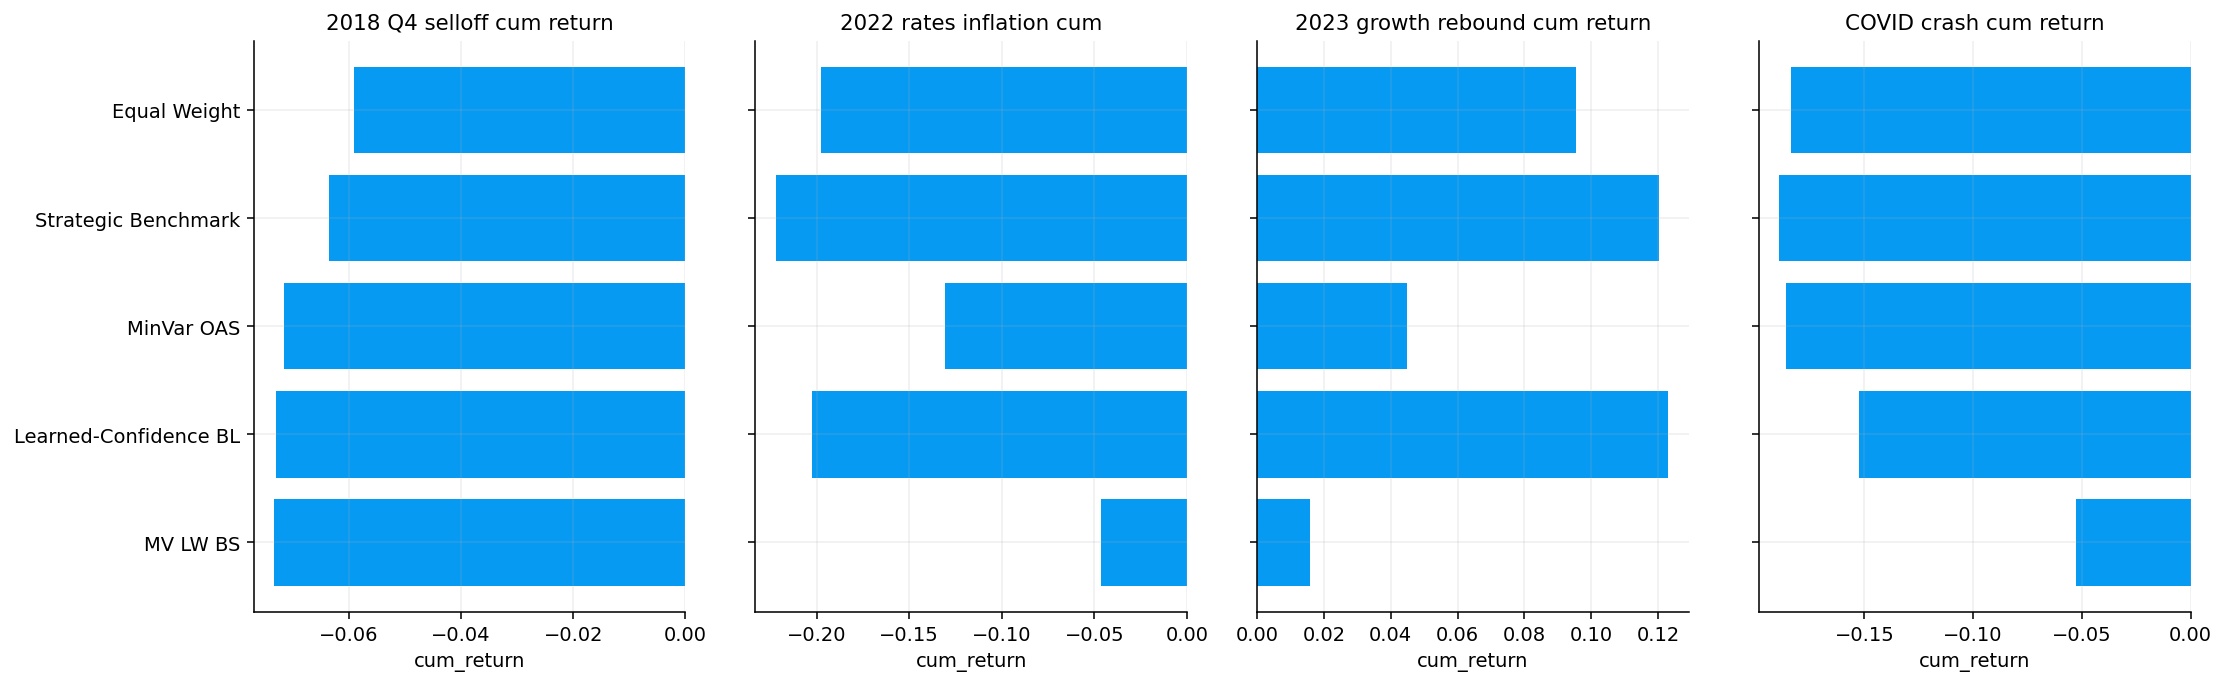

In [44]:
final_returns_df = pd.DataFrame(returns_by_strategy)[final_strategy_names].dropna(how="all").fillna(0.0)

stress_windows = {
    "2018_Q4_selloff": ("2018-10-01", "2018-12-31"),
    "COVID_crash": ("2020-02-19", "2020-03-23"),
    "2022_rates_inflation": ("2022-01-03", "2022-10-14"),
    "2023_growth_rebound": ("2023-01-01", "2023-07-31")}

risk_report_artifacts = risk_report(
    objects=final_returns_df,
    rf_daily=risk_free_daily,
    include={"performance_tables": False, "shape_tables": False, "drawdowns": False, "rolling_vol": False,
             "drawdown_episodes": False, "var_es": True, "var_backtest": True, "stress": True, "capm": False, "rolling_beta": False,
             "correlation": False, "attribution": False, "exec_bullets": False},
    var_settings={"alpha": 0.05, "methods": ["hist", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    stress_settings={"windows": stress_windows, "worst_only": False, "worst_by": "cum_return"},
    layout={"ncols": max(2, len(final_strategy_names)), "sharex": True, "sharey": True},
    output={"display_tables": True, "display_table_keys": ["drawdown_summary", "var_es"], "show_figures": True, 
            "print_exec_bullets": False, "short_labels": False})

stress_result = risk_report_artifacts.series["stress_full"]
var_es = risk_report_artifacts.tables["var_es"]
var_backtest_internal = risk_report_artifacts.tables["var_backtest"]


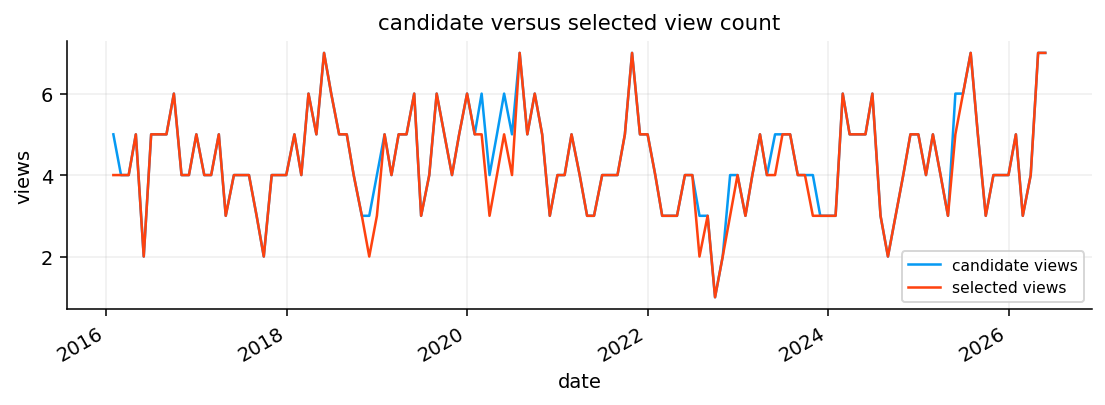

,selected_count,selected_rebalance_count,avg_q_tilt,avg_abs_q_tilt,avg_confidence,avg_selected_score,selected_share_of_rebalances
view,,,,,,,
Risk-adjusted momentum,124,124,0.0705,0.0705,0.4515,0.6337,0.992
Dual momentum,106,106,0.0531,0.0531,0.4238,0.5726,0.848
Duration quality,77,77,0.0123,0.0123,0.3449,0.3544,0.616
Liquidity leadership,51,51,0.0380,0.0380,0.5173,0.5430,0.408
International rotation,46,46,0.0199,0.0199,0.3038,0.4062,0.368
Credit switch: risk-on,44,44,0.0291,0.0291,0.5083,0.5914,0.352
Growth-duration barbell,29,29,0.0255,0.0255,0.4728,0.4743,0.232
Reflation breadth,21,21,0.0532,0.0532,0.6451,0.6627,0.168
Inflation rotation,20,20,0.0141,0.0141,0.3960,0.4408,0.160


,realized_count,hit_rate,avg_forward_payoff_ann,payoff_vol,avg_q_tilt,payoff_ir
view,,,,,,
Risk-adjusted momentum,123,0.5772,0.0405,0.4220,0.0704,0.0959
Dual momentum,105,0.6000,0.0650,0.3766,0.0527,0.1727
Duration quality,76,0.3553,-0.0344,0.3200,0.0124,-0.1073
Liquidity leadership,50,0.6200,0.0533,0.4112,0.0380,0.1297
International rotation,45,0.4444,-0.0562,0.3637,0.0198,-0.1546
Credit switch: risk-on,43,0.6512,0.1504,0.4029,0.0287,0.3733
Growth-duration barbell,29,0.4138,0.0746,0.4565,0.0255,0.1633
Reflation breadth,21,0.7143,0.1328,0.3402,0.0532,0.3905
Inflation rotation,19,0.4737,-0.0667,0.5422,0.0136,-0.1229


In [37]:
candidate_active_count = (candidate_view_log.groupby("date").size().reindex(rebalance_dates[:-1], fill_value=0)
                          if not candidate_view_log.empty else pd.Series(0, index=rebalance_dates[:-1]))
selected_active_count = (selected_view_log.groupby("date").size().reindex(rebalance_dates[:-1], fill_value=0)
                         if not selected_view_log.empty else pd.Series(0, index=rebalance_dates[:-1]))
fig, ax = plt.subplots(figsize=(8, 3))
candidate_active_count.plot(ax=ax, lw=1.3, label="candidate views")
selected_active_count.plot(ax=ax, lw=1.3, label="selected views")
ax.set_title("candidate versus selected view count")
ax.set_ylabel("views")
ax.set_xlabel("date")
ax.legend()
plt.tight_layout()
plt.show()

selected_payoff_history = (build_view_payoff_history(selected_view_log, returns[assets])
                           if not selected_view_log.empty else pd.DataFrame())

if not selected_view_log.empty:
    selected_view_summary = (selected_view_log.groupby("view")
                             .agg(selected_count=("view", "size"), selected_rebalance_count=("date", "nunique"),
                                  avg_q_tilt=("q_tilt_final", "mean"),
                                  avg_abs_q_tilt=("q_tilt_final", lambda x: np.mean(np.abs(x))),
                                  avg_confidence=("confidence", "mean"), avg_selected_score=("selected_score", "mean"))
                             .sort_values("selected_count", ascending=False))
    selected_view_summary["selected_share_of_rebalances"] = (selected_view_summary["selected_rebalance_count"] / len(rebalance_dates[:-1]))
    display(selected_view_summary.round(4))

if not selected_payoff_history.empty:
    selected_payoff_summary = selected_payoff_history.groupby("view").agg(
        realized_count=("payoff_ann", "size"),
        hit_rate=("hit", "mean"),
        avg_forward_payoff_ann=("payoff_ann", "mean"),
        payoff_vol=("payoff_ann", "std"),
        avg_q_tilt=("q_tilt", "mean"))
    selected_payoff_summary["payoff_ir"] = (selected_payoff_summary["avg_forward_payoff_ann"]
                                            / selected_payoff_summary["payoff_vol"].replace(0.0, np.nan))
    display(selected_payoff_summary.sort_values("realized_count", ascending=False).round(4))


## 16) Selected-view reliability after the full backtest

After the full BL backtest, we analyze the selected views, not just the candidate views. This matters because candidate views are generated by rules, while selected views are the ones that actually entered the posterior.

The candidate versus selected count plot shows that most candidate views survive selection, but not all. The selected count is usually close to candidate count, but redundancy and direction caps remove some views. This means the view engine is active but not blindly accepting every signal.

The selected-view summary shows how often each view actually affected the posterior. Risk-adjusted momentum is selected **124** times, almost every rebalance. Dual momentum is selected **106** times. Duration quality is selected **77** times. Liquidity leadership, international rotation, credit switch, growth-duration, reflation, inflation, and correlation stress are less frequent.

The selected-share column helps us read the model's personality. Risk-adjusted momentum has selected share **0.992**, dual momentum **0.848**, and duration quality **0.616**. This project's active engine is therefore heavily momentum-driven, with fixed-income regime controls layered on top.

That is good and bad. It is good because cross-asset momentum has empirical support and works across many regimes. It is risky because momentum can lag reversals. The learned-confidence layer helps, but it doesn't remove that structural lag.


The selected payoff summary is even more useful.

**Dual momentum** has realized hit rate **60.00%**, average forward payoff around **6.50% annualized**, and payoff IR **0.1727**. This is one of the strongest selected views because it has both sample size and positive realized performance.

**Credit switch: risk-on** is very strong among selected views: hit rate **65.12%**, average payoff **15.04%**, and payoff IR **0.3733**. This supports the idea that credit leadership is a useful signal for risk-on allocation.

**Reflation breadth** has hit rate **71.43%** and payoff IR **0.3905**, but only 21 selected observations. This is promising, but less mature than the momentum views.

**Liquidity leadership** has hit rate **62%** and payoff IR **0.1297**, making it a useful but moderate view.

Weak selected views include **Duration quality**, **International rotation**, **Inflation rotation**, and **Credit switch: risk-off**. Duration quality has hit rate **35.53%** and negative payoff IR. International rotation has hit rate **44.44%** and negative payoff IR. Credit switch risk-off has very poor realized profile. These weak results explain why the learned-confidence system shrinks or floors these views.

This output is exactly why learned confidence is necessary. Without it, all selected views could be treated too similarly. With it, historically useful views get more influence, while weak views still exist but have lower posterior impact.


,asset,benchmark_weight,prior_mu,post_mu_learned_confidence_bl,posterior_shift_learned_confidence_bl
0,SPY,0.2222,0.0936,0.1330,0.0394
1,QQQ,0.0808,0.1278,0.2054,0.0776
2,IWM,0.0404,0.1431,0.1741,0.0310
3,EFA,0.0909,0.1397,0.2345,0.0947
4,EEM,0.0505,0.2014,0.3000,0.0986
5,TLT,0.0808,0.0517,0.0320,-0.0197
6,IEF,0.0808,0.0316,0.0298,-0.0018
7,SHY,0.0505,0.0079,0.0093,0.0013
8,AGG,0.1010,0.0277,0.0247,-0.0030
9,LQD,0.0505,0.0378,0.0301,-0.0078


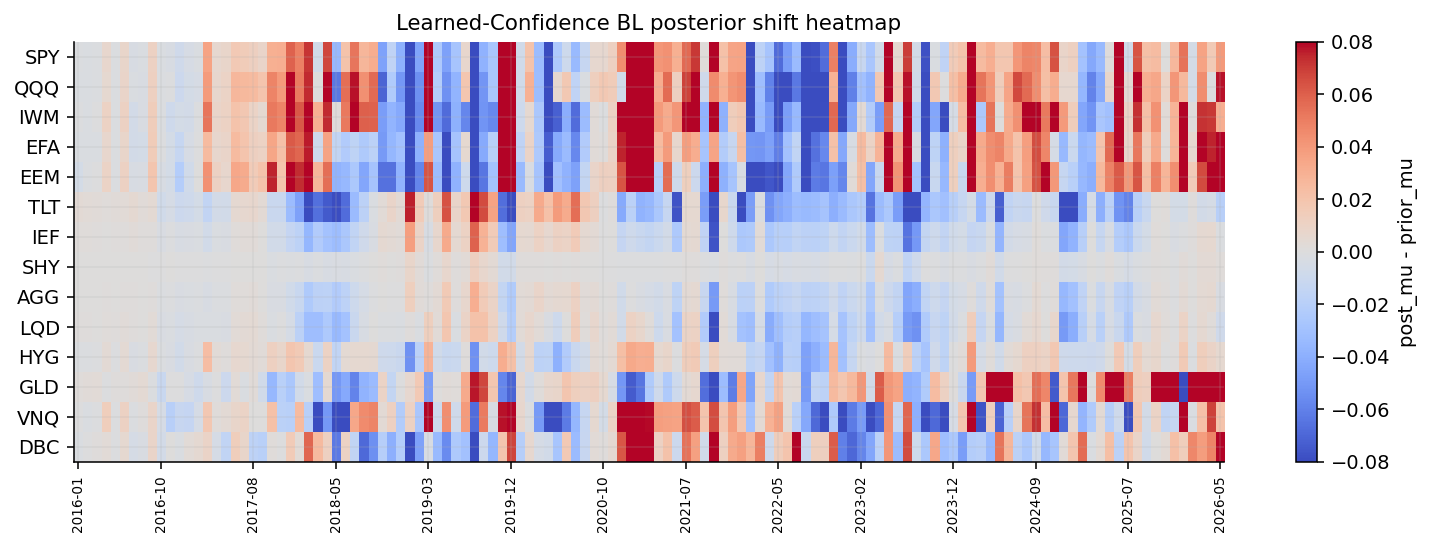

In [38]:
latest_post_date = posterior_log["date"].max() if not posterior_log.empty else pd.Timestamp(rebalance_dates[-2])
prior_latest = prior_mu_by_date[pd.Timestamp(latest_post_date)].reindex(assets)
posterior_clarity = pd.DataFrame({
    "asset": assets,
    "benchmark_weight": benchmark_w.reindex(assets).values,
    "prior_mu": prior_latest.values,
    "post_mu_learned_confidence_bl": post_mu_store.get(
        ("Learned-Confidence BL", latest_post_date), prior_latest).reindex(assets).values,
})
posterior_clarity["posterior_shift_learned_confidence_bl"] = (
    posterior_clarity["post_mu_learned_confidence_bl"] - posterior_clarity["prior_mu"])
display(posterior_clarity.round(4))
shift_cols = {}
for dt in sorted({key[1] for key in post_mu_store if key[0] == "Learned-Confidence BL"}):
    shift_cols[dt] = (post_mu_store[("Learned-Confidence BL", dt)].reindex(assets)
                      - prior_mu_by_date[dt].reindex(assets))
learned_confidence_shift = pd.DataFrame(shift_cols)
if not learned_confidence_shift.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    im = ax.imshow(learned_confidence_shift, aspect="auto", cmap="coolwarm", vmin=-0.08, vmax=0.08)
    ax.set_title("Learned-Confidence BL posterior shift heatmap")
    ax.set_yticks(range(len(learned_confidence_shift.index)), learned_confidence_shift.index)
    tick_count = min(14, len(learned_confidence_shift.columns))
    tick_pos = (np.linspace(0, len(learned_confidence_shift.columns) - 1, tick_count, dtype=int)
                if tick_count else [])
    ax.set_xticks(tick_pos, [learned_confidence_shift.columns[i].strftime("%Y-%m") for i in tick_pos],
                  rotation=90, fontsize=7)
    fig.colorbar(im, ax=ax, label="post_mu - prior_mu")
    plt.tight_layout()
    plt.show()


### 16.1 Posterior shift heatmap and latest posterior table

The posterior clarity table compares benchmark weight, prior return, posterior return, and posterior shift for the latest logged rebalance. The shift is:

$$
\Delta\mu_i = \mu_{post,i} - \pi_i
$$

This is the cleanest way to understand what the view system is doing at the asset level.

In the latest full-log table, EEM receives a very large positive shift, about **+9.86%**, DBC about **+9.76%**, EFA about **+9.47%**, GLD about **+11.84%**, QQQ about **+7.76%**, and SPY about **+3.94%**. Some of these are direct view effects, while others come from covariance propagation through the posterior formula.

The heatmap shows how these shifts evolve over time. It is one of the best diagnostics in the project because it separates **expected-return belief changes** from **final weights**. A posterior shift can be strong, but the optimizer may still limit the final allocation because of caps, active weight limits, sleeve constraints, or covariance risk.

The heatmap has visible regime blocks. Around 2022, real assets and inflation-sensitive exposures receive stronger positive shifts, while duration is penalized. In growth-led periods, QQQ and equity-linked assets receive positive shifts. The shifts are not random noise. They cluster around economic regimes.

That said, the heatmap is also noisy. Some assets switch sign frequently, especially where momentum views and covariance effects interact. This is a normal feature of monthly tactical allocation.


In [39]:
if not candidate_view_log.empty:
    candidate_counts = candidate_view_log.groupby("view_id").size().rename("candidate_count")
    view_display = (candidate_view_log.groupby("view_id")["view"]
                    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
                    .rename("view"))
    risk_mode = (candidate_view_log.groupby("view_id")["risk_orientation"]
                 .agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
                 .rename("risk_orientation_mode"))
else:
    candidate_counts = pd.Series(dtype=float, name="candidate_count")
    view_display = pd.Series(dtype=object, name="view")
    risk_mode = pd.Series(dtype=object, name="risk_orientation_mode")

if not selected_view_log.empty:
    selected_counts = selected_view_log.groupby("view_id").size().rename("selected_count")
    avg_abs_q = (selected_view_log.groupby("view_id")["q_tilt_final"].agg(lambda x: np.mean(np.abs(x))).rename("avg_abs_q"))
    avg_q_tilt = selected_view_log.groupby("view_id")["q_tilt_final"].mean().rename("avg_q_tilt")
else:
    selected_counts = pd.Series(dtype=float, name="selected_count")
    avg_abs_q = pd.Series(dtype=float, name="avg_abs_q")
    avg_q_tilt = pd.Series(dtype=float, name="avg_q_tilt")

if not all_payoff_history.empty:
    payoff_stats = all_payoff_history.groupby("view_id").agg(
        hit_rate=("hit", "mean"),
        avg_payoff=("payoff", "mean"),
        payoff_vol=("payoff", "std"))
    payoff_stats["payoff_ir"] = payoff_stats["avg_payoff"] / payoff_stats["payoff_vol"].replace(0.0, np.nan)
    recent_hits = (all_payoff_history.sort_values("date").groupby("view_id").tail(6).groupby("view_id")["hit"].mean().rename("recent_hit_rate"))
    if "stress_state" in all_payoff_history.columns:
        stress_sample = all_payoff_history[all_payoff_history["stress_state"].astype(bool)]
        stress_stats = (stress_sample.groupby("view_id").agg(stress_obs=("hit", "size"),
                                                              stress_hit_rate=("hit", "mean"),
                                                              stress_avg_payoff=("payoff", "mean"))
                        if not stress_sample.empty else pd.DataFrame())
    else:
        stress_stats = pd.DataFrame()
else:
    payoff_stats = pd.DataFrame(columns=["hit_rate", "avg_payoff", "payoff_vol", "payoff_ir"])
    recent_hits = pd.Series(dtype=float, name="recent_hit_rate")
    stress_stats = pd.DataFrame()

conf_means = (confidence_log.groupby("view_id")["confidence"].mean().rename("avg_confidence")
              if not confidence_log.empty else pd.Series(dtype=float, name="avg_confidence"))
score_means = (confidence_log.groupby("view_id")["selected_score"].mean().rename("avg_selected_score")
               if not confidence_log.empty and "selected_score" in confidence_log.columns
               else pd.Series(dtype=float, name="avg_selected_score"))

reliability = pd.concat([view_display, candidate_counts, selected_counts, payoff_stats, avg_abs_q, avg_q_tilt,
                         conf_means, score_means, recent_hits, stress_stats, risk_mode], axis=1)
reliability["candidate_count"] = reliability["candidate_count"].fillna(0)
reliability["selected_count"] = reliability["selected_count"].fillna(0)
reliability["selected_share"] = reliability["selected_count"] / reliability["candidate_count"].replace(0.0, np.nan)
reliability = reliability.sort_values(["selected_count", "candidate_count"], ascending=False)
reliability = reliability.set_index("view")
display(reliability.round(4))


,candidate_count,selected_count,hit_rate,avg_payoff,payoff_vol,payoff_ir,avg_abs_q,avg_q_tilt,avg_confidence,avg_selected_score,recent_hit_rate,stress_obs,stress_hit_rate,stress_avg_payoff,risk_orientation_mode,selected_share
view,,,,,,,,,,,,,,,,
Risk-adjusted momentum,125,124,0.5726,0.0376,0.4215,0.0893,0.0705,0.0705,0.4515,0.6337,0.6667,51,0.5098,-0.0473,neutral,0.9920
Dual momentum,118,106,0.5726,0.0478,0.4323,0.1106,0.0531,0.0531,0.4238,0.5726,1.0000,49,0.5102,-0.0054,neutral,0.8983
Duration quality,77,77,0.3553,-0.0344,0.3200,-0.1073,0.0123,0.0123,0.3449,0.3544,0.3333,30,0.3667,-0.0116,risk_off,1.0000
Credit switch: risk-on,57,57,0.5536,0.0681,0.5392,0.1263,0.0282,0.0282,0.5020,0.5862,0.8333,23,0.4348,-0.0337,risk_on,1.0000
Liquidity leadership,51,51,0.6200,0.0533,0.4112,0.1297,0.0380,0.0380,0.5173,0.5430,0.5000,21,0.6190,0.0643,risk_on,1.0000
International rotation,46,46,0.4444,-0.0562,0.3637,-0.1546,0.0199,0.0199,0.3038,0.4062,0.5000,14,0.3571,-0.1804,risk_off,1.0000
Growth-duration barbell,29,29,0.4138,0.0746,0.4565,0.1633,0.0255,0.0255,0.4728,0.4743,0.1667,11,0.4545,0.2083,risk_on,1.0000
Reflation breadth,21,21,0.7143,0.1328,0.3402,0.3905,0.0532,0.0532,0.6451,0.6627,0.3333,2,1.0000,0.2215,risk_on,1.0000
Inflation rotation,20,20,0.4737,-0.0667,0.5422,-0.1229,0.0141,0.0141,0.3960,0.4408,0.5000,5,0.2000,-0.3559,neutral,1.0000


,asset,active_weight_learned_confidence_bl
0,SPY,-0.1297
1,AGG,-0.1010
2,TLT,-0.0808
3,IEF,-0.0808
4,LQD,-0.0505
5,IWM,-0.0404
6,HYG,-0.0404
7,VNQ,-0.0138
8,DBC,0.0298
9,GLD,0.0495


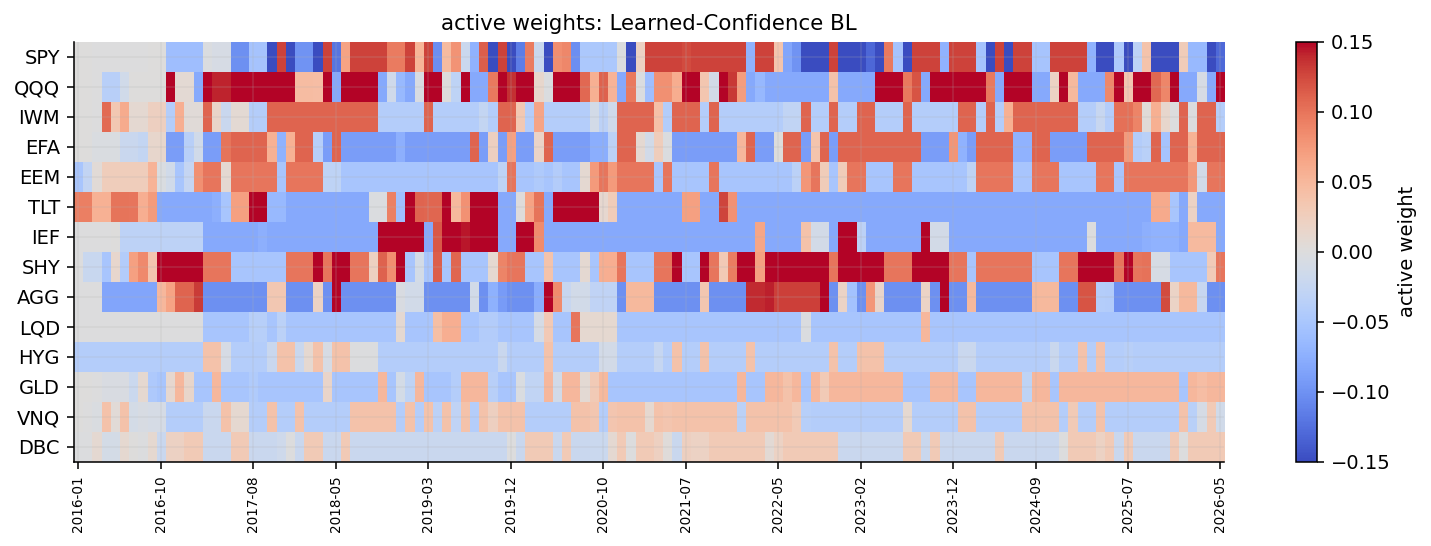

In [40]:
learned_confidence_weights = combined_results["Learned-Confidence BL"]["weights"].reindex(columns=assets)
benchmark_aligned = benchmark_w.reindex(assets).fillna(0.0)
active_w_learned_confidence = learned_confidence_weights.subtract(benchmark_aligned, axis=1)
latest_active_w = active_w_learned_confidence.iloc[-1].sort_values()
display(pd.DataFrame({"asset": latest_active_w.index,
                      "active_weight_learned_confidence_bl": latest_active_w.values}).round(4))

frame = active_w_learned_confidence.T
fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(frame, aspect="auto", cmap="coolwarm", vmin=-0.15, vmax=0.15)
ax.set_title("active weights: Learned-Confidence BL")
ax.set_yticks(range(len(frame.index)), frame.index)
tick_count = min(14, len(frame.columns))
tick_pos = np.linspace(0, len(frame.columns) - 1, tick_count, dtype=int) if tick_count else []
ax.set_xticks(tick_pos, [frame.columns[i].strftime("%Y-%m") for i in tick_pos], rotation=90, fontsize=7)
fig.colorbar(im, ax=ax, label="active weight")
plt.tight_layout()
plt.show()


In [41]:
def active_risk_series(weights):
    rows = []
    for dt, row in weights.iterrows():
        dt = pd.Timestamp(dt)
        if dt not in cov_by_date:
            continue
        diff = row.reindex(assets).fillna(0.0).values - benchmark_aligned.values
        cov_ann = cov_by_date[dt].loc[assets, assets].values
        rows.append((dt, float(np.sqrt(max(diff @ cov_ann @ diff, 0.0)))))
    return pd.Series(dict(rows)).sort_index()


active_summary = pd.DataFrame({
    "avg_active_risk": {
        "Learned-Confidence BL": active_risk_series(
            combined_results["Learned-Confidence BL"]["weights"].reindex(columns=assets)).mean(),
    },
    "avg_turnover": {"Learned-Confidence BL": combined_results["Learned-Confidence BL"]["turnover"].mean()},
})
display(active_summary.round(4))


,avg_active_risk,avg_turnover
Learned-Confidence BL,0.0369,0.2712


### 16.2 View reliability table and active weights

The final reliability table combines candidate counts, selected counts, payoff statistics, average confidence, stress-period behavior, and selected share. It is the model audit.

A few rows stand out:

- **Risk-adjusted momentum**: 125 candidates, 124 selected, hit rate **57.26%**, average confidence **0.4515**.
- **Dual momentum**: 118 candidates, 106 selected, hit rate **57.26%**, recent hit rate **100%**, average confidence **0.4238**.
- **Reflation breadth**: hit rate **71.43%**, payoff IR **0.3905**, average confidence **0.6451**, but smaller sample.
- **Correlation stress**: hit rate **75%** and high payoff IR, but only 4 observations, so it has limited statistical reliability.
- **Duration quality** and **International rotation**: weak hit rates and negative payoff IR, so the confidence layer keeps them small.

The latest active-weight table shows the final effect after optimization. QQQ is at the active cap with **+15.00%** active weight. EFA is **+10.91%**, EEM **+9.95%**, SHY **+9.95%**, GLD **+4.95%**, and DBC **+2.98%**. The biggest underweights are SPY **-12.97%**, AGG **-10.10%**, TLT **-8.08%**, IEF **-8.08%**, and LQD **-5.05%**.

The latest weight pattern is not simply "risk-on everything." It is a relative allocation:

- overweight QQQ, EEM, EFA, GLD, DBC, and SHY,
- underweight broad SPY, core bonds, long duration, and credit,
- keep active risk controlled around the benchmark.

The active-risk summary shows average active risk around **3.69%** and average turnover **27.12%**. That is a moderate active-risk profile but a high-turnover profile. For a monthly tactical model, that is believable, but costs need to be monitored.


## 17) Sector ETF transfer with quantfinlab

The final section repeats the framework on sector ETFs through the packaged `quantfinlab` library. This is a transfer test: can the same learned-confidence Black-Litterman logic work on a different universe?

The sector data comes from the same repository data area: [sector and cross-asset ETF data](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data). The tradable universe is the 11 SPDR sector ETFs:

| ETF | Sector role |
|---|---|
| XLK | Technology, growth and high-beta leadership |
| XLC | Communication services, tech-adjacent mega-cap exposure |
| XLY | Consumer discretionary, cyclical consumer spending |
| XLF | Financials, rates and credit-cycle sensitivity |
| XLI | Industrials, economic cycle and capex exposure |
| XLE | Energy, oil and inflation sensitivity |
| XLB | Materials, commodities and global growth exposure |
| XLV | Health care, defensive quality growth |
| XLP | Consumer staples, classic defensive sector |
| XLU | Utilities, defensive and rate-sensitive yield exposure |
| XLRE | Real estate, rate-sensitive property exposure |

The signal assets still include cross-asset indicators like SPY, QQQ, IWM, TLT, IEF, SHY, LQD, HYG, GLD, DBC, and UUP. That means we trade sectors, but we still use broad macro signals to decide which sector views make sense.

The benchmark is equal weight:

$$
w_{b,i}=\frac{1}{11}\approx 0.0909
$$

This is a natural starting point for sector rotation because the sectors all belong to the same broad equity market. There isn't an obvious strategic reason to heavily overweight one sector before signals arrive.


close panel: (6906, 32) 1999-01-04 to 2026-06-17


,ticker,role,first_date,last_date,observations,missing_pct_after_first_valid,included
0,XLK,tradable,2018-07-02,2026-06-17,2001,0.0,True
1,XLC,tradable,2018-07-02,2026-06-17,2001,0.0,True
2,XLY,tradable,2018-07-02,2026-06-17,2001,0.0,True
3,XLF,tradable,2018-07-02,2026-06-17,2001,0.0,True
4,XLI,tradable,2018-07-02,2026-06-17,2001,0.0,True
5,XLE,tradable,2018-07-02,2026-06-17,2001,0.0,True
6,XLB,tradable,2018-07-02,2026-06-17,2001,0.0,True
7,XLV,tradable,2018-07-02,2026-06-17,2001,0.0,True
8,XLP,tradable,2018-07-02,2026-06-17,2001,0.0,True
9,XLU,tradable,2018-07-02,2026-06-17,2001,0.0,True


sector assets: ['XLK', 'XLC', 'XLY', 'XLF', 'XLI', 'XLE', 'XLB', 'XLV', 'XLP', 'XLU', 'XLRE']
sector signal assets: ['SPY', 'QQQ', 'IWM', 'TLT', 'IEF', 'SHY', 'LQD', 'HYG', 'GLD', 'DBC', 'UUP']
sector return panel: (2000, 11) 2018-07-03 to 2026-06-17
sector rebalance dates: 72 2020-07-31 to 2026-06-17


,benchmark_weight
XLK,0.0909
XLC,0.0909
XLY,0.0909
XLF,0.0909
XLI,0.0909
XLE,0.0909
XLB,0.0909
XLV,0.0909
XLP,0.0909
XLU,0.0909


,family,display_name,cap,function,economic_idea,typical_long,typical_short,main_signal
0,sector_momentum,Sector momentum,0.08,sector_momentum,Cross-sectional relative sector strength.,Top 3 sectors by momentum/vol score,Bottom 3 sectors by momentum/vol score,63d/126d sector momentum minus volatility
1,growth_leadership,Growth leadership,0.06,growth_leadership,Growth sectors lead when QQQ and growth basket...,"XLK, XLC, XLY","XLP, XLU, XLV",QQQ/SPY and growth/defensive relative momentum
2,defensive_rotation,Defensive rotation,0.06,defensive_rotation,Defensive sectors outperform in equity stress.,"XLP, XLU, XLV",Growth sectors and weak cyclicals,"SPY drawdown, SPY momentum, defensive relative..."
3,cyclical_breadth,Cyclical breadth,0.80,cyclical_breadth,Cyclicals lead when participation broadens.,"XLI, XLF, XLB, XLE","XLP, XLU, XLV",Cyclical breadth and cyclical/defensive relati...
4,credit_beta,Credit beta,0.07,credit_beta,Credit-sensitive sectors benefit when high-yie...,"XLF, XLY, XLI","XLV, XLP, XLU","HYG/LQD, HYG/SHY, HYG momentum"
5,inflation_beneficiaries,Inflation beneficiaries,0.06,inflation_beneficiaries,Energy and materials benefit from commodity/in...,"XLE, XLB","XLK, XLY",DBC/GLD momentum and inflation basket leadership
6,duration_sensitive,Duration sensitive,0.06,duration_sensitive,Rate-sensitive sectors respond to duration reg...,"XLU, XLV, XLRE","XLF, XLE","TLT/SHY, IEF/SHY, rate-sensitive relative stre..."
7,small_cap_risk_on,Small-cap risk-on,0.08,small_cap_risk_on,IWM/SPY leadership supports domestic cyclicals.,"XLI, XLF, XLY","XLP, XLU, XLV",IWM/SPY and small-cap-sensitive leadership
8,quality_defensive,Quality defensive,0.05,quality_defensive,Quality defensive sectors lead under volatilit...,"XLV, XLP","XLE, XLF, XLY",SPY volatility z-score and sector correlation
9,sector_reversal,Sector reversal,0.08,sector_reversal,Short-term sector extremes mean-revert after h...,Short-term laggards with acceptable 126d trend,Overextended 21d winners,21d sector dispersion and 126d trend filter


...

,Active return,Tracking error,Information ratio,Hit rate vs benchmark,Correlation to benchmark,Beta to benchmark,Active max drawdown,Avg active weight distance,Benchmark
Strategy,,,,,,,,,
Learned-Confidence BL,0.0062,0.053,0.1169,0.5027,0.9379,0.9679,-0.1302,1.0103,Benchmark


,display_name,candidate_count,selected_count,selected_share,hit_rate,avg_payoff,payoff_vol,payoff_ir,avg_q,avg_abs_q,avg_confidence
view_family,,,,,,,,,,,
duration_sensitive,Duration sensitive,46,46,1.0000,0.4889,0.0181,0.7521,0.0241,0.0344,0.0344,0.4886
cyclical_breadth,Cyclical breadth,43,43,1.0000,0.4651,0.0326,0.4570,0.0713,0.2817,0.2817,0.4970
growth_leadership,Growth leadership,38,38,1.0000,0.6486,0.1243,0.5593,0.2222,0.0393,0.0393,0.5581
small_cap_risk_on,Small-cap risk-on,51,37,0.7255,0.5200,-0.0057,0.5093,-0.0113,0.0492,0.0492,0.5571
inflation_beneficiaries,Inflation beneficiaries,30,30,1.0000,0.3667,-0.0788,1.0075,-0.0782,0.0130,0.0130,0.4188
credit_beta,Credit beta,37,22,0.5946,0.5833,0.0458,0.4968,0.0923,0.0354,0.0354,0.5841
quality_defensive,Quality defensive,18,18,1.0000,0.2778,-0.3002,0.6932,-0.4330,0.0086,0.0086,0.3252
sector_momentum,Sector momentum,18,18,1.0000,0.4444,-0.0522,0.7376,-0.0707,0.0348,0.0348,0.5068
defensive_rotation,Defensive rotation,16,15,0.9375,0.5625,-0.1214,0.5831,-0.2082,0.0160,0.0160,0.4925


,count,share
kept,280.0000,0.9032
redundancy gate: exposure cosine similarity,30.0000,0.0968
average selected views,3.9437,0.0000
average candidate views,4.3662,0.0000


,benchmark_weight,bl_weight,active_weight,abs_active_weight
XLC,0.0909,0.2318,0.1409,0.1409
XLK,0.0909,0.1928,0.1019,0.1019
XLV,0.0909,0.0000,-0.0909,0.0909
XLP,0.0909,0.0000,-0.0909,0.0909
XLF,0.0909,0.0000,-0.0909,0.0909
XLY,0.0909,0.1792,0.0883,0.0883
XLI,0.0909,0.0110,-0.0799,0.0799
XLE,0.0909,0.1158,0.0249,0.0249
XLU,0.0909,0.0784,-0.0125,0.0125
XLB,0.0909,0.0960,0.0051,0.0051


,window,strategy,return,active_return
0,2022 rates/inflation,Benchmark,-0.1820,0.0000
1,2022 rates/inflation,MinVar (best grid),-0.1861,-0.0041
2,2022 rates/inflation,MV (best grid),-0.0730,0.1090
3,2022 rates/inflation,Learned-Confidence BL,-0.0913,0.0907
4,2023 growth rebound,Benchmark,0.1379,0.0000
5,2023 growth rebound,MinVar (best grid),0.0748,-0.0631
6,2023 growth rebound,MV (best grid),0.0291,-0.1088
7,2023 growth rebound,Learned-Confidence BL,0.1319,-0.0060
8,2024-2025 cycle,Benchmark,0.3182,0.0000
9,2024-2025 cycle,MinVar (best grid),0.2312,-0.0870


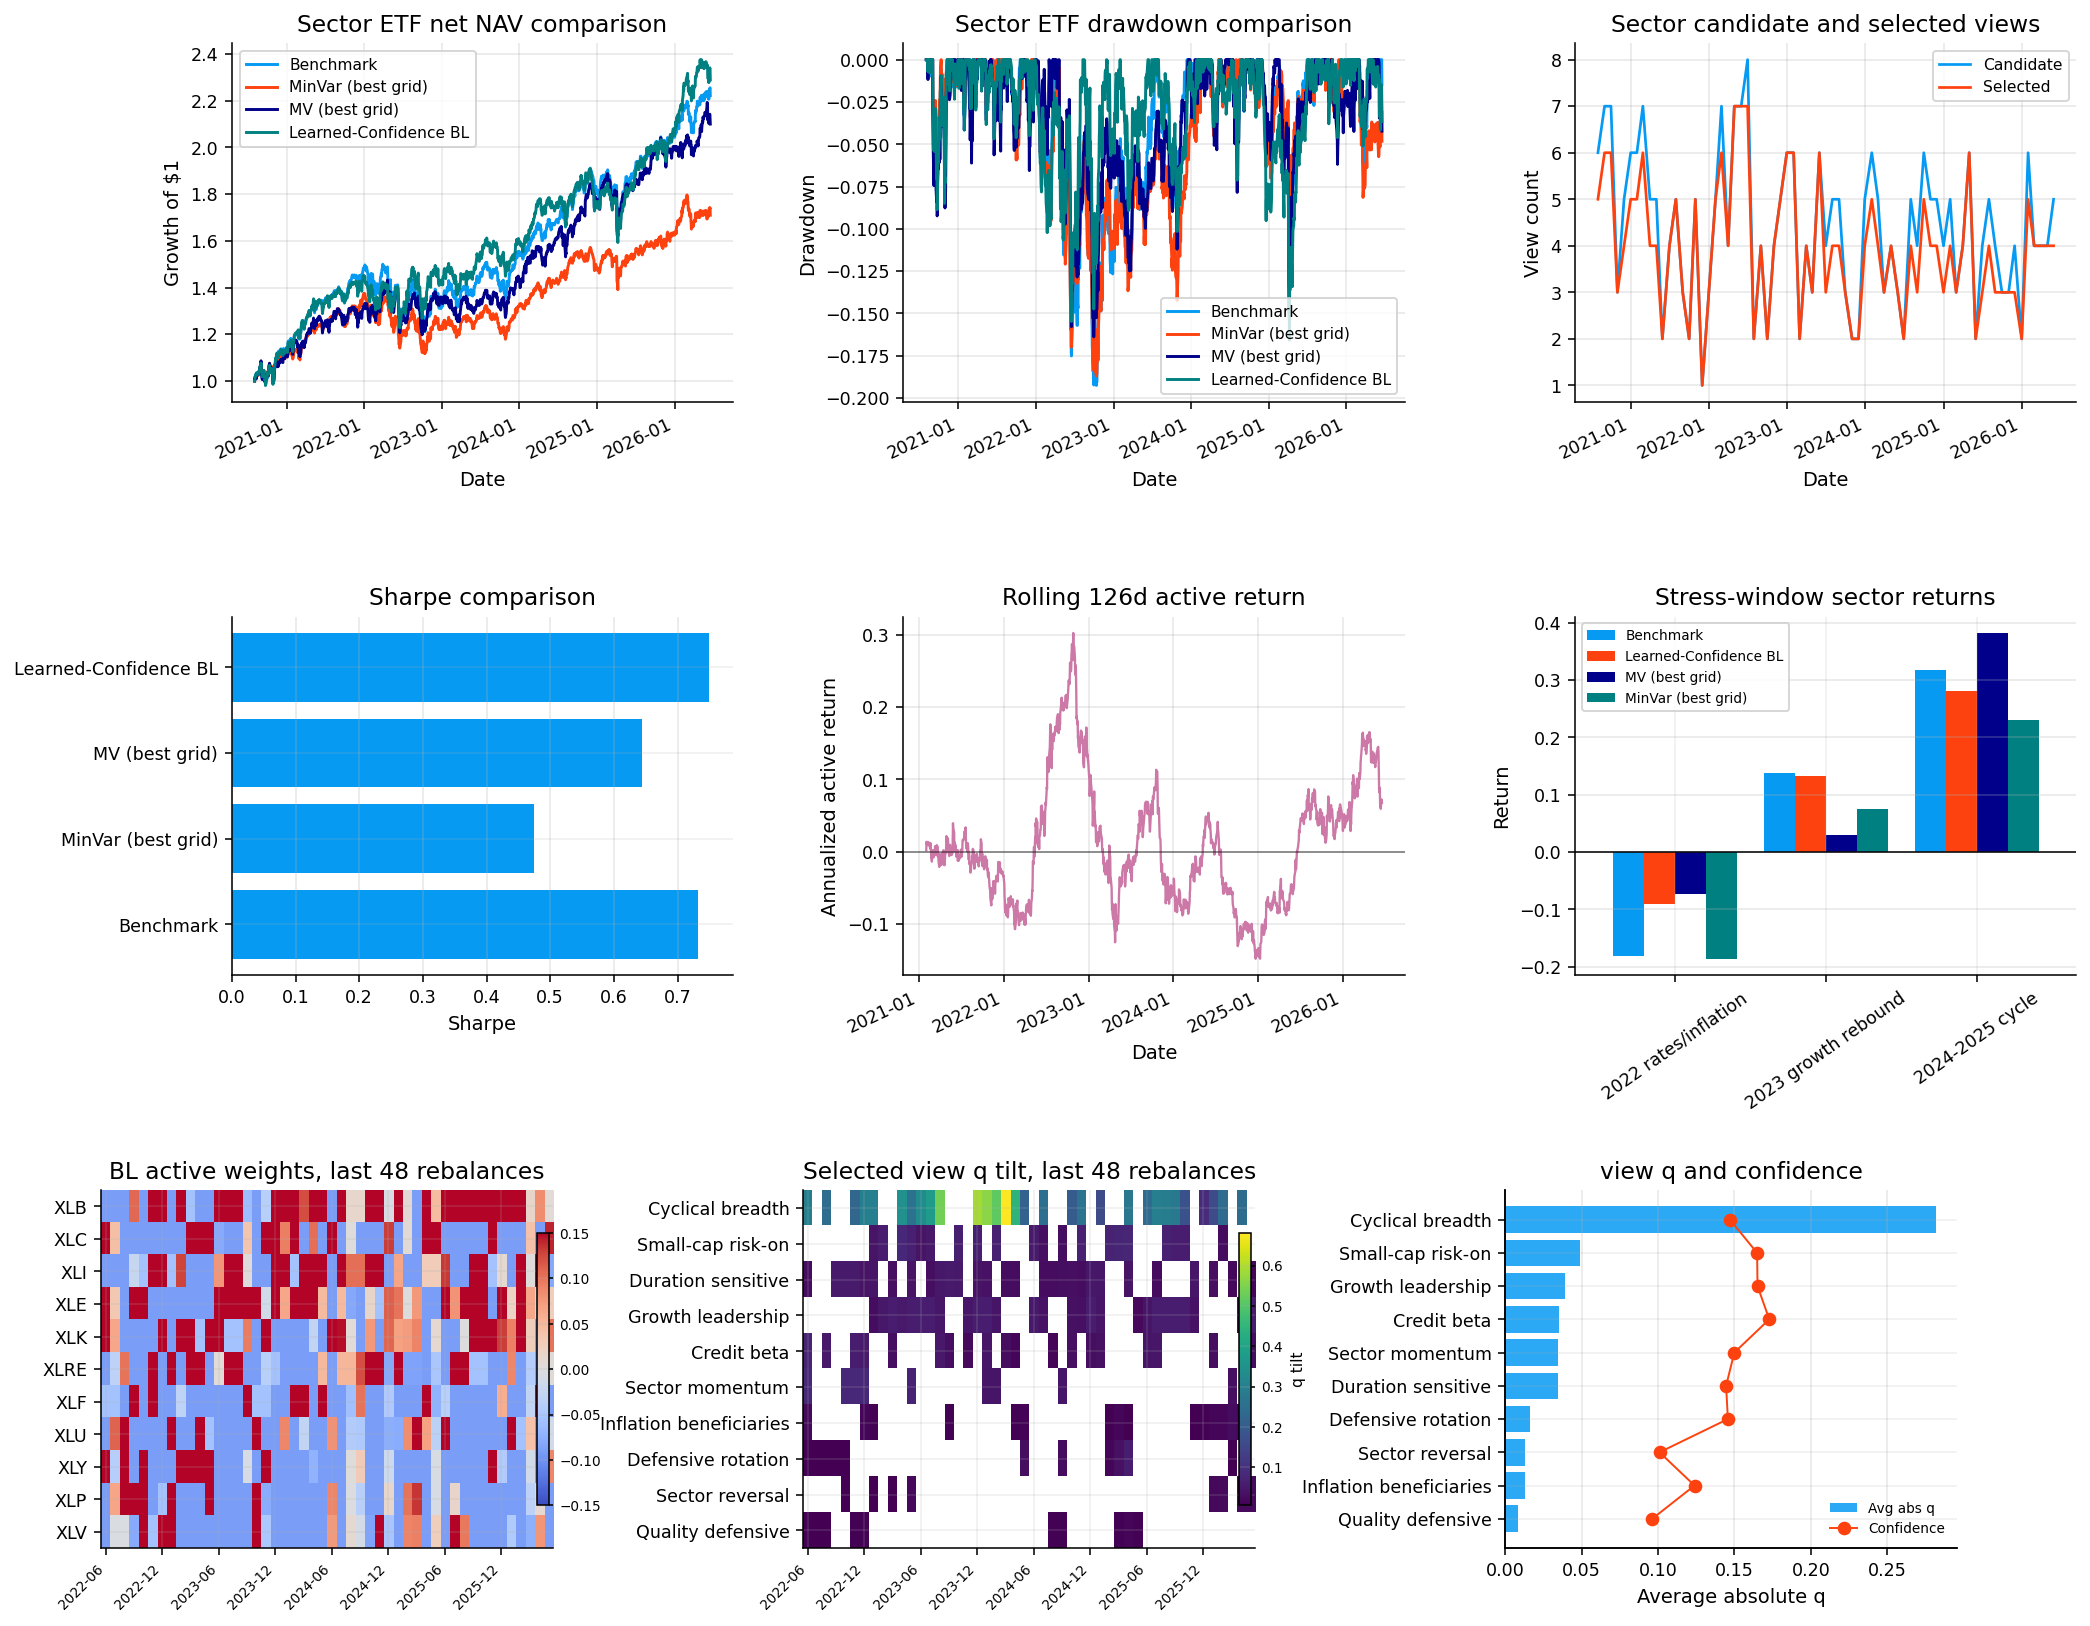

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from IPython.display import display

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.plotting.portfolio import (apply_portfolio_subplot_layout, plot_active_weights_heatmap,
                                            plot_metric_bar, plot_q_tilt_heatmap, plot_rolling_active_metrics,
                                            plot_strategy_drawdowns, plot_strategy_nav, plot_stress_summary,
                                            plot_view_count_timeline, plot_view_q_and_confidence)
from quantfinlab.portfolio import make_rebalance_dates, prices_to_returns
from quantfinlab.portfolio.black_litterman import (BLSettings, active_summary_table, data_coverage_table,
                                                   latest_view_table, latest_weight_table, learned_confidence_bl, market_state,
                                                     model_comparison_table, risk_free_daily, selection_summary_table,
                                                     stress_summary_table, view_reliability_table, view_spec_table)
from quantfinlab.portfolio.views import (DEFAULT_SECTOR_DISPLAY_NAMES, SECTOR_VIEW_SPECS, ViewSettings,
                                         credit_beta, cyclical_breadth, defensive_rotation,
                                         duration_sensitive, growth_leadership, inflation_beneficiaries, quality_defensive,
                                         sector_momentum, sector_reversal, small_cap_risk_on, view_rows)
from quantfinlab.portfolio.walkforward import run_walkforward_grid
from cycler import cycler
colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
          "#DC143C", "#9614fa", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({
    "figure.figsize": (7, 3.5),
    "figure.dpi": 140,
    "savefig.dpi": 250,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8})

warnings.filterwarnings("ignore")
sector_annualization = 252.0
bl_mv_lambda = 3.0

data_paths = [Path("../data/sector_etfs.csv"), Path("../data/core_cross_asset_etfs.csv")]
close_all = load_yfinance_panel(data_paths, fields=("close",), lowercase=False)["close"]
print("close panel:", close_all.shape, close_all.index.min().date(), "to", close_all.index.max().date())

sector_start = "2018-07-01"

requested_sector_assets = [
    "XLK", "XLC", "XLY", "XLF", "XLI",
    "XLE", "XLB", "XLV", "XLP", "XLU", "XLRE"]

requested_signal_assets = [
    "SPY", "QQQ", "IWM",
    "TLT", "IEF", "SHY",
    "LQD", "HYG",
    "GLD", "DBC", "UUP"]

sector_assets = [ticker for ticker in requested_sector_assets if ticker in close_all.columns]
sector_signal_assets = [ticker for ticker in requested_signal_assets if ticker in close_all.columns]
if len(sector_assets) < 8:
    raise ValueError(f"not enough sector ETFs are available: {sector_assets}")

sector_coverage = data_coverage_table(
    close_all,
    tradable_assets=sector_assets,
    signal_assets=sector_signal_assets,
    start=sector_start)
display(sector_coverage.round(4))

sector_close_raw = close_all.loc[pd.Timestamp(sector_start):, sector_assets].copy()
sector_close = sector_close_raw.ffill(limit=3).dropna(how="any")
sector_returns = prices_to_returns(sector_close, kind="simple").replace([np.inf, -np.inf], np.nan).dropna(how="all").fillna(0.0)
sector_close = sector_close.reindex(sector_returns.index).ffill(limit=3)

sector_signal_tickers = list(dict.fromkeys(sector_assets + sector_signal_assets))
sector_signal_close = (
    close_all.loc[sector_returns.index.min():, sector_signal_tickers]
    .ffill(limit=3)
    .reindex(sector_returns.index)
    .ffill(limit=3))
sector_signal_returns = (
    prices_to_returns(sector_signal_close, kind="simple")
    .replace([np.inf, -np.inf], np.nan)
    .reindex(sector_returns.index)
    .fillna(0.0))

sector_rebalance_dates = make_rebalance_dates(sector_returns.index, freq="ME", min_history_days=504)
print("sector assets:", sector_assets)
print("sector signal assets:", sector_signal_assets)
print("sector return panel:", sector_returns.shape, sector_returns.index.min().date(), "to", sector_returns.index.max().date())
if len(sector_rebalance_dates) < 2:
    raise ValueError("Sector backtest needs at least two rebalance dates after the 504-day history window.")
print("sector rebalance dates:", len(sector_rebalance_dates), sector_rebalance_dates[0].date(), "to", sector_rebalance_dates[-1].date())

sector_benchmark_w = pd.Series(1.0 / len(sector_assets), index=sector_assets, dtype=float)

sector_roles_raw = {
    "assets": sector_assets,
    "growth": ["XLK", "XLC", "XLY"],
    "defensive": ["XLP", "XLU", "XLV"],
    "cyclical": ["XLI", "XLF", "XLB", "XLE"],
    "inflation_beneficiaries": ["XLE", "XLB"],
    "rate_sensitive": ["XLU", "XLV", "XLRE"],
    "credit_sensitive": ["XLF", "XLY", "XLI"],
    "quality_defensive": ["XLV", "XLP"],
    "small_cap_sensitive": ["XLI", "XLF", "XLY"],
    "risky": sector_assets,
    "sleeve_map": {ticker: "Sector" for ticker in sector_assets}}
sector_roles = {
    key: ([ticker for ticker in value if ticker in sector_assets] if isinstance(value, list) else value)
    for key, value in sector_roles_raw.items()}

sector_family_caps = {
    "sector_momentum": 0.08,
    "growth_leadership": 0.06,
    "defensive_rotation": 0.06,
    "cyclical_breadth": 0.8,
    "credit_beta": 0.07,
    "inflation_beneficiaries": 0.06,
    "duration_sensitive": 0.06,
    "small_cap_risk_on": 0.08,
    "quality_defensive": 0.05,
    "sector_reversal": 0.08}

sector_view_settings = ViewSettings(
    family_q_caps=sector_family_caps,
    family_display_names=DEFAULT_SECTOR_DISPLAY_NAMES,
    assets=sector_assets,
    entry_z=0.50,
    q_strength_scale=1.25,
    annualization=sector_annualization,
    view_horizon_days=21)

sector_bl_settings = BLSettings(
    cov_lookback=504,
    mu_lookback=252,
    risk_free_rate_annual=0.04,
    transaction_cost_bps=10.0,
    tau=0.05,
    ewma_lambda=0.97,
    max_weight=0.35,
    active_weight_limit=0.15,
    active_weight_relaxed=0.22,
    max_selected_views=7,
    redundancy_similarity=0.85,
    max_same_direction=5)
sector_rf_daily = risk_free_daily(sector_bl_settings.risk_free_rate_annual, sector_bl_settings.annualization)
sector_asset_caps = pd.Series(sector_bl_settings.max_weight, index=sector_assets, dtype=float)

display(pd.DataFrame({"benchmark_weight": sector_benchmark_w}).round(4))
display(view_spec_table(SECTOR_VIEW_SPECS, sector_family_caps, DEFAULT_SECTOR_DISPLAY_NAMES).round(4))

latest_sector_rebalance_date = sector_rebalance_dates[-1]
sector_latest_state = market_state(
    returns=sector_returns,
    signal_returns=sector_signal_returns,
    date=latest_sector_rebalance_date,
    roles=sector_roles,
    settings=sector_bl_settings,
    view_settings=sector_view_settings)

sector_momentum_view = sector_momentum(sector_latest_state, sector_roles, sector_view_settings)
growth_leadership_view = growth_leadership(sector_latest_state, sector_roles, sector_view_settings)
defensive_rotation_view = defensive_rotation(sector_latest_state, sector_roles, sector_view_settings)
cyclical_breadth_view = cyclical_breadth(sector_latest_state, sector_roles, sector_view_settings)
credit_beta_view = credit_beta(sector_latest_state, sector_roles, sector_view_settings)
inflation_beneficiaries_view = inflation_beneficiaries(sector_latest_state, sector_roles, sector_view_settings)
duration_sensitive_view = duration_sensitive(sector_latest_state, sector_roles, sector_view_settings)
small_cap_risk_on_view = small_cap_risk_on(sector_latest_state, sector_roles, sector_view_settings)
quality_defensive_view = quality_defensive(sector_latest_state, sector_roles, sector_view_settings)
sector_reversal_view = sector_reversal(sector_latest_state, sector_roles, sector_view_settings)

latest_sector_views = view_rows([
    sector_momentum_view,
    growth_leadership_view,
    defensive_rotation_view,
    cyclical_breadth_view,
    credit_beta_view,
    inflation_beneficiaries_view,
    duration_sensitive_view,
    small_cap_risk_on_view,
    quality_defensive_view,
    sector_reversal_view])

display(sector_latest_state.signal_table[["sleeve", "mom_3_0", "mom_6_1", "trend_200", "vol_63", "dd_252", "score"]].round(4))
display(latest_view_table(latest_sector_views).round(4))

sector_fixed_universe_by_date = {
    pd.Timestamp(dt): {"tickers": list(sector_assets), "avg_dollar_volume": pd.Series(1.0, index=sector_assets)}
    for dt in sector_rebalance_dates}

sector_walkforward_grid = run_walkforward_grid(
    returns=sector_returns,
    close=sector_close,
    rebalance_dates=sector_rebalance_dates,
    universe_by_date=sector_fixed_universe_by_date,
    cov_lookback=sector_bl_settings.cov_lookback,
    mu_lookback=sector_bl_settings.mu_lookback,
    min_cov_observations=sector_bl_settings.cov_lookback - 1,
    min_mu_observations=sector_bl_settings.mu_lookback - 1,
    max_weight=sector_bl_settings.max_weight,
    min_weight=sector_bl_settings.min_weight,
    long_only=True,
    trading_cost_bps=sector_bl_settings.transaction_cost_bps,
    turnover_penalty_bps=sector_bl_settings.transaction_cost_bps,
    fallback="equal", rf_daily=sector_rf_daily,
    annualization=sector_bl_settings.annualization,
    optimizer_params={
        "MV": {"mv_lambda": bl_mv_lambda},
        "RidgeMV": {"mv_lambda": bl_mv_lambda},
        "FrontierGrid": {"grid_n": 15},
    },
)

sector_minvar_candidates = sector_walkforward_grid.results[sector_walkforward_grid.results["Optimizer"].eq("MinVar")].replace([np.inf, -np.inf], np.nan).dropna(subset=["Sharpe"])
sector_mv_candidates = sector_walkforward_grid.results[sector_walkforward_grid.results["Optimizer"].eq("MV")].replace([np.inf, -np.inf], np.nan).dropna(subset=["Sharpe"])
sector_best_minvar_name = str(sector_minvar_candidates.sort_values(["Sharpe", "Max Drawdown", "Turnover"], ascending=[False, False, True]).index[0])
sector_best_mv_name = str(sector_mv_candidates.sort_values(["Sharpe", "Max Drawdown", "Turnover"], ascending=[False, False, True]).index[0])

sector_baseline_summary = sector_walkforward_grid.results.loc[[sector_best_minvar_name, sector_best_mv_name]].copy()
sector_baseline_summary.index = ["MinVar (best grid)", "MV (best grid)"]
print("sector grid strategies:", len(sector_walkforward_grid.results))
print("selected sector baselines:", sector_best_minvar_name, "and", sector_best_mv_name)
display(sector_baseline_summary.round(4))

sector_view_functions = (
    sector_momentum,
    growth_leadership,
    defensive_rotation,
    cyclical_breadth,
    credit_beta,
    inflation_beneficiaries,
    duration_sensitive,
    small_cap_risk_on,
    quality_defensive,
    sector_reversal)

sector_bl_run = learned_confidence_bl(
    returns=sector_returns,
    signal_returns=sector_signal_returns,
    rebalance_dates=sector_rebalance_dates,
    benchmark_weights=sector_benchmark_w,
    roles=sector_roles,
    view_functions=sector_view_functions,
    view_settings=sector_view_settings,
    settings=sector_bl_settings,
    constraints={"asset_caps": sector_asset_caps})

print("sector BL weights:", sector_bl_run.weights.shape)
print("candidate views:", len(sector_bl_run.candidate_view_log), "selected views:", len(sector_bl_run.selected_view_log))
display(sector_bl_run.weights.tail().round(4))

sector_benchmark_weights = pd.DataFrame([
    sector_benchmark_w.rename(pd.Timestamp(dt))
    for dt in sector_rebalance_dates[:-1]])

sector_weights_by_strategy = {
    "Benchmark": sector_benchmark_weights,
    "MinVar (best grid)": sector_walkforward_grid.weights[sector_best_minvar_name],
    "MV (best grid)": sector_walkforward_grid.weights[sector_best_mv_name],
    "Learned-Confidence BL": sector_bl_run.weights}

sector_backtests = run_many_weights_backtests(
    sector_weights_by_strategy,
    returns=sector_returns,
    cost_bps=sector_bl_settings.transaction_cost_bps,
    w_min=sector_bl_settings.min_weight,
    w_max=sector_bl_settings.max_weight,
    long_only=True, normalize=True, weight_timing="next_close")

sector_strategy_names = [
    "Benchmark",
    "MinVar (best grid)",
    "MV (best grid)",
    "Learned-Confidence BL"]
sector_nav = pd.concat({name: sector_backtests[name].net_values for name in sector_strategy_names}, axis=1)
sector_returns_by_strategy = pd.concat({name: sector_backtests[name].net_returns for name in sector_strategy_names}, axis=1)

sector_model_comparison = model_comparison_table(
    sector_backtests,
    benchmark_name="Benchmark",
    rf_daily=sector_rf_daily,
    annualization=sector_bl_settings.annualization)

display(sector_model_comparison.round(4))

sector_active_summary = active_summary_table(
    sector_backtests["Learned-Confidence BL"],
    sector_backtests["Benchmark"],
    strategy_name="Learned-Confidence BL",
    benchmark_name="Benchmark",
    annualization=sector_bl_settings.annualization)

display(sector_active_summary.round(4))

sector_view_reliability = view_reliability_table(sector_bl_run)
display(sector_view_reliability.round(4))

sector_selection_summary = selection_summary_table(sector_bl_run.selection_log)
display(sector_selection_summary.round(4))

sector_latest_weight_table = latest_weight_table(sector_bl_run.weights, sector_benchmark_w)
display(sector_latest_weight_table.round(4))

sector_stress_summary = stress_summary_table(
    sector_backtests,
    benchmark_name="Benchmark")

display(sector_stress_summary.round(4))

fig, axes = plt.subplots(3, 3, figsize=(17, 12.5))
axes = axes.ravel()

plot_strategy_nav(
    sector_nav,
    sector_strategy_names,
    ax=axes[0],
    title="Sector ETF net NAV comparison",
    labels=sector_strategy_names)

plot_strategy_drawdowns(
    sector_nav,
    sector_strategy_names,
    ax=axes[1],
    title="Sector ETF drawdown comparison",
    labels=sector_strategy_names)

plot_view_count_timeline(
    sector_bl_run.candidate_view_log,
    sector_bl_run.selected_view_log,
    ax=axes[2],
    title="Sector candidate and selected views")

plot_metric_bar(
    sector_model_comparison,
    sector_strategy_names,
    metric="Sharpe",
    ax=axes[3],
    title="Sharpe comparison",
    labels=sector_strategy_names)

plot_rolling_active_metrics(
    sector_returns_by_strategy,
    "Learned-Confidence BL",
    "Benchmark",
    window=126,
    metric="active_return",
    annualization=sector_bl_settings.annualization,
    ax=axes[4],
    title="Rolling 126d active return")

plot_stress_summary(
    sector_stress_summary,
    value_col="return",
    ax=axes[5],
    title="Stress-window sector returns")

plot_active_weights_heatmap(
    sector_bl_run.weights,
    sector_benchmark_w,
    last_n=48,
    ax=axes[6],
    title="BL active weights, last 48 rebalances")

plot_q_tilt_heatmap(
    sector_bl_run.selected_view_log,
    last_n=48,
    ax=axes[7],
    title="Selected view q tilt, last 48 rebalances")

plot_view_q_and_confidence(
    sector_bl_run.selected_view_log,
    sector_bl_run.confidence_log,
    ax=axes[8],
    title="view q and confidence")

apply_portfolio_subplot_layout(fig, axes, hspace=0.60, wspace=0.34, bottom=0.08, top=0.94)

final_row_lefts = [0.07, 0.365, 0.66]
final_row_width = 0.19
for ax, left in zip(axes[6:9], final_row_lefts):
    box = ax.get_position()
    ax.set_position([left, box.y0, final_row_width, box.height])

plt.show()


The sector coverage output shows **2001 observations** for all tradable and signal assets from **2018-07-02 to 2026-06-17**, with no missing values after first valid. The sector return panel has **2000 daily observations**, and the monthly rebalance sequence starts on **2020-07-31** because we need a 504-day lookback.

This shorter history is the main difference from the cross-asset test. The cross-asset model starts its active backtest around 2016. The sector transfer test effectively starts around mid-2020. That means the sector results are useful, but they are based on fewer regimes.

The latest sector signal table shows XLK as the strongest tradable sector, with score **1.2947**. XLI, XLE, and XLB are also positive. XLC and XLU are the weakest sectors in the latest signal table, with scores around **-0.6992** and **-0.6984**. XLY is also weak at **-0.5827**.

This is different from the cross-asset universe. In sectors, all assets share equity beta, so the model is mostly deciding **which equity sectors** to own, not whether to own equities, bonds, commodities, or cash-like assets. That makes sector BL more about rotation and less about broad asset allocation.


### 17.1 Sector view families

The sector view specification table lists the view families used by the library. The logic is similar to the main project, but the economic interpretation is sector-specific.

The most important sector views are:

- **Sector momentum**, long the strongest sector momentum/volatility scores and short the weakest.
- **Growth leadership**, long XLK, XLC, XLY when growth leadership is confirmed.
- **Defensive rotation**, long XLP, XLU, XLV when equity stress is present.
- **Cyclical breadth**, long XLI, XLF, XLB, XLE when participation is broad.
- **Credit beta**, long credit-sensitive sectors when high yield confirms risk-on conditions.
- **Inflation beneficiaries**, long XLE and XLB when commodities and inflation-sensitive assets lead.
- **Duration sensitive**, long rate-sensitive sectors when duration conditions are supportive.
- **Small-cap risk-on**, long domestic cyclicals when IWM/SPY leadership is positive.
- **Quality defensive**, long XLV and XLP when volatility and defensive quality dominate.
- **Sector reversal**, a short-horizon mean-reversion view after large sector extremes.

The latest sector view table shows five active candidate views: growth leadership, cyclical breadth, credit beta, small-cap risk-on, and sector reversal. Growth leadership goes long XLK, XLC, XLY and short XLP, XLU, XLV. Cyclical breadth goes long XLI, XLF, XLB, XLE and short the same defensive basket. Sector reversal is different: it goes long XLE and XLC while shorting XLK and XLI.

The odd-looking number is cyclical breadth raw q around **0.6488**, much larger than the other sector view tilts. That happens because the sector view specification has a much larger cap for this family. This doesn't automatically mean the final portfolio goes all-in. The BL posterior, confidence, optimizer caps, and constraints still control the final weights.


### 17.2 Sector baselines and BL backtest

The sector grid selects MinVar with Ledoit-Wolf covariance and MV with EWMA covariance plus Bayes-Stein means. The selected sector baselines show:

- MinVar: **9.61% CAGR**, **12.83% volatility**, **0.4729 Sharpe**, **-18.67% drawdown**.
- MV: **13.59% CAGR**, **15.12% volatility**, **0.6512 Sharpe**, **-15.95% drawdown**.

The sector BL weight matrix has **71 monthly weight rows** across 11 sectors. Candidate views total **310**, and selected views total **280**. That means about 90% of candidate sector views survive selection, similar to the main project.

The latest sector weights are concentrated. XLC is **23.18%**, XLK **19.28%**, XLY **17.92%**, XLE **11.58%**, XLB **9.60%**, XLRE **9.51%**, and XLU **7.84%**. XLV, XLP, and XLF are at **0%**, and XLI is very small.

This is a strong growth/cyclical allocation, with some energy and materials exposure. It is not a defensive sector portfolio. The latest active weights make this clearer: XLC is **+14.09%**, XLK **+10.19%**, XLY **+8.83%**, while XLV, XLP, and XLF are each **-9.09%** relative to equal weight.

The sector model is more aggressive than the cross-asset model because it can't move into bonds or cash-like assets. All tradable assets are equity sectors, so active views express themselves as sector concentration.


### 17.3 Sector performance and reliability

The sector model comparison table shows that Learned-Confidence BL has the best overall profile among the sector strategies:

- Benchmark: **14.60% net CAGR**, **14.75% volatility**, **0.7317 Sharpe**, **-19.25% drawdown**.
- MinVar: **9.59% net CAGR**, **12.84% volatility**, **0.4753 Sharpe**, **-18.70% drawdown**.
- MV: **13.51% net CAGR**, **15.13% volatility**, **0.6443 Sharpe**, **-16.38% drawdown**.
- Learned-Confidence BL: **15.19% net CAGR**, **15.22% volatility**, **0.7497 Sharpe**, **-16.57% drawdown**.

This is a more modest improvement than the main cross-asset application, but it is still positive. BL improves CAGR and Sharpe over the equal-weight sector benchmark, while also improving drawdown from **-19.25%** to **-16.57%**.

The active metrics are smaller than they look from turnover alone. BL active return is **0.62%**, tracking error **5.30%**, and information ratio **0.1169**. The hit rate versus benchmark is only **50.27%**. So sector BL adds value, but the active edge is not huge. It is a small improvement through rotation, not a dramatic alpha engine.

The sector view reliability table confirms this mixed picture. Growth leadership is strong, with hit rate **64.86%**, average payoff **12.43%**, payoff IR **0.2222**, and average confidence **0.5581**. Credit beta is also useful, with hit rate **58.33%** and average confidence **0.5841**. Duration sensitive is frequent but weak, with hit rate **48.89%** and payoff IR near zero. Quality defensive and sector reversal are poor, with negative payoff IR and low average confidence.

The selection summary shows **280 kept views** out of 310 candidates, a **90.32% kept share**, and **30 views removed** by redundancy gating. Average selected views are about **3.94** per rebalance. This is a useful diagnostic because it shows the library implementation is applying the same redundancy logic rather than simply accepting every sector view.

The stress table is the final result here. In **2022 rates/inflation**, the sector BL return is **-9.13%**, much better than the benchmark's **-18.20%** and close to MV's **-7.30%**. In the **2023 growth rebound**, BL earns **13.19%**, very close to the benchmark's **13.79%** and much better than MV's **2.91%**. In the **2024-2025 cycle**, BL lags the benchmark and MV, with **28.10%** versus benchmark **31.82%** and MV **38.23%**.

So the sector transfer works, but with a realistic tradeoff. BL helps in the 2022 sector-rotation stress regime and keeps up in the 2023 rebound, but it doesn't dominate the 2024-2025 cycle. That is a good ending point for this project: learned-confidence BL is useful and portable, but its edge depends on the universe, the regime, and whether the selected views continue to earn their confidence.
